## Phase 2: Generalize Linear Probes across Multiple Datasets: LLaMA-2-7B

* Train probes on [D1,D2,D3,D4]'s Acc/binarized SE, and test on D5's Acc; upper-bound should be training and testing on D5's Acc;
* Train probes on D1's Acc/binarized SE, and test on [D2,D3,D4,D5]'s Acc.

Since datasets do not have uniform lengths, we bound them to `min(Ds)` which is `1k` (for svamp) in this notebook.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression

import wandb

d1_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240422_125709-vjb2jtnx/files'  # path for llama2-7b on trivia_qa (2k)
d2_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240501_122139-p2dmjswm/files'  # path for llama2-7b on nq (3.61k) - take the first 2k.
d3_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240502_040140-j48o601d/files'  # path for llama2-7b on squad (5k)
d4_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240502_214227-xntoccm9/files'  # path for llama2-7b on bioasq (2k)
d5_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240503_160306-kjm2fmi0/files'  # path for llama2-7b on svamp (1k)

Matplotlib created a temporary cache directory at /tmp/matplotlib-9zaygnlv because the default path (/scratch-ssd/oatml/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Data Preparation

In [6]:
# Utility functions
def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

def load_dataset(path, n_sample=2000):
    os.chdir(path)  # path for llama2-7b on dataset
    
    # Read validation generated embeddings
    f = open('validation_generations.pkl', 'rb')
    generations = pickle.load(f)
    f.close()
    
    # Read uncertainty measures (p-true, predictive/semantic uncertainties)
    g = open('uncertainty_measures.pkl', 'rb')
    measures = pickle.load(g)
    g.close()
    
    entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32) 
    ca_entropy = entropy.clone()
    ca_entropy = (ca_entropy - ca_entropy.mean()) / ca_entropy.std()
    
    accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
    
    # TBG
    tbg_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                       for record in generations.values()]).squeeze(-2).transpose(0, 1).to(torch.float32)
    # SLT
    slt_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                       for record in generations.values()]).squeeze(-2).transpose(0, 1).to(torch.float32)

    return (tbg_dataset[:,:n_sample,:], 
            slt_dataset[:,:n_sample,:], 
            entropy[:n_sample], 
            ca_entropy[:n_sample], 
            accuracies[:n_sample])

In [3]:
class Dataset:
    def __init__(self, values):
        self.tbg_dataset = values[0]
        self.slt_dataset = values[1]
        self.entropy = values[2]
        self.ca_entropy = values[3]
        self.accuracies = values[4]

In [7]:
D1 = Dataset(load_dataset(d1_path))
D2 = Dataset(load_dataset(d2_path))
D3 = Dataset(load_dataset(d3_path))
D4 = Dataset(load_dataset(d4_path))
D5 = Dataset(load_dataset(d5_path))

In [9]:
Ds = [D1, D2, D3, D4, D5]  # all datasets

In [11]:
D1.name = 'trivia_qa'
D2.name = 'nq'
D3.name = 'squad'
D4.name = 'bioasq'
D5.name = 'svamp'

# Set total size for splits
for D in Ds:
    D.total_size = D.entropy.shape[0]
    print(D.total_size)

2000
2000
2000
2000
1000


In [13]:
for i, D in enumerate(Ds):
    D.other_ids = [j for j in range(len(Ds)) if j != i]
    D.other_names = [Ds[j].name for j in D.other_ids]

## Test Acc/SE -> Acc/SE individually (and plot together)

### Helper methods

In [12]:
# Train/val/test splits for sklearn lr
from sklearn.model_selection import train_test_split

def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [14]:
# Training and testing helper function.
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        if not silent:
            print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)

    if not silent:
        print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False, silent=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        if not silent:
            print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        if not silent:
            print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss

In [15]:
# Plotting methods
from datetime import datetime

def plot_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False, preset_layer_indices=None, legend_outside=False):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        if preset_layer_indices is not None:
            layer_indices = preset_layer_indices
        else:
            layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name}')
    plt.xlabel('Layer')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices) 
    if legend_outside:
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/{formatted_time}_test_{metric_name}_for_{"_".join(model_names)}.jpg')
    plt.show()

def plot_metrics_w_constant(prev_best, topk_test_aucs: dict, token='TBG'):
    """
    Plots the test AUROC scores for top-k inputs alongside a horizontal line indicating
    the previous best score.
    """
    topk_test_aucs_scores = list(topk_test_aucs.values())
    x_labels = ['layer ' + ','.join(map(str, key)) for key in topk_test_aucs.keys()]
    
    # Set up the plot
    plt.figure(figsize=(10, 5)) 
    plt.plot(x_labels, topk_test_aucs_scores, label='Test AUROC for top-k Inputs', marker='o', linestyle='-')
    
    # Plot the previous best score as a horizontal line
    plt.axhline(y=prev_best, color='r', linestyle='--', label='Previous Best Test AUROC')
    
    # Adding labels and title
    plt.xlabel('Top-k Best Layers')  # Label for the X-axis
    plt.ylabel('AUROC Score')  # Label for the Y-axis
    plt.title(f'AUROC Scores for Linear Probes Trained on Concatenated Inputs from {token}') 
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.legend()  # Add a legend to identify the lines
    
    plt.grid(True)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

In [16]:
# Best split for SE binarization.
def best_split(entropy: torch.Tensor, label="Dx"):
    ents = entropy.numpy()
    splits = np.linspace(1e-10, ents.max(), 100)
    split_mses = []
    for split in splits:
        low_idxs, high_idxs = ents < split, ents >= split
    
        low_mean = np.mean(ents[low_idxs])
        high_mean = np.mean(ents[high_idxs])
    
        mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
        mse = np.sum(mse)
    
        split_mses.append(mse)
    
    split_mses = np.array(split_mses)
    
    plt.plot(splits, split_mses, label=label)
    return splits[np.argmin(split_mses)]

def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

In [17]:
def best_metric(metrics_list, token="TBG", train="Binarized SE", test="Binarized SE", ds=[["train_ds", "test_ds"]], topk=5):
    for i, metrics in enumerate(metrics_list):
        sorted_metrics = np.sort(metrics)[::-1]
        indices = np.argsort(metrics)[::-1]
        print(f"{token}: max AUROC for LR trained on {ds[i][0]}'s {train} and tested on {ds[i][1]}'s {test}:\n\t" 
              + "\n\t".join([f"- {sorted_metrics[k]:.4f} at layer {indices[k]+1}" for k in range(topk)]))

### Binarize Semantic Entropy (SE)

Dummy accuracy for trivia_qa: 0.6035
Dummy accuracy for nq: 0.6230
Dummy accuracy for squad: 0.7585
Dummy accuracy for bioasq: 0.5335
Dummy accuracy for svamp: 0.6740


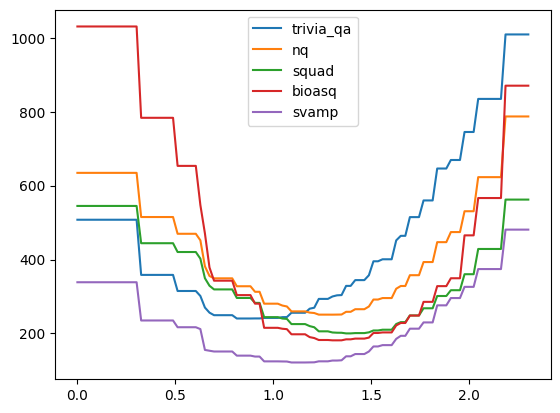

In [18]:
# Binarize SE by best split
for D in Ds:
    split = best_split(D.entropy, D.name)
    plt.legend()
    D.b_entropy = binarize_entropy(D.entropy, split)
    print(f"Dummy accuracy for {D.name}: {max(torch.mean(D.b_entropy).item(), 1-torch.mean(D.b_entropy).item()):.4f}")

### Use linear probes to predict Binarized SE

Training on trivia_qa-TBG 1/33
Validation Accuracy: 0.6111, AUROC: 0.5227
Training Loss: 0.5736, Validation Loss: 0.6670
Test Loss: 0.6624, Test Accuracy: 0.5900, AUROC: 0.5732
Training on trivia_qa-TBG 2/33
Validation Accuracy: 0.6028, AUROC: 0.5698
Training Loss: 0.5283, Validation Loss: 0.6700
Test Loss: 0.6599, Test Accuracy: 0.5650, AUROC: 0.6082
Training on trivia_qa-TBG 3/33
Validation Accuracy: 0.6167, AUROC: 0.5908
Training Loss: 0.4494, Validation Loss: 0.6892
Test Loss: 0.6716, Test Accuracy: 0.6000, AUROC: 0.6134
Training on trivia_qa-TBG 4/33
Validation Accuracy: 0.6361, AUROC: 0.6228
Training Loss: 0.3935, Validation Loss: 0.6866
Test Loss: 0.6743, Test Accuracy: 0.6150, AUROC: 0.6398
Training on trivia_qa-TBG 5/33
Validation Accuracy: 0.6306, AUROC: 0.6390
Training Loss: 0.3503, Validation Loss: 0.7011
Test Loss: 0.6762, Test Accuracy: 0.6300, AUROC: 0.6516
Training on trivia_qa-TBG 6/33
Validation Accuracy: 0.6306, AUROC: 0.6523
Training Loss: 0.3059, Validation Loss: 0

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6833, AUROC: 0.6958
Training Loss: 0.2575, Validation Loss: 0.7020
Test Loss: 0.6437, Test Accuracy: 0.6800, AUROC: 0.7256
Training on trivia_qa-TBG 8/33
Validation Accuracy: 0.6917, AUROC: 0.7159
Training Loss: 0.2077, Validation Loss: 0.7021
Test Loss: 0.6184, Test Accuracy: 0.7300, AUROC: 0.7659
Training on trivia_qa-TBG 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7306, AUROC: 0.7385
Training Loss: 0.1784, Validation Loss: 0.6946
Test Loss: 0.6274, Test Accuracy: 0.7500, AUROC: 0.7685
Training on trivia_qa-TBG 10/33


...

Validation Accuracy: 0.7472, AUROC: 0.8211
Training Loss: 0.0083, Validation Loss: 1.2251
Test Loss: 1.1461, Test Accuracy: 0.7600, AUROC: 0.8196
Training on trivia_qa-SLT 30/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.8260
Training Loss: 0.0081, Validation Loss: 1.2535
Test Loss: 1.2428, Test Accuracy: 0.7400, AUROC: 0.8172
Training on trivia_qa-SLT 31/33
Validation Accuracy: 0.7611, AUROC: 0.8394
Training Loss: 0.0080, Validation Loss: 1.2089
Test Loss: 1.2538, Test Accuracy: 0.7600, AUROC: 0.8112
Training on trivia_qa-SLT 32/33
Validation Accuracy: 0.7694, AUROC: 0.8431
Training Loss: 0.0080, Validation Loss: 1.1931
Test Loss: 1.3077, Test Accuracy: 0.7650, AUROC: 0.8136
Training on trivia_qa-SLT 33/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7667, AUROC: 0.8350
Training Loss: 0.0084, Validation Loss: 1.2601
Test Loss: 1.4429, Test Accuracy: 0.7100, AUROC: 0.7855


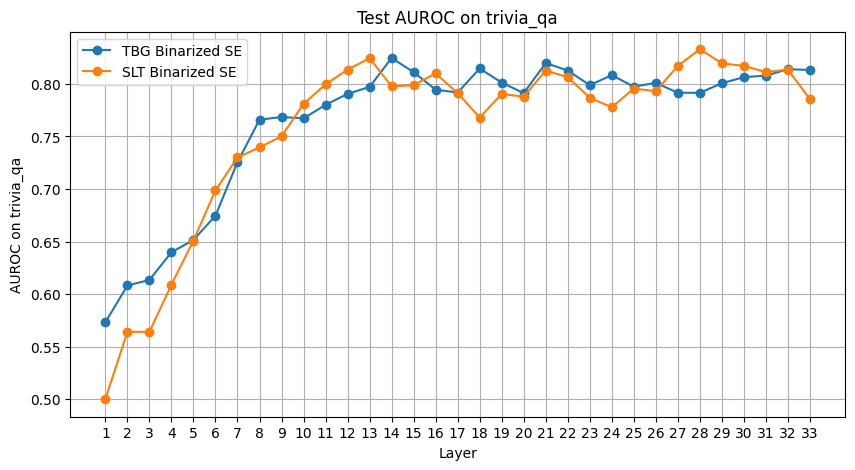

Training on nq-TBG 1/33
Validation Accuracy: 0.6111, AUROC: 0.5558
Training Loss: 0.5700, Validation Loss: 0.6505
Test Loss: 0.6765, Test Accuracy: 0.6050, AUROC: 0.5386
Training on nq-TBG 2/33
Validation Accuracy: 0.6028, AUROC: 0.5581
Training Loss: 0.5303, Validation Loss: 0.6590
Test Loss: 0.6888, Test Accuracy: 0.5900, AUROC: 0.5374
Training on nq-TBG 3/33
Validation Accuracy: 0.6056, AUROC: 0.5741
Training Loss: 0.4573, Validation Loss: 0.6734
Test Loss: 0.6939, Test Accuracy: 0.5650, AUROC: 0.5682
Training on nq-TBG 4/33
Validation Accuracy: 0.6056, AUROC: 0.5657
Training Loss: 0.3945, Validation Loss: 0.7062
Test Loss: 0.7201, Test Accuracy: 0.5800, AUROC: 0.5875
Training on nq-TBG 5/33
Validation Accuracy: 0.6222, AUROC: 0.6017
Training Loss: 0.3505, Validation Loss: 0.7015
Test Loss: 0.7594, Test Accuracy: 0.5650, AUROC: 0.5755
Training on nq-TBG 6/33
Validation Accuracy: 0.6278, AUROC: 0.6149
Training Loss: 0.3005, Validation Loss: 0.7206
Test Loss: 0.7590, Test Accuracy: 0.

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6611, AUROC: 0.6342
Training Loss: 0.2504, Validation Loss: 0.7464
Test Loss: 0.7300, Test Accuracy: 0.6950, AUROC: 0.6719
Training on nq-TBG 8/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6389, AUROC: 0.6557
Training Loss: 0.1924, Validation Loss: 0.7768
Test Loss: 0.7032, Test Accuracy: 0.6750, AUROC: 0.7150
Training on nq-TBG 9/33


...

Validation Accuracy: 0.7361, AUROC: 0.7934
Training Loss: 0.0159, Validation Loss: 0.9914
Test Loss: 0.9335, Test Accuracy: 0.6950, AUROC: 0.7926
Training on nq-SLT 21/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7528, AUROC: 0.7963
Training Loss: 0.0105, Validation Loss: 1.0770
Test Loss: 1.0206, Test Accuracy: 0.7150, AUROC: 0.7907
Training on nq-SLT 22/33
Validation Accuracy: 0.7389, AUROC: 0.7928
Training Loss: 0.0066, Validation Loss: 1.1506
Test Loss: 1.1342, Test Accuracy: 0.7450, AUROC: 0.7845
Training on nq-SLT 23/33
Validation Accuracy: 0.7167, AUROC: 0.7839
Training Loss: 0.0045, Validation Loss: 1.2463
Test Loss: 1.1185, Test Accuracy: 0.7400, AUROC: 0.7830
Training on nq-SLT 24/33
Validation Accuracy: 0.7306, AUROC: 0.7822
Training Loss: 0.0037, Validation Loss: 1.2717
Test Loss: 1.0892, Test Accuracy: 0.6950, AUROC: 0.7869
Training on nq-SLT 25/33
Validation Accuracy: 0.7361, AUROC: 0.7901
Training Loss: 0.0030, Validation Loss: 1.2538
Test Loss: 1.1296, Test Accuracy: 0.6950, AUROC: 0.7914
Training on nq-SLT 26/33
Validation Accuracy: 0.7306, AUROC: 0.7840
Training Loss: 0.0025, Validation Loss: 1.3098
Test Loss: 1.2610, Test Accuracy: 0.7200, AUROC: 0.7851

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7194, AUROC: 0.7828
Training Loss: 0.0018, Validation Loss: 1.4146
Test Loss: 1.1612, Test Accuracy: 0.7400, AUROC: 0.8102


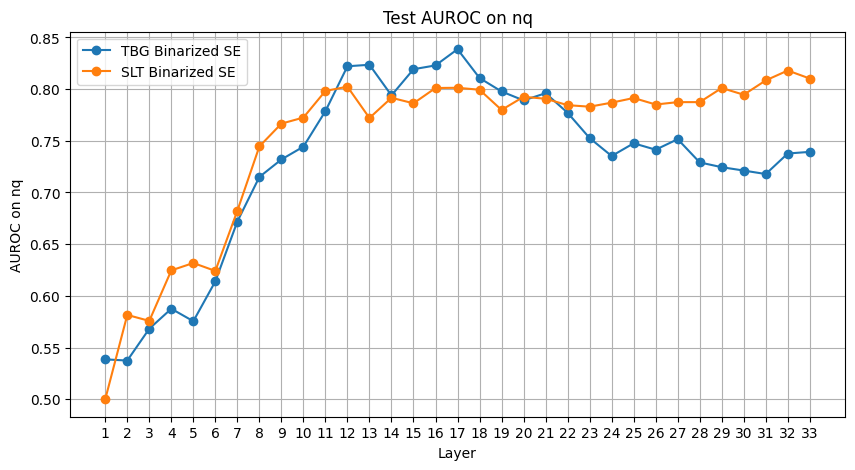

Training on squad-TBG 1/33
Validation Accuracy: 0.7556, AUROC: 0.6576
Training Loss: 0.4590, Validation Loss: 0.5339
Test Loss: 0.5274, Test Accuracy: 0.7550, AUROC: 0.6780
Training on squad-TBG 2/33
Validation Accuracy: 0.7472, AUROC: 0.6913
Training Loss: 0.4220, Validation Loss: 0.5211
Test Loss: 0.5277, Test Accuracy: 0.7500, AUROC: 0.6731
Training on squad-TBG 3/33
Validation Accuracy: 0.7639, AUROC: 0.7224
Training Loss: 0.3591, Validation Loss: 0.5032
Test Loss: 0.5156, Test Accuracy: 0.7350, AUROC: 0.7104
Training on squad-TBG 4/33
Validation Accuracy: 0.7417, AUROC: 0.7169
Training Loss: 0.3071, Validation Loss: 0.5128
Test Loss: 0.5158, Test Accuracy: 0.7300, AUROC: 0.7203
Training on squad-TBG 5/33
Validation Accuracy: 0.7583, AUROC: 0.7231
Training Loss: 0.2632, Validation Loss: 0.5199
Test Loss: 0.5365, Test Accuracy: 0.7350, AUROC: 0.7044
Training on squad-TBG 6/33
Validation Accuracy: 0.7556, AUROC: 0.7510
Training Loss: 0.2184, Validation Loss: 0.5108
Test Loss: 0.5341,

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7528, AUROC: 0.7523
Training Loss: 0.1691, Validation Loss: 0.5405
Test Loss: 0.6213, Test Accuracy: 0.7000, AUROC: 0.6832
Training on squad-TBG 8/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7861, AUROC: 0.7685
Training Loss: 0.1215, Validation Loss: 0.5513
Test Loss: 0.6705, Test Accuracy: 0.7100, AUROC: 0.7059
Training on squad-TBG 9/33


...

Validation Accuracy: 0.7917, AUROC: 0.7938
Training Loss: 0.1275, Validation Loss: 0.5062
Test Loss: 0.6181, Test Accuracy: 0.7750, AUROC: 0.7379
Training on squad-SLT 13/33
Validation Accuracy: 0.7833, AUROC: 0.7980
Training Loss: 0.0934, Validation Loss: 0.5497
Test Loss: 0.6017, Test Accuracy: 0.7850, AUROC: 0.7753
Training on squad-SLT 14/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7639, AUROC: 0.7919
Training Loss: 0.0677, Validation Loss: 0.5978
Test Loss: 0.6233, Test Accuracy: 0.7800, AUROC: 0.7823
Training on squad-SLT 15/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7694, AUROC: 0.7901
Training Loss: 0.0499, Validation Loss: 0.6358
Test Loss: 0.6265, Test Accuracy: 0.7700, AUROC: 0.7944
Training on squad-SLT 16/33
Validation Accuracy: 0.7944, AUROC: 0.8168
Training Loss: 0.0297, Validation Loss: 0.6336
Test Loss: 0.6866, Test Accuracy: 0.7850, AUROC: 0.7936
Training on squad-SLT 17/33
Validation Accuracy: 0.8139, AUROC: 0.8266
Training Loss: 0.0221, Validation Loss: 0.6324
Test Loss: 0.7152, Test Accuracy: 0.7800, AUROC: 0.7812
Training on squad-SLT 18/33
Validation Accuracy: 0.8083, AUROC: 0.8232
Training Loss: 0.0138, Validation Loss: 0.7114
Test Loss: 0.8478, Test Accuracy: 0.7800, AUROC: 0.7797
Training on squad-SLT 19/33
Validation Accuracy: 0.8000, AUROC: 0.8182
Training Loss: 0.0106, Validation Loss: 0.7640
Test Loss: 0.7990, Test Accuracy: 0.7850, AUROC: 0.7955
Training on squad-SLT 20/33
Validation Accuracy: 0.8111, AUROC: 0.8273
Training Loss: 0.0079, Validation Loss: 0.7908
Test Loss: 0.8947, Test Accuracy: 0.7700

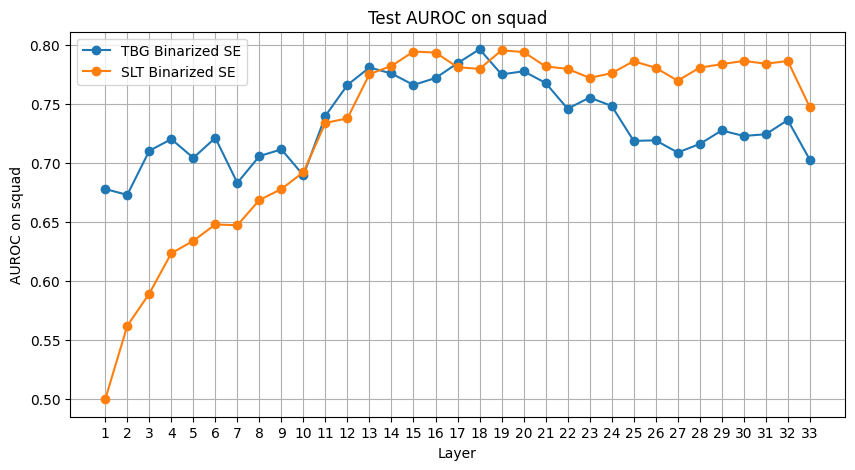

Training on bioasq-TBG 1/33
Validation Accuracy: 0.8528, AUROC: 0.9010
Training Loss: 0.2854, Validation Loss: 0.3544
Test Loss: 0.3380, Test Accuracy: 0.8750, AUROC: 0.8993
Training on bioasq-TBG 2/33
Validation Accuracy: 0.8556, AUROC: 0.9122
Training Loss: 0.2587, Validation Loss: 0.3401
Test Loss: 0.3207, Test Accuracy: 0.8850, AUROC: 0.9178
Training on bioasq-TBG 3/33
Validation Accuracy: 0.8667, AUROC: 0.9188
Training Loss: 0.2144, Validation Loss: 0.3282
Test Loss: 0.3244, Test Accuracy: 0.8800, AUROC: 0.9131
Training on bioasq-TBG 4/33
Validation Accuracy: 0.8583, AUROC: 0.9184
Training Loss: 0.1776, Validation Loss: 0.3315
Test Loss: 0.3312, Test Accuracy: 0.8850, AUROC: 0.9149
Training on bioasq-TBG 5/33
Validation Accuracy: 0.8583, AUROC: 0.9133
Training Loss: 0.1569, Validation Loss: 0.3498
Test Loss: 0.3519, Test Accuracy: 0.8850, AUROC: 0.9105
Training on bioasq-TBG 6/33
Validation Accuracy: 0.8667, AUROC: 0.9090
Training Loss: 0.1358, Validation Loss: 0.3782
Test Loss: 0

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8722, AUROC: 0.9444
Training Loss: 0.0845, Validation Loss: 0.3064
Test Loss: 0.3564, Test Accuracy: 0.8750, AUROC: 0.9266
Training on bioasq-TBG 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8861, AUROC: 0.9406
Training Loss: 0.0687, Validation Loss: 0.3199
Test Loss: 0.3392, Test Accuracy: 0.8650, AUROC: 0.9357
Training on bioasq-TBG 10/33


...

Validation Accuracy: 0.8750, AUROC: 0.9422
Training Loss: 0.0485, Validation Loss: 0.3636
Test Loss: 0.2900, Test Accuracy: 0.8950, AUROC: 0.9542
Training on bioasq-SLT 15/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8806, AUROC: 0.9466
Training Loss: 0.0344, Validation Loss: 0.3753
Test Loss: 0.3210, Test Accuracy: 0.9000, AUROC: 0.9518
Training on bioasq-SLT 16/33
Validation Accuracy: 0.8722, AUROC: 0.9526
Training Loss: 0.0214, Validation Loss: 0.3830
Test Loss: 0.4006, Test Accuracy: 0.8750, AUROC: 0.9464
Training on bioasq-SLT 17/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8806, AUROC: 0.9524
Training Loss: 0.0162, Validation Loss: 0.3957
Test Loss: 0.3827, Test Accuracy: 0.9000, AUROC: 0.9503
Training on bioasq-SLT 18/33
Validation Accuracy: 0.8667, AUROC: 0.9537
Training Loss: 0.0098, Validation Loss: 0.4163
Test Loss: 0.4155, Test Accuracy: 0.8850, AUROC: 0.9510
Training on bioasq-SLT 19/33
Validation Accuracy: 0.8889, AUROC: 0.9515
Training Loss: 0.0075, Validation Loss: 0.4543
Test Loss: 0.4089, Test Accuracy: 0.9000, AUROC: 0.9559
Training on bioasq-SLT 20/33
Validation Accuracy: 0.8778, AUROC: 0.9525
Training Loss: 0.0058, Validation Loss: 0.4900
Test Loss: 0.4116, Test Accuracy: 0.9000, AUROC: 0.9590
Training on bioasq-SLT 21/33
Validation Accuracy: 0.8833, AUROC: 0.9528
Training Loss: 0.0042, Validation Loss: 0.5077
Test Loss: 0.4389, Test Accuracy: 0.9000, AUROC: 0.9602
Training on bioasq-SLT 22/33
Validation Accuracy: 0.8861, AUROC: 0.9575
Training Loss: 0.0031, Validation Loss: 0.4904
Test Loss: 0.4235, Test Accuracy: 0

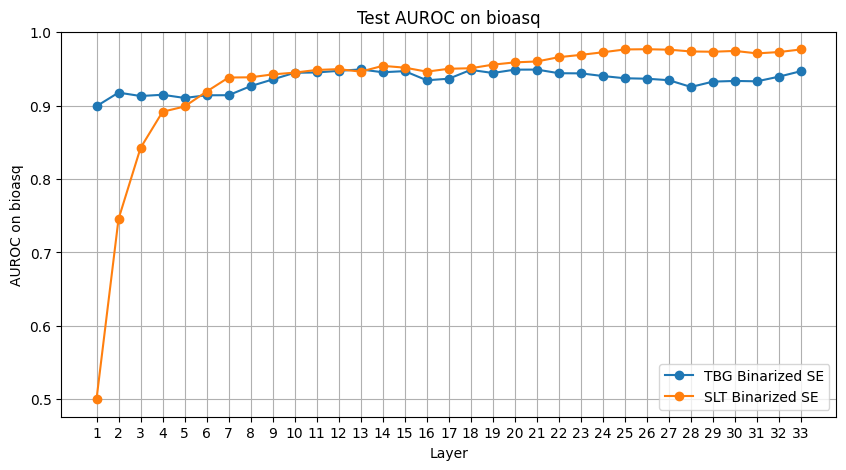

Training on svamp-TBG 1/33
Validation Accuracy: 0.7222, AUROC: 0.6028
Training Loss: 0.6281, Validation Loss: 0.5842
Test Loss: 0.6505, Test Accuracy: 0.6200, AUROC: 0.5978
Training on svamp-TBG 2/33
Validation Accuracy: 0.7222, AUROC: 0.7502
Training Loss: 0.6093, Validation Loss: 0.5533
Test Loss: 0.6239, Test Accuracy: 0.6300, AUROC: 0.7071
Training on svamp-TBG 3/33
Validation Accuracy: 0.7389, AUROC: 0.7518
Training Loss: 0.5803, Validation Loss: 0.5290
Test Loss: 0.5879, Test Accuracy: 0.6500, AUROC: 0.7483
Training on svamp-TBG 4/33
Validation Accuracy: 0.7333, AUROC: 0.7828
Training Loss: 0.5419, Validation Loss: 0.5077
Test Loss: 0.5627, Test Accuracy: 0.7100, AUROC: 0.7848
Training on svamp-TBG 5/33
Validation Accuracy: 0.7944, AUROC: 0.8552
Training Loss: 0.4809, Validation Loss: 0.4681
Test Loss: 0.5520, Test Accuracy: 0.6900, AUROC: 0.7912
Training on svamp-TBG 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8389, AUROC: 0.8731
Training Loss: 0.4333, Validation Loss: 0.4506
Test Loss: 0.5238, Test Accuracy: 0.7500, AUROC: 0.8141
Training on svamp-TBG 7/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8444, AUROC: 0.8854
Training Loss: 0.3570, Validation Loss: 0.4164
Test Loss: 0.4795, Test Accuracy: 0.7800, AUROC: 0.8455
Training on svamp-TBG 8/33
Validation Accuracy: 0.8222, AUROC: 0.8726
Training Loss: 0.2764, Validation Loss: 0.4018
Test Loss: 0.4451, Test Accuracy: 0.7800, AUROC: 0.8693
Training on svamp-TBG 9/33
Validation Accuracy: 0.8667, AUROC: 0.8660
Training Loss: 0.2245, Validation Loss: 0.3983
Test Loss: 0.4063, Test Accuracy: 0.8000, AUROC: 0.8964
Training on svamp-TBG 10/33
Validation Accuracy: 0.8278, AUROC: 0.8295
Training Loss: 0.1794, Validation Loss: 0.4567
Test Loss: 0.3869, Test Accuracy: 0.8100, AUROC: 0.8960
Training on svamp-TBG 11/33
Validation Accuracy: 0.8222, AUROC: 0.8411
Training Loss: 0.1333, Validation Loss: 0.4535
Test Loss: 0.3690, Test Accuracy: 0.8300, AUROC: 0.9121
Training on svamp-TBG 12/33
Validation Accuracy: 0.8056, AUROC: 0.8443
Training Loss: 0.0970, Validation Loss: 0.4794
Test Loss: 0.3201, Test Accuracy: 0.8300, 

...

Validation Accuracy: 0.8389, AUROC: 0.9028
Training Loss: 0.0136, Validation Loss: 0.6448
Test Loss: 0.9483, Test Accuracy: 0.8000, AUROC: 0.8527
Training on svamp-SLT 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8444, AUROC: 0.8985
Training Loss: 0.0123, Validation Loss: 0.7008
Test Loss: 1.0735, Test Accuracy: 0.7900, AUROC: 0.8442
Training on svamp-SLT 33/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8389, AUROC: 0.9012
Training Loss: 0.0200, Validation Loss: 0.5956
Test Loss: 0.8640, Test Accuracy: 0.8100, AUROC: 0.8548


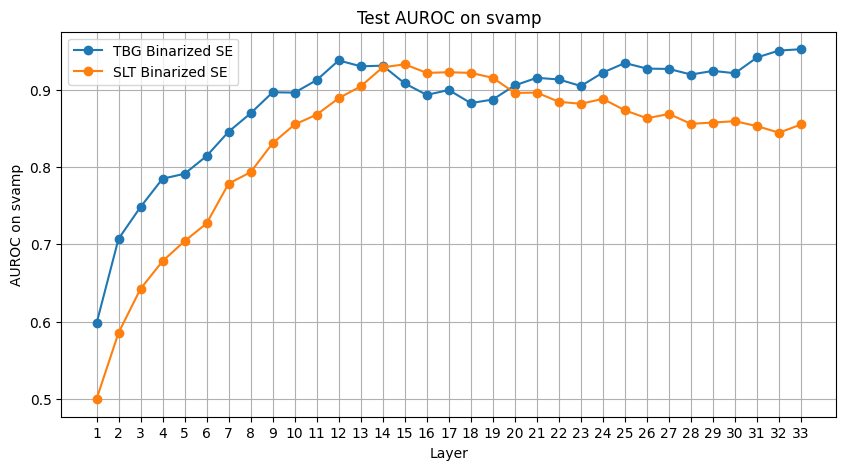

In [23]:
for D in Ds:
    
    # TBG
    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(D.tbg_dataset, D.b_entropy, D.total_size)
    tb_accs = []
    tb_aucs = []
    tb_models = []
    
    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on {D.name}-TBG {i+1}/{len(X_trains)}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {D.name}-TBG {i+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        tb_accs.append(test_acc)
        tb_aucs.append(test_auc)
        tb_models.append(model)

    D.tb_accs = tb_accs
    D.tb_aucs = tb_aucs
    D.tb_models = tb_models

    # SLT
    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(D.slt_dataset, D.b_entropy, D.total_size)
    sb_accs = []
    sb_aucs = []
    sb_models = []
    
    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on {D.name}-SLT {i+1}/{len(X_trains)}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {D.name}-SLT {i+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        sb_accs.append(test_acc)
        sb_aucs.append(test_auc)
        sb_models.append(model)

    D.sb_accs = sb_accs
    D.sb_aucs = sb_aucs
    D.sb_models = sb_models
    
    plot_metrics([tb_aucs, sb_aucs], ['TBG Binarized SE', 'SLT Binarized SE'], f'AUROC on {D.name}')

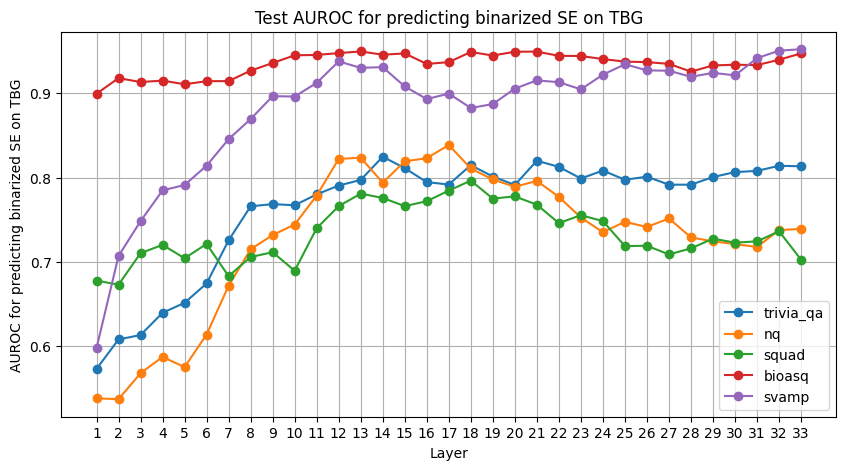

TBG: max AUROC for LR trained on trivia_qa's Binarized SE and tested on trivia_qa's Binarized SE:
	- 0.8247 at layer 14
	- 0.8199 at layer 21
	- 0.8147 at layer 18
	- 0.8140 at layer 32
	- 0.8133 at layer 33
TBG: max AUROC for LR trained on nq's Binarized SE and tested on nq's Binarized SE:
	- 0.8386 at layer 17
	- 0.8236 at layer 13
	- 0.8229 at layer 16
	- 0.8221 at layer 12
	- 0.8193 at layer 15
TBG: max AUROC for LR trained on squad's Binarized SE and tested on squad's Binarized SE:
	- 0.7964 at layer 18
	- 0.7845 at layer 17
	- 0.7809 at layer 13
	- 0.7777 at layer 20
	- 0.7759 at layer 14
TBG: max AUROC for LR trained on bioasq's Binarized SE and tested on bioasq's Binarized SE:
	- 0.9494 at layer 13
	- 0.9492 at layer 21
	- 0.9491 at layer 20
	- 0.9488 at layer 18
	- 0.9475 at layer 12
TBG: max AUROC for LR trained on svamp's Binarized SE and tested on svamp's Binarized SE:
	- 0.9520 at layer 33
	- 0.9503 at layer 32
	- 0.9414 at layer 31
	- 0.9376 at layer 12
	- 0.9342 at layer

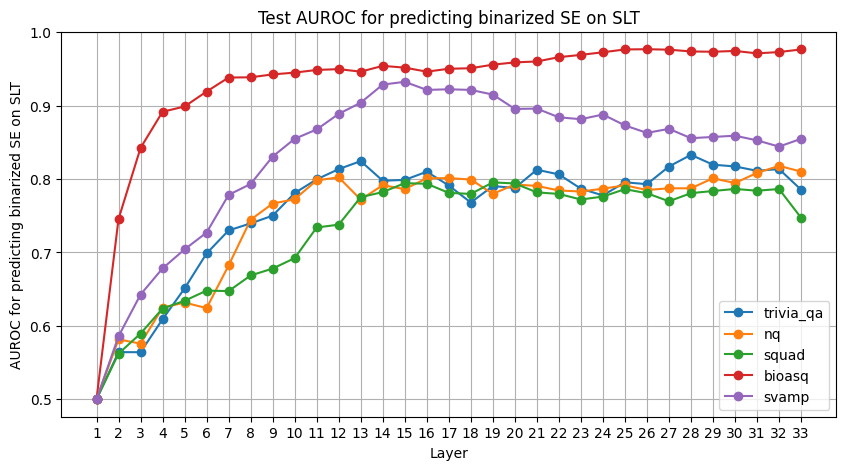

SLT: max AUROC for LR trained on trivia_qa's Binarized SE and tested on trivia_qa's Binarized SE:
	- 0.8330 at layer 28
	- 0.8245 at layer 13
	- 0.8196 at layer 29
	- 0.8172 at layer 30
	- 0.8171 at layer 27
SLT: max AUROC for LR trained on nq's Binarized SE and tested on nq's Binarized SE:
	- 0.8180 at layer 32
	- 0.8102 at layer 33
	- 0.8084 at layer 31
	- 0.8023 at layer 12
	- 0.8013 at layer 17
SLT: max AUROC for LR trained on squad's Binarized SE and tested on squad's Binarized SE:
	- 0.7955 at layer 19
	- 0.7944 at layer 15
	- 0.7940 at layer 20
	- 0.7936 at layer 16
	- 0.7865 at layer 30
SLT: max AUROC for LR trained on bioasq's Binarized SE and tested on bioasq's Binarized SE:
	- 0.9769 at layer 26
	- 0.9766 at layer 25
	- 0.9766 at layer 33
	- 0.9763 at layer 27
	- 0.9746 at layer 30
SLT: max AUROC for LR trained on svamp's Binarized SE and tested on svamp's Binarized SE:
	- 0.9325 at layer 15
	- 0.9287 at layer 14
	- 0.9223 at layer 17
	- 0.9215 at layer 16
	- 0.9215 at layer

In [21]:
# Plot test AUROC curves for all on predicting binarized SE
plot_metrics([D.tb_aucs for D in Ds], [f"{D.name}" for D in Ds], f'AUROC for predicting binarized SE on TBG')
best_metric([D.tb_aucs for D in Ds], ds=[[D.name]*2 for D in Ds])

plot_metrics([D.sb_aucs for D in Ds], [f"{D.name}" for D in Ds], f'AUROC for predicting binarized SE on SLT')
best_metric([D.sb_aucs for D in Ds], "SLT", ds=[[D.name]*2 for D in Ds])

### Use linear probes to predict Accuracy

Training on trivia_qa-TBG 1/33
Validation Accuracy: 0.6639, AUROC: 0.5158
Training Loss: 0.5520, Validation Loss: 0.6365
Test Loss: 0.6232, Test Accuracy: 0.6700, AUROC: 0.6665
Training on trivia_qa-TBG 2/33
Validation Accuracy: 0.6583, AUROC: 0.5278
Training Loss: 0.5098, Validation Loss: 0.6460
Test Loss: 0.6051, Test Accuracy: 0.6800, AUROC: 0.7005
Training on trivia_qa-TBG 3/33
Validation Accuracy: 0.6611, AUROC: 0.5678
Training Loss: 0.4350, Validation Loss: 0.6539
Test Loss: 0.6088, Test Accuracy: 0.6450, AUROC: 0.6835
Training on trivia_qa-TBG 4/33
Validation Accuracy: 0.6500, AUROC: 0.5945
Training Loss: 0.3778, Validation Loss: 0.6605
Test Loss: 0.6356, Test Accuracy: 0.6650, AUROC: 0.6721
Training on trivia_qa-TBG 5/33
Validation Accuracy: 0.6444, AUROC: 0.5877
Training Loss: 0.3379, Validation Loss: 0.6942
Test Loss: 0.6577, Test Accuracy: 0.6600, AUROC: 0.6726
Training on trivia_qa-TBG 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6278, AUROC: 0.5708
Training Loss: 0.3005, Validation Loss: 0.7449
Test Loss: 0.7133, Test Accuracy: 0.6200, AUROC: 0.6630
Training on trivia_qa-TBG 7/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6361, AUROC: 0.6086
Training Loss: 0.2579, Validation Loss: 0.7243
Test Loss: 0.6845, Test Accuracy: 0.6800, AUROC: 0.6930
Training on trivia_qa-TBG 8/33


...

Validation Accuracy: 0.7611, AUROC: 0.7970
Training Loss: 0.0324, Validation Loss: 0.7893
Test Loss: 0.8308, Test Accuracy: 0.7450, AUROC: 0.7886
Training on trivia_qa-SLT 19/33
Validation Accuracy: 0.7778, AUROC: 0.7866
Training Loss: 0.0238, Validation Loss: 0.8204
Test Loss: 0.9743, Test Accuracy: 0.7350, AUROC: 0.7626
Training on trivia_qa-SLT 20/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7556, AUROC: 0.7684
Training Loss: 0.0185, Validation Loss: 0.9419
Test Loss: 1.0492, Test Accuracy: 0.7750, AUROC: 0.7742
Training on trivia_qa-SLT 21/33
Validation Accuracy: 0.7278, AUROC: 0.7482
Training Loss: 0.0127, Validation Loss: 1.0475
Test Loss: 0.9388, Test Accuracy: 0.7600, AUROC: 0.7868
Training on trivia_qa-SLT 22/33
Validation Accuracy: 0.7028, AUROC: 0.7097
Training Loss: 0.0082, Validation Loss: 1.3923
Test Loss: 1.1712, Test Accuracy: 0.7300, AUROC: 0.7654
Training on trivia_qa-SLT 23/33
Validation Accuracy: 0.7000, AUROC: 0.7234
Training Loss: 0.0061, Validation Loss: 1.4137
Test Loss: 1.3273, Test Accuracy: 0.7550, AUROC: 0.7537
Training on trivia_qa-SLT 24/33
Validation Accuracy: 0.7194, AUROC: 0.7570
Training Loss: 0.0048, Validation Loss: 1.2491
Test Loss: 1.3174, Test Accuracy: 0.7550, AUROC: 0.7700
Training on trivia_qa-SLT 25/33
Validation Accuracy: 0.7139, AUROC: 0.7557
Training Loss: 0.0040, Validation Loss: 1.2427
Test Loss: 1.4131, T

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7250, AUROC: 0.7570
Training Loss: 0.0027, Validation Loss: 1.3638
Test Loss: 1.4326, Test Accuracy: 0.7400, AUROC: 0.7685


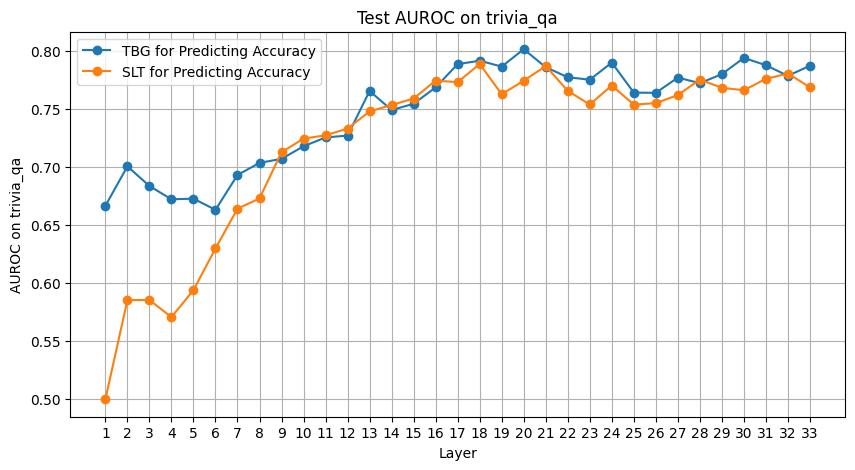

Training on nq-TBG 1/33
Validation Accuracy: 0.5972, AUROC: 0.5552
Training Loss: 0.5857, Validation Loss: 0.6691
Test Loss: 0.6584, Test Accuracy: 0.6250, AUROC: 0.5319
Training on nq-TBG 2/33
Validation Accuracy: 0.6056, AUROC: 0.5795
Training Loss: 0.5488, Validation Loss: 0.6661
Test Loss: 0.6598, Test Accuracy: 0.5950, AUROC: 0.5588
Training on nq-TBG 3/33
Validation Accuracy: 0.6000, AUROC: 0.5909
Training Loss: 0.4807, Validation Loss: 0.6786
Test Loss: 0.6667, Test Accuracy: 0.6150, AUROC: 0.5660
Training on nq-TBG 4/33
Validation Accuracy: 0.6028, AUROC: 0.6086
Training Loss: 0.4233, Validation Loss: 0.6878
Test Loss: 0.6659, Test Accuracy: 0.6000, AUROC: 0.5758
Training on nq-TBG 5/33
Validation Accuracy: 0.6278, AUROC: 0.6100
Training Loss: 0.3771, Validation Loss: 0.7015
Test Loss: 0.7018, Test Accuracy: 0.5900, AUROC: 0.5512
Training on nq-TBG 6/33
Validation Accuracy: 0.6361, AUROC: 0.6395
Training Loss: 0.3311, Validation Loss: 0.7069
Test Loss: 0.7494, Test Accuracy: 0.

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6056, AUROC: 0.6313
Training Loss: 0.2827, Validation Loss: 0.7694
Test Loss: 0.7593, Test Accuracy: 0.6050, AUROC: 0.5931
Training on nq-TBG 8/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6194, AUROC: 0.6362
Training Loss: 0.2239, Validation Loss: 0.8059
Test Loss: 0.8321, Test Accuracy: 0.5950, AUROC: 0.5979
Training on nq-TBG 9/33


...

Validation Accuracy: 0.6306, AUROC: 0.6649
Training Loss: 0.0025, Validation Loss: 1.7368
Test Loss: 1.7022, Test Accuracy: 0.6050, AUROC: 0.6666
Training on nq-SLT 30/33
Validation Accuracy: 0.6139, AUROC: 0.6571
Training Loss: 0.0023, Validation Loss: 1.8269
Test Loss: 1.7725, Test Accuracy: 0.6200, AUROC: 0.6646
Training on nq-SLT 31/33
Validation Accuracy: 0.6389, AUROC: 0.6784
Training Loss: 0.0021, Validation Loss: 1.8258
Test Loss: 1.7621, Test Accuracy: 0.6650, AUROC: 0.6625
Training on nq-SLT 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6667, AUROC: 0.6848
Training Loss: 0.0018, Validation Loss: 1.8581
Test Loss: 1.7000, Test Accuracy: 0.6550, AUROC: 0.6610
Training on nq-SLT 33/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6750, AUROC: 0.6855
Training Loss: 0.0035, Validation Loss: 1.8888
Test Loss: 1.8965, Test Accuracy: 0.6300, AUROC: 0.6613


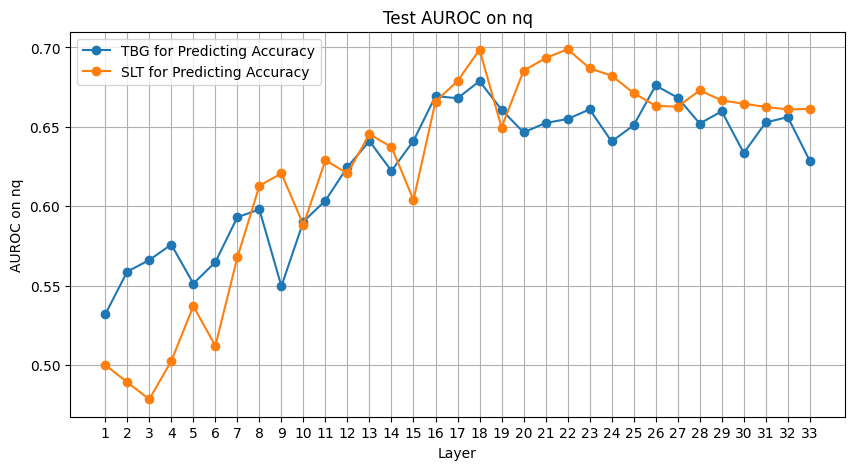

Training on squad-TBG 1/33
Validation Accuracy: 0.7722, AUROC: 0.4769
Training Loss: 0.4905, Validation Loss: 0.5459
Test Loss: 0.4707, Test Accuracy: 0.8100, AUROC: 0.6729
Training on squad-TBG 2/33
Validation Accuracy: 0.7694, AUROC: 0.5149
Training Loss: 0.4560, Validation Loss: 0.5461
Test Loss: 0.4658, Test Accuracy: 0.8150, AUROC: 0.6783
Training on squad-TBG 3/33
Validation Accuracy: 0.7444, AUROC: 0.5698
Training Loss: 0.3938, Validation Loss: 0.5488
Test Loss: 0.4640, Test Accuracy: 0.8150, AUROC: 0.6896
Training on squad-TBG 4/33
Validation Accuracy: 0.7444, AUROC: 0.5979
Training Loss: 0.3356, Validation Loss: 0.5536
Test Loss: 0.4630, Test Accuracy: 0.8150, AUROC: 0.6964
Training on squad-TBG 5/33
Validation Accuracy: 0.7417, AUROC: 0.5870
Training Loss: 0.2944, Validation Loss: 0.5862
Test Loss: 0.4687, Test Accuracy: 0.7850, AUROC: 0.7159
Training on squad-TBG 6/33
Validation Accuracy: 0.7250, AUROC: 0.6091
Training Loss: 0.2515, Validation Loss: 0.6149
Test Loss: 0.4994,

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7306, AUROC: 0.6368
Training Loss: 0.1999, Validation Loss: 0.6308
Test Loss: 0.5591, Test Accuracy: 0.7650, AUROC: 0.6778
Training on squad-TBG 8/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7306, AUROC: 0.6320
Training Loss: 0.1540, Validation Loss: 0.6705
Test Loss: 0.5625, Test Accuracy: 0.7700, AUROC: 0.6931
Training on squad-TBG 9/33


...

Validation Accuracy: 0.7194, AUROC: 0.6178
Training Loss: 0.0050, Validation Loss: 1.4467
Test Loss: 1.1142, Test Accuracy: 0.7500, AUROC: 0.6791
Training on squad-SLT 24/33
Validation Accuracy: 0.7139, AUROC: 0.6317
Training Loss: 0.0039, Validation Loss: 1.4954
Test Loss: 1.1051, Test Accuracy: 0.7600, AUROC: 0.6937
Training on squad-SLT 25/33
Validation Accuracy: 0.7083, AUROC: 0.6302
Training Loss: 0.0033, Validation Loss: 1.5535
Test Loss: 1.1703, Test Accuracy: 0.7650, AUROC: 0.6858
Training on squad-SLT 26/33
Validation Accuracy: 0.7028, AUROC: 0.6215
Training Loss: 0.0028, Validation Loss: 1.5585
Test Loss: 1.1754, Test Accuracy: 0.7600, AUROC: 0.6716
Training on squad-SLT 27/33
Validation Accuracy: 0.7111, AUROC: 0.6319
Training Loss: 0.0025, Validation Loss: 1.5336
Test Loss: 1.0708, Test Accuracy: 0.7750, AUROC: 0.7041
Training on squad-SLT 28/33
Validation Accuracy: 0.7028, AUROC: 0.6267
Training Loss: 0.0020, Validation Loss: 1.5571
Test Loss: 1.1994, Test Accuracy: 0.7550

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.6341
Training Loss: 0.0015, Validation Loss: 1.5763
Test Loss: 1.0194, Test Accuracy: 0.7700, AUROC: 0.7261
Training on squad-SLT 32/33
Validation Accuracy: 0.7111, AUROC: 0.6167
Training Loss: 0.0013, Validation Loss: 1.6894
Test Loss: 1.1867, Test Accuracy: 0.7700, AUROC: 0.7054
Training on squad-SLT 33/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7139, AUROC: 0.6107
Training Loss: 0.0026, Validation Loss: 1.5343
Test Loss: 1.2517, Test Accuracy: 0.7600, AUROC: 0.6675


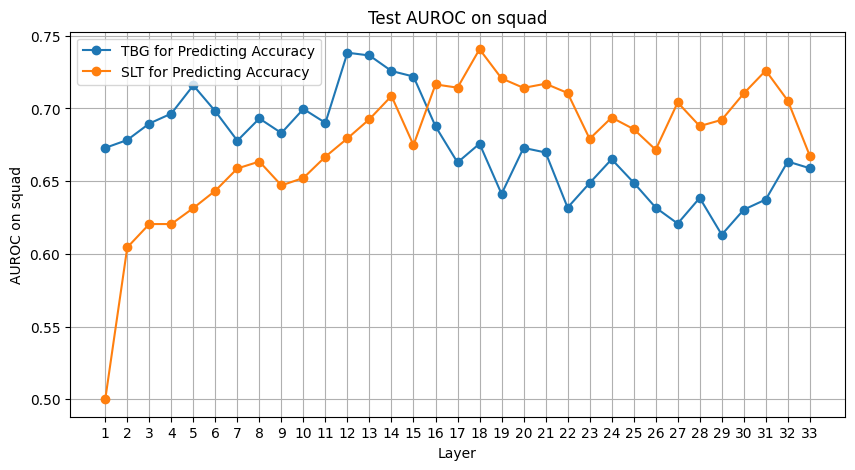

Training on bioasq-TBG 1/33
Validation Accuracy: 0.7500, AUROC: 0.7707
Training Loss: 0.4989, Validation Loss: 0.5548
Test Loss: 0.5265, Test Accuracy: 0.7850, AUROC: 0.7863
Training on bioasq-TBG 2/33
Validation Accuracy: 0.7694, AUROC: 0.7871
Training Loss: 0.4690, Validation Loss: 0.5414
Test Loss: 0.5274, Test Accuracy: 0.7700, AUROC: 0.8059
Training on bioasq-TBG 3/33
Validation Accuracy: 0.7611, AUROC: 0.7719
Training Loss: 0.4085, Validation Loss: 0.5584
Test Loss: 0.5463, Test Accuracy: 0.7450, AUROC: 0.8109
Training on bioasq-TBG 4/33
Validation Accuracy: 0.7639, AUROC: 0.7973
Training Loss: 0.3521, Validation Loss: 0.5465
Test Loss: 0.5508, Test Accuracy: 0.7600, AUROC: 0.7913
Training on bioasq-TBG 5/33
Validation Accuracy: 0.7500, AUROC: 0.7910
Training Loss: 0.3210, Validation Loss: 0.5690
Test Loss: 0.5795, Test Accuracy: 0.7700, AUROC: 0.7836
Training on bioasq-TBG 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7667, AUROC: 0.8001
Training Loss: 0.2916, Validation Loss: 0.5739
Test Loss: 0.5889, Test Accuracy: 0.7500, AUROC: 0.7906
Training on bioasq-TBG 7/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7694, AUROC: 0.7984
Training Loss: 0.2544, Validation Loss: 0.5973
Test Loss: 0.5820, Test Accuracy: 0.7650, AUROC: 0.8054
Training on bioasq-TBG 8/33


...

Validation Accuracy: 0.7389, AUROC: 0.8009
Training Loss: 0.0043, Validation Loss: 1.8951
Test Loss: 1.8561, Test Accuracy: 0.7950, AUROC: 0.8331
Training on bioasq-SLT 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7528, AUROC: 0.8043
Training Loss: 0.0038, Validation Loss: 1.8149
Test Loss: 1.7280, Test Accuracy: 0.7900, AUROC: 0.8414
Training on bioasq-SLT 33/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7417, AUROC: 0.7803
Training Loss: 0.0154, Validation Loss: 2.2068
Test Loss: 1.9109, Test Accuracy: 0.8150, AUROC: 0.8397


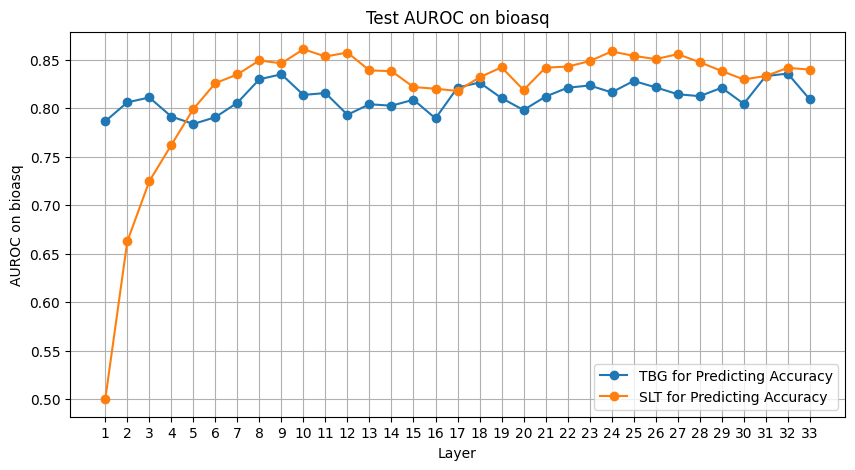

Training on svamp-TBG 1/33
Validation Accuracy: 0.5611, AUROC: 0.5538
Training Loss: 0.6633, Validation Loss: 0.6709
Test Loss: 0.7037, Test Accuracy: 0.5200, AUROC: 0.5308
Training on svamp-TBG 2/33
Validation Accuracy: 0.6111, AUROC: 0.6483
Training Loss: 0.6279, Validation Loss: 0.6402
Test Loss: 0.6814, Test Accuracy: 0.5200, AUROC: 0.5926
Training on svamp-TBG 3/33
Validation Accuracy: 0.6167, AUROC: 0.6842
Training Loss: 0.5996, Validation Loss: 0.6239
Test Loss: 0.6680, Test Accuracy: 0.5300, AUROC: 0.6351
Training on svamp-TBG 4/33
Validation Accuracy: 0.6389, AUROC: 0.7062
Training Loss: 0.5491, Validation Loss: 0.6065
Test Loss: 0.6725, Test Accuracy: 0.5400, AUROC: 0.6287
Training on svamp-TBG 5/33
Validation Accuracy: 0.6778, AUROC: 0.7473
Training Loss: 0.4802, Validation Loss: 0.5784
Test Loss: 0.6754, Test Accuracy: 0.5600, AUROC: 0.6391
Training on svamp-TBG 6/33
Validation Accuracy: 0.6889, AUROC: 0.7756
Training Loss: 0.4346, Validation Loss: 0.5561
Test Loss: 0.6756,

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7556, AUROC: 0.8066
Training Loss: 0.2938, Validation Loss: 0.5429
Test Loss: 0.6505, Test Accuracy: 0.6500, AUROC: 0.7247
Training on svamp-TBG 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7556, AUROC: 0.8064
Training Loss: 0.2409, Validation Loss: 0.5529
Test Loss: 0.6444, Test Accuracy: 0.6800, AUROC: 0.7519
Training on svamp-TBG 10/33


...

Validation Accuracy: 0.6944, AUROC: 0.7678
Training Loss: 0.0172, Validation Loss: 1.4452
Test Loss: 1.1832, Test Accuracy: 0.7300, AUROC: 0.8163
Training on svamp-SLT 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7167, AUROC: 0.7785
Training Loss: 0.0259, Validation Loss: 1.5797
Test Loss: 1.6357, Test Accuracy: 0.7200, AUROC: 0.7935
Training on svamp-SLT 33/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7389, AUROC: 0.7710
Training Loss: 0.0665, Validation Loss: 1.5451
Test Loss: 1.6574, Test Accuracy: 0.6800, AUROC: 0.7647


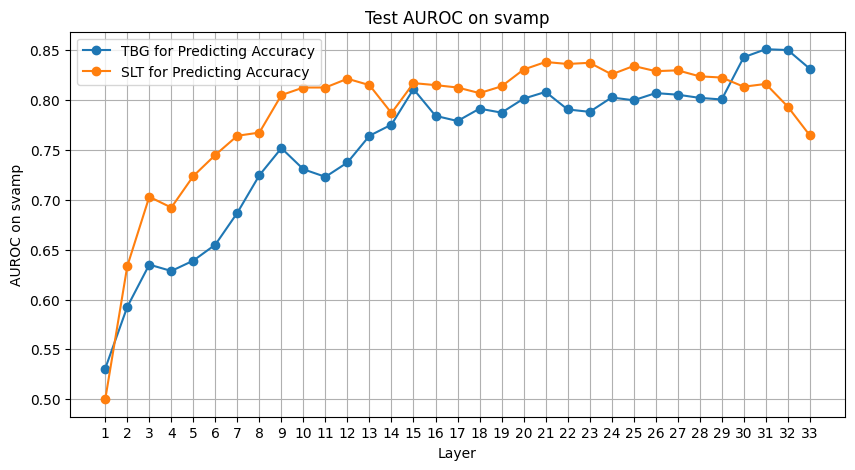

In [24]:
for D in Ds:
    
    # TBG
    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(D.tbg_dataset, D.accuracies, D.total_size)
    ta_accs = []
    ta_aucs = []
    
    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on {D.name}-TBG {i+1}/{len(X_trains)}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {D.name}-TBG {i+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        ta_accs.append(test_acc)
        ta_aucs.append(test_auc)

    D.ta_accs = ta_accs
    D.ta_aucs = ta_aucs

    # SLT
    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(D.slt_dataset, D.accuracies, D.total_size)
    sa_accs = []
    sa_aucs = []
    sa_models = []
    
    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on {D.name}-SLT {i+1}/{len(X_trains)}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {D.name}-SLT {i+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        sa_accs.append(test_acc)
        sa_aucs.append(test_auc)
        sa_models.append(model)

    D.sa_accs = sa_accs
    D.sa_aucs = sa_aucs
    D.sa_models = sa_models
    
    plot_metrics([ta_aucs, sa_aucs], ['TBG for Predicting Accuracy', 'SLT for Predicting Accuracy'], f'AUROC on {D.name}')

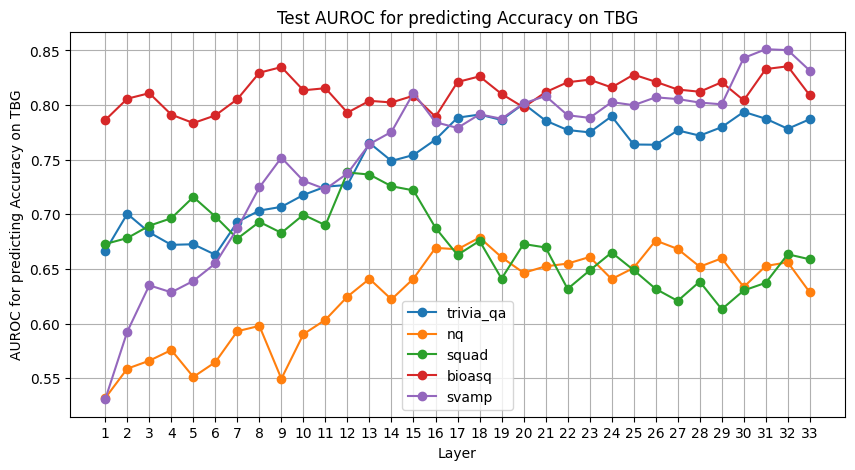

TBG: max AUROC for LR trained on trivia_qa's Accuracy and tested on trivia_qa's Accuracy:
	- 0.8013 at layer 20
	- 0.7938 at layer 30
	- 0.7914 at layer 18
	- 0.7898 at layer 24
	- 0.7885 at layer 17
TBG: max AUROC for LR trained on nq's Accuracy and tested on nq's Accuracy:
	- 0.6788 at layer 18
	- 0.6760 at layer 26
	- 0.6693 at layer 16
	- 0.6684 at layer 27
	- 0.6680 at layer 17
TBG: max AUROC for LR trained on squad's Accuracy and tested on squad's Accuracy:
	- 0.7383 at layer 12
	- 0.7364 at layer 13
	- 0.7258 at layer 14
	- 0.7219 at layer 15
	- 0.7159 at layer 5
TBG: max AUROC for LR trained on bioasq's Accuracy and tested on bioasq's Accuracy:
	- 0.8355 at layer 32
	- 0.8348 at layer 9
	- 0.8330 at layer 31
	- 0.8296 at layer 8
	- 0.8279 at layer 25
TBG: max AUROC for LR trained on svamp's Accuracy and tested on svamp's Accuracy:
	- 0.8511 at layer 31
	- 0.8503 at layer 32
	- 0.8431 at layer 30
	- 0.8315 at layer 33
	- 0.8111 at layer 15


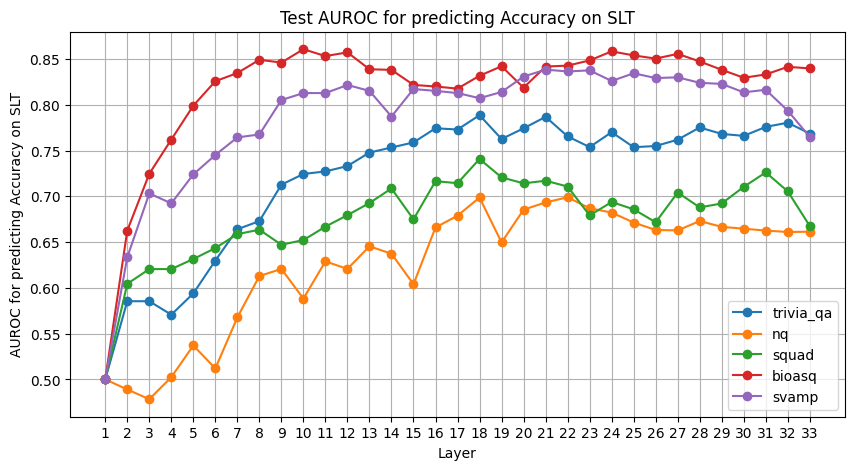

SLT: max AUROC for LR trained on trivia_qa's Accuracy and tested on trivia_qa's Accuracy:
	- 0.7886 at layer 18
	- 0.7868 at layer 21
	- 0.7804 at layer 32
	- 0.7758 at layer 31
	- 0.7751 at layer 28
SLT: max AUROC for LR trained on nq's Accuracy and tested on nq's Accuracy:
	- 0.6989 at layer 22
	- 0.6987 at layer 18
	- 0.6933 at layer 21
	- 0.6869 at layer 23
	- 0.6854 at layer 20
SLT: max AUROC for LR trained on squad's Accuracy and tested on squad's Accuracy:
	- 0.7407 at layer 18
	- 0.7261 at layer 31
	- 0.7207 at layer 19
	- 0.7170 at layer 21
	- 0.7165 at layer 16
SLT: max AUROC for LR trained on bioasq's Accuracy and tested on bioasq's Accuracy:
	- 0.8606 at layer 10
	- 0.8583 at layer 24
	- 0.8572 at layer 12
	- 0.8556 at layer 27
	- 0.8538 at layer 25
SLT: max AUROC for LR trained on svamp's Accuracy and tested on svamp's Accuracy:
	- 0.8383 at layer 21
	- 0.8375 at layer 23
	- 0.8363 at layer 22
	- 0.8343 at layer 25
	- 0.8307 at layer 20


In [25]:
# Plot test AUROC curves for all on predicting Accuracy
plot_metrics([D.ta_aucs for D in Ds], [f"{D.name}" for D in Ds], f'AUROC for predicting Accuracy on TBG')
best_metric([D.ta_aucs for D in Ds], train="Accuracy", test="Accuracy", ds=[[D.name]*2 for D in Ds])

plot_metrics([D.sa_aucs for D in Ds], [f"{D.name}" for D in Ds], f'AUROC for predicting Accuracy on SLT')
best_metric([D.sa_aucs for D in Ds], token="SLT", train="Accuracy", test="Accuracy", ds=[[D.name]*2 for D in Ds])

### Use linear probe trained on Binarized SE to predict Accuracy

Testing on trivia_qa-TBG 1/33
Test Loss: 0.6548, Test Accuracy: 0.6150, AUROC: 0.5627
Testing on trivia_qa-TBG 2/33
Test Loss: 0.6653, Test Accuracy: 0.5800, AUROC: 0.5558
Testing on trivia_qa-TBG 3/33
Test Loss: 0.6846, Test Accuracy: 0.6150, AUROC: 0.5892
Testing on trivia_qa-TBG 4/33
Test Loss: 0.6939, Test Accuracy: 0.6300, AUROC: 0.6063
Testing on trivia_qa-TBG 5/33
Test Loss: 0.7187, Test Accuracy: 0.6250, AUROC: 0.6121
Testing on trivia_qa-TBG 6/33
Test Loss: 0.7456, Test Accuracy: 0.6450, AUROC: 0.6207
Testing on trivia_qa-TBG 7/33
Test Loss: 0.7259, Test Accuracy: 0.6650, AUROC: 0.6683
Testing on trivia_qa-TBG 8/33
Test Loss: 0.7420, Test Accuracy: 0.6950, AUROC: 0.6759
Testing on trivia_qa-TBG 9/33
Test Loss: 0.8066, Test Accuracy: 0.6850, AUROC: 0.6736
Testing on trivia_qa-TBG 10/33
Test Loss: 0.8870, Test Accuracy: 0.6700, AUROC: 0.6746
Testing on trivia_qa-TBG 11/33
Test Loss: 0.8871, Test Accuracy: 0.6650, AUROC: 0.6948
Testing on trivia_qa-TBG 12/33
Test Loss: 1.0223, Te

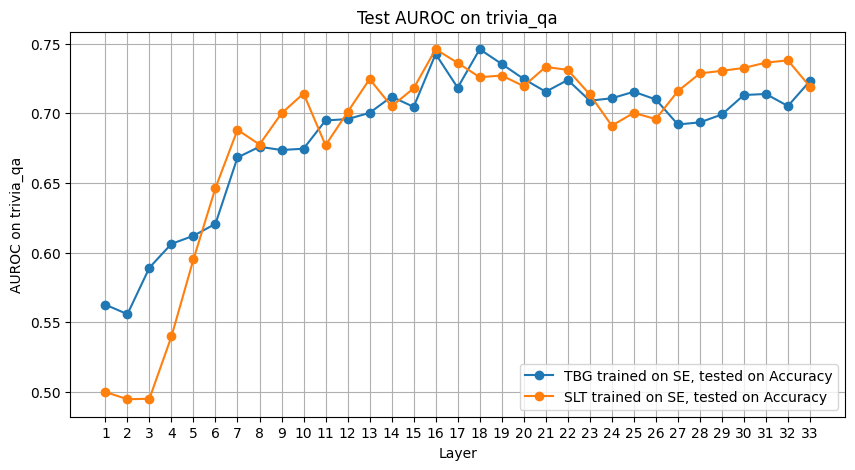

Testing on nq-TBG 1/33
Test Loss: 0.6675, Test Accuracy: 0.6250, AUROC: 0.5062
Testing on nq-TBG 2/33
Test Loss: 0.6780, Test Accuracy: 0.6000, AUROC: 0.5364
Testing on nq-TBG 3/33
Test Loss: 0.6744, Test Accuracy: 0.6250, AUROC: 0.5918
Testing on nq-TBG 4/33
Test Loss: 0.6960, Test Accuracy: 0.6100, AUROC: 0.5753
Testing on nq-TBG 5/33
Test Loss: 0.7441, Test Accuracy: 0.5750, AUROC: 0.5633
Testing on nq-TBG 6/33
Test Loss: 0.8038, Test Accuracy: 0.5800, AUROC: 0.5529
Testing on nq-TBG 7/33
Test Loss: 0.8177, Test Accuracy: 0.6050, AUROC: 0.5689
Testing on nq-TBG 8/33
Test Loss: 0.8810, Test Accuracy: 0.6150, AUROC: 0.5882
Testing on nq-TBG 9/33
Test Loss: 0.8730, Test Accuracy: 0.6400, AUROC: 0.6088
Testing on nq-TBG 10/33
Test Loss: 0.9158, Test Accuracy: 0.6450, AUROC: 0.6092
Testing on nq-TBG 11/33
Test Loss: 0.9249, Test Accuracy: 0.6900, AUROC: 0.6470
Testing on nq-TBG 12/33
Test Loss: 0.9765, Test Accuracy: 0.6700, AUROC: 0.6420
Testing on nq-TBG 13/33
Test Loss: 1.0081, Test A

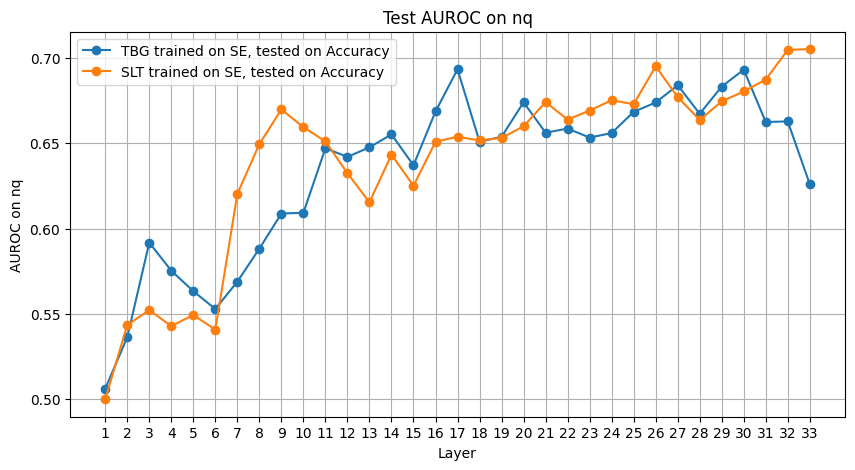

Testing on squad-TBG 1/33
Test Loss: 0.4740, Test Accuracy: 0.8100, AUROC: 0.6479
Testing on squad-TBG 2/33
Test Loss: 0.4775, Test Accuracy: 0.7950, AUROC: 0.6527
Testing on squad-TBG 3/33
Test Loss: 0.4774, Test Accuracy: 0.7800, AUROC: 0.6769
Testing on squad-TBG 4/33
Test Loss: 0.4956, Test Accuracy: 0.7850, AUROC: 0.6616
Testing on squad-TBG 5/33
Test Loss: 0.5102, Test Accuracy: 0.7800, AUROC: 0.6804
Testing on squad-TBG 6/33
Test Loss: 0.5476, Test Accuracy: 0.7650, AUROC: 0.6722
Testing on squad-TBG 7/33
Test Loss: 0.6399, Test Accuracy: 0.7350, AUROC: 0.6453
Testing on squad-TBG 8/33
Test Loss: 0.6277, Test Accuracy: 0.7350, AUROC: 0.6968
Testing on squad-TBG 9/33
Test Loss: 0.6537, Test Accuracy: 0.7450, AUROC: 0.6878
Testing on squad-TBG 10/33
Test Loss: 0.6718, Test Accuracy: 0.7700, AUROC: 0.7121
Testing on squad-TBG 11/33
Test Loss: 0.7193, Test Accuracy: 0.7800, AUROC: 0.7366
Testing on squad-TBG 12/33
Test Loss: 0.7979, Test Accuracy: 0.7600, AUROC: 0.7285
Testing on sq

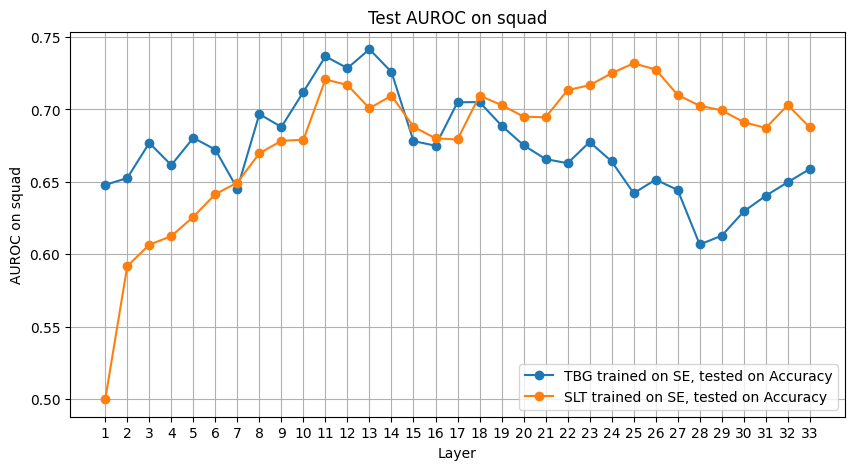

Testing on bioasq-TBG 1/33
Test Loss: 0.5552, Test Accuracy: 0.7850, AUROC: 0.8036
Testing on bioasq-TBG 2/33
Test Loss: 0.5641, Test Accuracy: 0.7850, AUROC: 0.8249
Testing on bioasq-TBG 3/33
Test Loss: 0.5953, Test Accuracy: 0.7900, AUROC: 0.8151
Testing on bioasq-TBG 4/33
Test Loss: 0.6044, Test Accuracy: 0.7850, AUROC: 0.8181
Testing on bioasq-TBG 5/33
Test Loss: 0.6453, Test Accuracy: 0.7850, AUROC: 0.8133
Testing on bioasq-TBG 6/33
Test Loss: 0.6888, Test Accuracy: 0.7850, AUROC: 0.8017
Testing on bioasq-TBG 7/33
Test Loss: 0.7516, Test Accuracy: 0.7800, AUROC: 0.7987
Testing on bioasq-TBG 8/33
Test Loss: 0.8252, Test Accuracy: 0.7850, AUROC: 0.7977
Testing on bioasq-TBG 9/33
Test Loss: 0.8554, Test Accuracy: 0.7750, AUROC: 0.8152
Testing on bioasq-TBG 10/33
Test Loss: 0.9178, Test Accuracy: 0.7800, AUROC: 0.8032
Testing on bioasq-TBG 11/33
Test Loss: 1.0033, Test Accuracy: 0.7850, AUROC: 0.8071
Testing on bioasq-TBG 12/33
Test Loss: 1.1579, Test Accuracy: 0.7650, AUROC: 0.7987
T

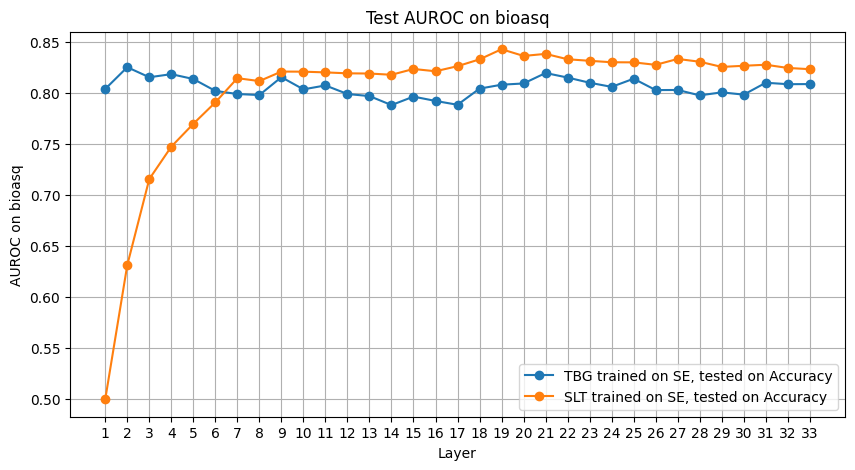

Testing on svamp-TBG 1/33
Test Loss: 0.7539, Test Accuracy: 0.4900, AUROC: 0.5392
Testing on svamp-TBG 2/33
Test Loss: 0.7336, Test Accuracy: 0.5000, AUROC: 0.6198
Testing on svamp-TBG 3/33
Test Loss: 0.7154, Test Accuracy: 0.5200, AUROC: 0.6283
Testing on svamp-TBG 4/33
Test Loss: 0.7171, Test Accuracy: 0.5400, AUROC: 0.6242
Testing on svamp-TBG 5/33
Test Loss: 0.7182, Test Accuracy: 0.5000, AUROC: 0.6379
Testing on svamp-TBG 6/33
Test Loss: 0.7041, Test Accuracy: 0.5400, AUROC: 0.6563
Testing on svamp-TBG 7/33
Test Loss: 0.7172, Test Accuracy: 0.5900, AUROC: 0.6803
Testing on svamp-TBG 8/33
Test Loss: 0.7136, Test Accuracy: 0.6300, AUROC: 0.7059
Testing on svamp-TBG 9/33
Test Loss: 0.6864, Test Accuracy: 0.6500, AUROC: 0.7451
Testing on svamp-TBG 10/33
Test Loss: 0.7592, Test Accuracy: 0.6400, AUROC: 0.7275
Testing on svamp-TBG 11/33
Test Loss: 0.8685, Test Accuracy: 0.6200, AUROC: 0.7091
Testing on svamp-TBG 12/33
Test Loss: 0.9066, Test Accuracy: 0.6200, AUROC: 0.7411
Testing on sv

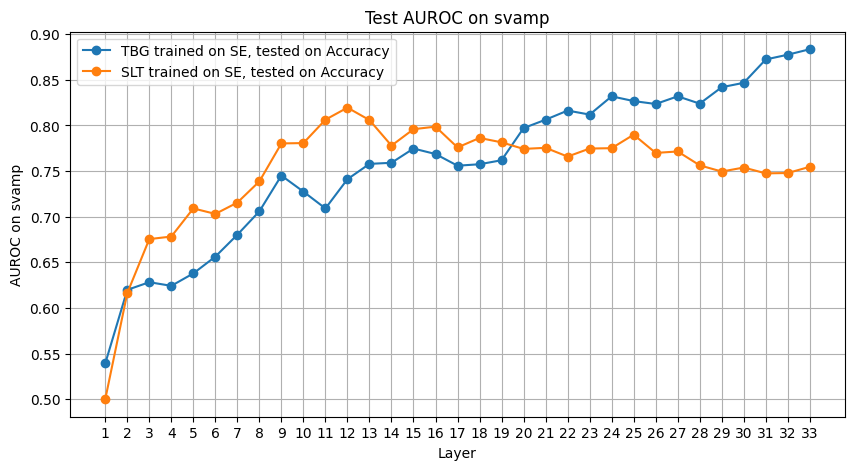

In [26]:
for D in Ds:
    # TBG
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.tbg_dataset, 1-D.accuracies, D.total_size) 
    tab_accs = []
    tab_aucs = []
    
    for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        print(f"Testing on {D.name}-TBG {i+1}/{len(X_tests)}")
        model = D.tb_models[i]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        tab_accs.append(test_acc)
        tab_aucs.append(test_auc)

    D.tab_accs = tab_accs
    D.tab_aucs = tab_aucs

    # SLT
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.slt_dataset, 1-D.accuracies, D.total_size)     
    sab_accs = []
    sab_aucs = []
    
    for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        print(f"Testing on {D.name}-SLT {i+1}/{len(X_tests)}")
        model = D.sb_models[i]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        sab_accs.append(test_acc)
        sab_aucs.append(test_auc)

    D.sab_accs = sab_accs
    D.sab_aucs = sab_aucs
    
    plot_metrics([tab_aucs, sab_aucs], ['TBG trained on SE, tested on Accuracy', 'SLT trained on SE, tested on Accuracy'], f'AUROC on {D.name}')

On TRIVIA_QA:


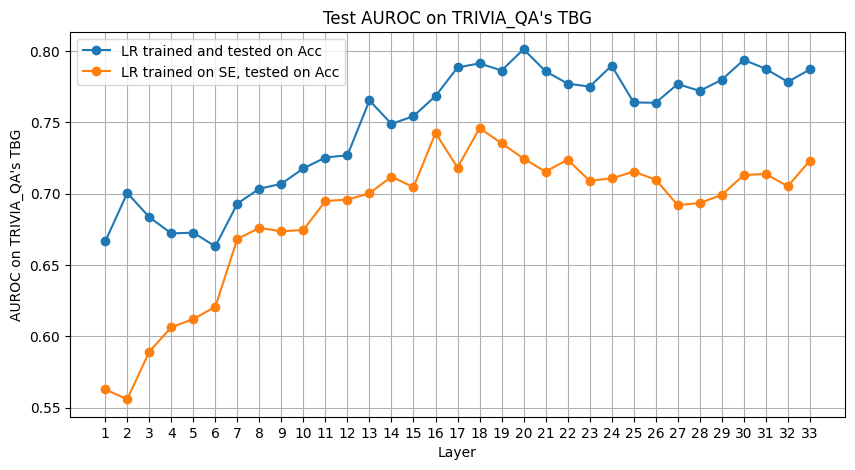

TBG: max AUROC for LR trained on TRIVIA_QA's Accuracy and tested on TRIVIA_QA's Accuracy:
	- 0.8013 at layer 20
	- 0.7938 at layer 30
	- 0.7914 at layer 18
	- 0.7898 at layer 24
	- 0.7885 at layer 17
TBG: max AUROC for LR trained on TRIVIA_QA's SE and tested on TRIVIA_QA's Accuracy:
	- 0.7459 at layer 18
	- 0.7425 at layer 16
	- 0.7354 at layer 19
	- 0.7246 at layer 20
	- 0.7238 at layer 22


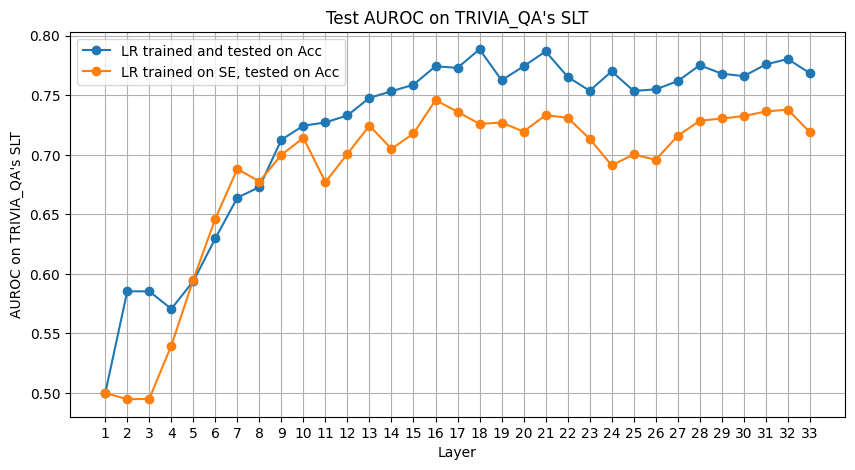

SLT: max AUROC for LR trained on TRIVIA_QA's Accuracy and tested on TRIVIA_QA's Accuracy:
	- 0.7886 at layer 18
	- 0.7868 at layer 21
	- 0.7804 at layer 32
	- 0.7758 at layer 31
	- 0.7751 at layer 28
SLT: max AUROC for LR trained on TRIVIA_QA's SE and tested on TRIVIA_QA's Accuracy:
	- 0.7459 at layer 16
	- 0.7379 at layer 32
	- 0.7363 at layer 31
	- 0.7361 at layer 17
	- 0.7332 at layer 21
On NQ:


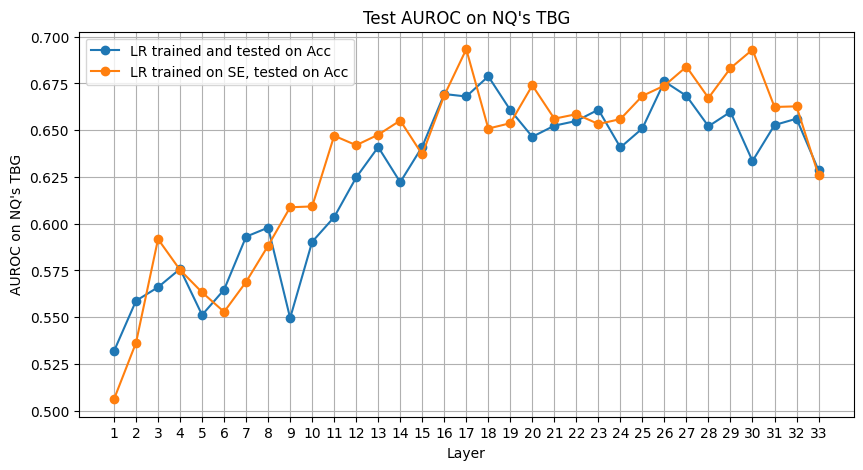

TBG: max AUROC for LR trained on NQ's Accuracy and tested on NQ's Accuracy:
	- 0.6788 at layer 18
	- 0.6760 at layer 26
	- 0.6693 at layer 16
	- 0.6684 at layer 27
	- 0.6680 at layer 17
TBG: max AUROC for LR trained on NQ's SE and tested on NQ's Accuracy:
	- 0.6933 at layer 17
	- 0.6931 at layer 30
	- 0.6840 at layer 27
	- 0.6832 at layer 29
	- 0.6740 at layer 20


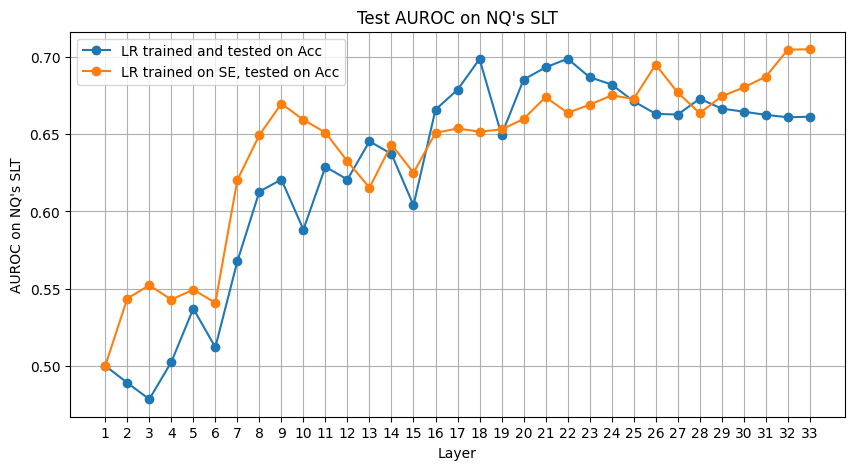

SLT: max AUROC for LR trained on NQ's Accuracy and tested on NQ's Accuracy:
	- 0.6989 at layer 22
	- 0.6987 at layer 18
	- 0.6933 at layer 21
	- 0.6869 at layer 23
	- 0.6854 at layer 20
SLT: max AUROC for LR trained on NQ's SE and tested on NQ's Accuracy:
	- 0.7051 at layer 33
	- 0.7047 at layer 32
	- 0.6951 at layer 26
	- 0.6873 at layer 31
	- 0.6803 at layer 30
On SQUAD:


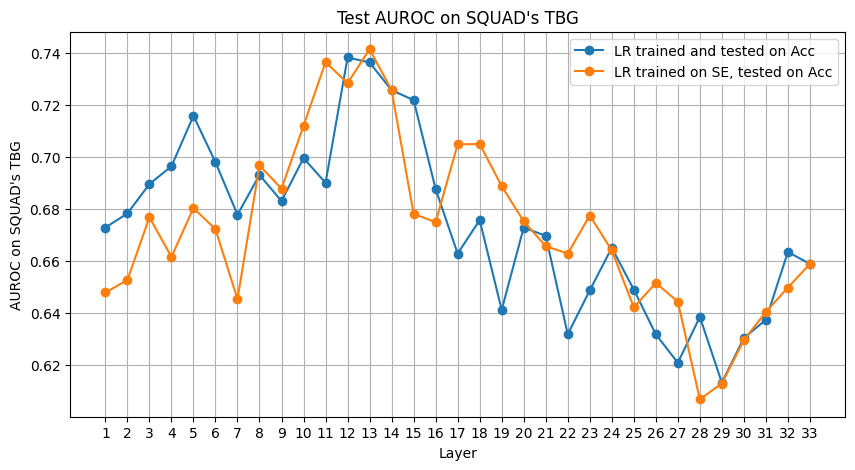

TBG: max AUROC for LR trained on SQUAD's Accuracy and tested on SQUAD's Accuracy:
	- 0.7383 at layer 12
	- 0.7364 at layer 13
	- 0.7258 at layer 14
	- 0.7219 at layer 15
	- 0.7159 at layer 5
TBG: max AUROC for LR trained on SQUAD's SE and tested on SQUAD's Accuracy:
	- 0.7415 at layer 13
	- 0.7366 at layer 11
	- 0.7285 at layer 12
	- 0.7258 at layer 14
	- 0.7121 at layer 10


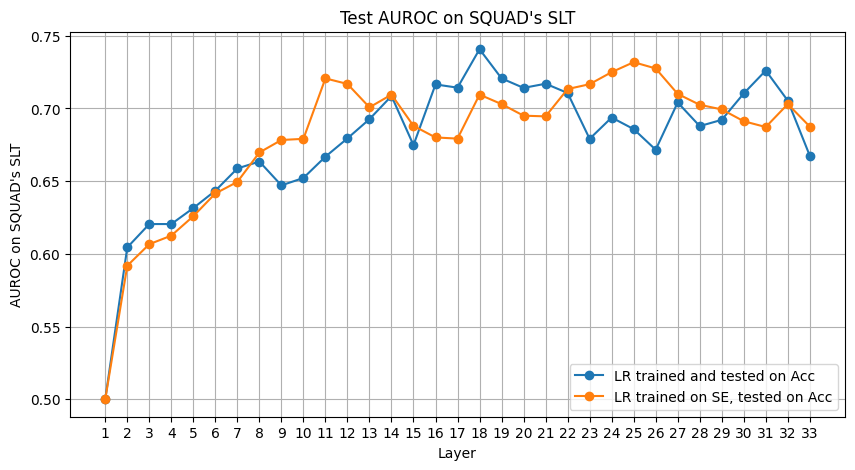

SLT: max AUROC for LR trained on SQUAD's Accuracy and tested on SQUAD's Accuracy:
	- 0.7407 at layer 18
	- 0.7261 at layer 31
	- 0.7207 at layer 19
	- 0.7170 at layer 21
	- 0.7165 at layer 16
SLT: max AUROC for LR trained on SQUAD's SE and tested on SQUAD's Accuracy:
	- 0.7318 at layer 25
	- 0.7275 at layer 26
	- 0.7250 at layer 24
	- 0.7207 at layer 11
	- 0.7168 at layer 12
On BIOASQ:


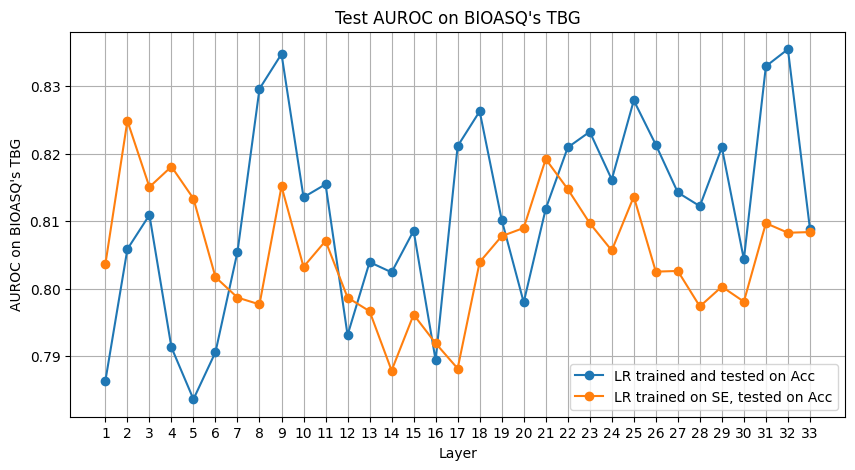

TBG: max AUROC for LR trained on BIOASQ's Accuracy and tested on BIOASQ's Accuracy:
	- 0.8355 at layer 32
	- 0.8348 at layer 9
	- 0.8330 at layer 31
	- 0.8296 at layer 8
	- 0.8279 at layer 25
TBG: max AUROC for LR trained on BIOASQ's SE and tested on BIOASQ's Accuracy:
	- 0.8249 at layer 2
	- 0.8192 at layer 21
	- 0.8181 at layer 4
	- 0.8152 at layer 9
	- 0.8151 at layer 3


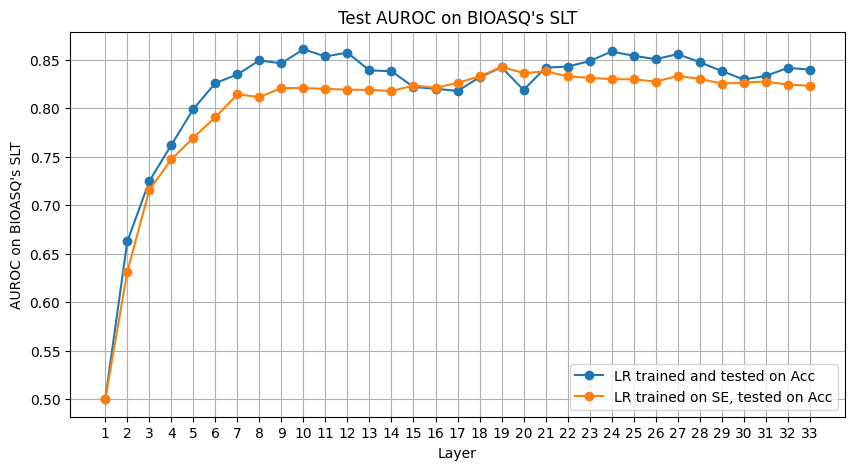

SLT: max AUROC for LR trained on BIOASQ's Accuracy and tested on BIOASQ's Accuracy:
	- 0.8606 at layer 10
	- 0.8583 at layer 24
	- 0.8572 at layer 12
	- 0.8556 at layer 27
	- 0.8538 at layer 25
SLT: max AUROC for LR trained on BIOASQ's SE and tested on BIOASQ's Accuracy:
	- 0.8425 at layer 19
	- 0.8379 at layer 21
	- 0.8359 at layer 20
	- 0.8330 at layer 27
	- 0.8327 at layer 22
On SVAMP:


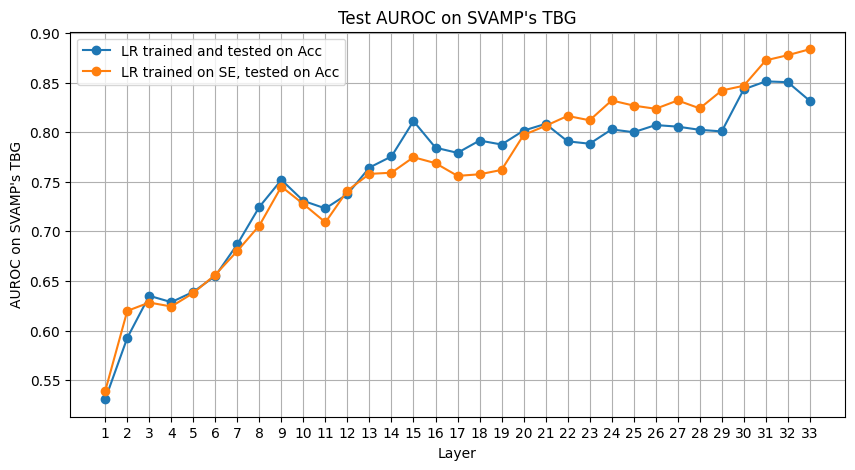

TBG: max AUROC for LR trained on SVAMP's Accuracy and tested on SVAMP's Accuracy:
	- 0.8511 at layer 31
	- 0.8503 at layer 32
	- 0.8431 at layer 30
	- 0.8315 at layer 33
	- 0.8111 at layer 15
TBG: max AUROC for LR trained on SVAMP's SE and tested on SVAMP's Accuracy:
	- 0.8836 at layer 33
	- 0.8776 at layer 32
	- 0.8723 at layer 31
	- 0.8467 at layer 30
	- 0.8419 at layer 29


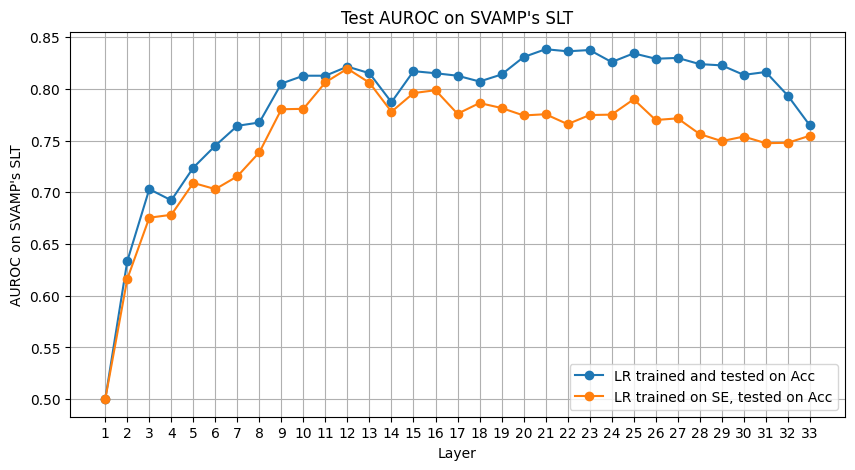

SLT: max AUROC for LR trained on SVAMP's Accuracy and tested on SVAMP's Accuracy:
	- 0.8383 at layer 21
	- 0.8375 at layer 23
	- 0.8363 at layer 22
	- 0.8343 at layer 25
	- 0.8307 at layer 20
SLT: max AUROC for LR trained on SVAMP's SE and tested on SVAMP's Accuracy:
	- 0.8195 at layer 12
	- 0.8063 at layer 11
	- 0.8059 at layer 13
	- 0.7987 at layer 16
	- 0.7959 at layer 15


In [27]:
for D in Ds:
    print(f"On {D.name.upper()}:")
    plot_metrics([D.ta_aucs, D.tab_aucs], ["LR trained and tested on Acc", "LR trained on SE, tested on Acc"], f"AUROC on {D.name.upper()}'s TBG")
    best_metric([D.ta_aucs], token="TBG", train="Accuracy", test="Accuracy", ds=[[D.name.upper()]*2])
    best_metric([D.tab_aucs], token="TBG", train="SE", test="Accuracy", ds=[[D.name.upper()]*2])
    
    plot_metrics([D.sa_aucs, D.sab_aucs], ["LR trained and tested on Acc", "LR trained on SE, tested on Acc"], f"AUROC on {D.name.upper()}'s SLT")
    best_metric([D.sa_aucs], token="SLT", train="Accuracy", test="Accuracy", ds=[[D.name.upper()]*2])
    best_metric([D.sab_aucs], token="SLT", train="SE", test="Accuracy", ds=[[D.name.upper()]*2])

## Generalize probes trained on 4 datasets' SE to the other's SE/Acc prediction

We will test probes **trained** on the union of different D's SLT SE.

In [28]:
# Utility to merge X's and y's (assume SLT)
def merge_Xs_and_ys(Ds, other_ids, attribute='b_entropy'):
    """Ds are the collection of dataset instances; other_ids are the other four datasets"""
    print("Merging datasets")
    all_Xs_and_ys = ()
    for id_ in other_ids:
        D = Ds[id_]
        # X_trains, X_vals, X_tests, y_trains, y_vals, y_tests
        Xs_and_ys = create_Xs_and_ys(D.slt_dataset, getattr(D, attribute), D.total_size)
        all_Xs_and_ys += (Xs_and_ys,)
    
    # merge xs and ys by splits
    all_splits = list(zip(*all_Xs_and_ys))
    results = ()
    for splits in all_splits:
        all_layers = [[] for _ in range(len(splits[0]))]
        for split in splits:
            for i, layer in enumerate(split):
                all_layers[i].append(layer)
        results += ([np.concatenate(l, axis=0) for l in all_layers],)

    print(f"Dummy test accuracy: {max(np.mean(results[-1]), 1-np.mean(results[-1])):.4f}")
    return results            

In [141]:
# Test merge_Xs_and_ys
# results = merge_Xs_and_ys(Ds, [0,1,2])
# len(results), len(results[0]), results[5][0].shape

Training on datasets ['nq', 'squad', 'bioasq', 'svamp']'s SLT-SE to predict trivia_qa's SLT-Acc
Merging datasets
Dummy test accuracy: 0.6357
Training on SLT-SE 1/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6532, AUROC: 0.5000
Training Loss: 0.6522, Validation Loss: 0.6457
Test Loss: 0.6559, Test Accuracy: 0.6357, AUROC: 0.5000
Training on SLT-SE 2/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6579, AUROC: 0.6469
Training Loss: 0.6283, Validation Loss: 0.6196
Test Loss: 0.6380, Test Accuracy: 0.6486, AUROC: 0.6125
Training on SLT-SE 3/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.7079, AUROC: 0.6641
Training Loss: 0.6154, Validation Loss: 0.6097
Test Loss: 0.6223, Test Accuracy: 0.6843, AUROC: 0.6571
Training on SLT-SE 4/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.7310, AUROC: 0.7089
Training Loss: 0.5838, Validation Loss: 0.5809
Test Loss: 0.5938, Test Accuracy: 0.7000, AUROC: 0.7057
Training on SLT-SE 5/33 - ['nq'

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7516, AUROC: 0.7438
Training Loss: 0.5482, Validation Loss: 0.5502
Test Loss: 0.5687, Test Accuracy: 0.7214, AUROC: 0.7313
Training on SLT-SE 6/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7595, AUROC: 0.7766
Training Loss: 0.4986, Validation Loss: 0.5201
Test Loss: 0.5359, Test Accuracy: 0.7443, AUROC: 0.7669
Training on SLT-SE 7/33 - ['nq', 'squad', 'bioasq', 'svamp']


...

Validation Accuracy: 0.8048, AUROC: 0.8634
Training Loss: 0.0060, Validation Loss: 1.9914
Test Loss: 2.3029, Test Accuracy: 0.7814, AUROC: 0.8338
Training on SLT-SE 32/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8048, AUROC: 0.8670
Training Loss: 0.0066, Validation Loss: 1.8614
Test Loss: 2.1488, Test Accuracy: 0.7943, AUROC: 0.8467
Training on SLT-SE 33/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8016, AUROC: 0.8500
Training Loss: 0.0191, Validation Loss: 1.5630
Test Loss: 1.6114, Test Accuracy: 0.8029, AUROC: 0.8459


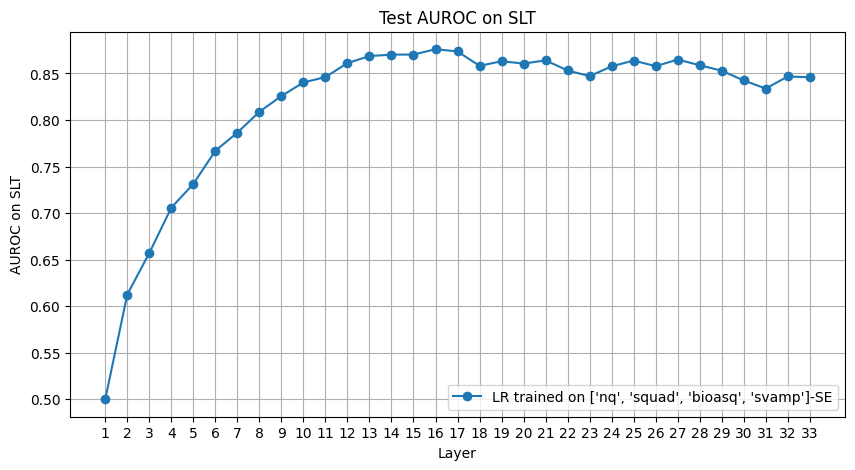

Training on datasets ['nq', 'squad', 'bioasq', 'svamp']'s SLT-Acc to predict trivia_qa's SLT-Acc
Merging datasets
Dummy test accuracy: 0.6443
Training on SLT-Acc 1/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6341, AUROC: 0.5000
Training Loss: 0.6554, Validation Loss: 0.6567
Test Loss: 0.6510, Test Accuracy: 0.6443, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6341, AUROC: 0.6146
Training Loss: 0.6390, Validation Loss: 0.6407
Test Loss: 0.6305, Test Accuracy: 0.6443, AUROC: 0.6380
Training on SLT-Acc 3/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6341, AUROC: 0.6300
Training Loss: 0.6306, Validation Loss: 0.6343
Test Loss: 0.6213, Test Accuracy: 0.6429, AUROC: 0.6533
Training on SLT-Acc 4/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6730, AUROC: 0.6579
Training Loss: 0.6145, Validation Loss: 0.6219
Test Loss: 0.6073, Test Accuracy: 0.6871, AUROC: 0.6855
Training on SLT-Acc 5/33 -

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6968, AUROC: 0.7150
Training Loss: 0.5650, Validation Loss: 0.5892
Test Loss: 0.5729, Test Accuracy: 0.7229, AUROC: 0.7329
Training on SLT-Acc 7/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6992, AUROC: 0.7230
Training Loss: 0.5424, Validation Loss: 0.5817
Test Loss: 0.5607, Test Accuracy: 0.7329, AUROC: 0.7420
Training on SLT-Acc 8/33 - ['nq', 'squad', 'bioasq', 'svamp']


...

Validation Accuracy: 0.6817, AUROC: 0.7046
Training Loss: 0.0330, Validation Loss: 3.6762
Test Loss: 3.2350, Test Accuracy: 0.7114, AUROC: 0.7359
Training on SLT-Acc 32/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6667, AUROC: 0.6961
Training Loss: 0.0529, Validation Loss: 3.0011
Test Loss: 2.7587, Test Accuracy: 0.6971, AUROC: 0.7351
Training on SLT-Acc 33/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6754, AUROC: 0.6971
Training Loss: 0.1164, Validation Loss: 1.8891
Test Loss: 1.7707, Test Accuracy: 0.6986, AUROC: 0.7271


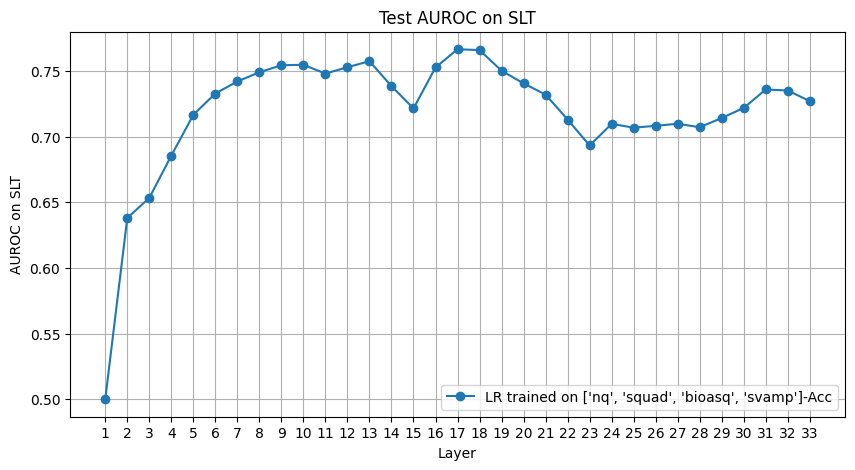

Training on datasets ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SLT-SE to predict nq's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5757
Training on SLT-SE 1/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.5762, AUROC: 0.5000
Training Loss: 0.6804, Validation Loss: 0.6815
Test Loss: 0.6817, Test Accuracy: 0.5757, AUROC: 0.5000
Training on SLT-SE 2/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6421, AUROC: 0.7042
Training Loss: 0.6408, Validation Loss: 0.6387
Test Loss: 0.6506, Test Accuracy: 0.6229, AUROC: 0.6610
Training on SLT-SE 3/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6873, AUROC: 0.7244
Training Loss: 0.6170, Validation Loss: 0.6187
Test Loss: 0.6293, Test Accuracy: 0.6629, AUROC: 0.6972
Training on SLT-SE 4/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.7151, AUROC: 0.7648
Training Loss: 0.5804, Validation Loss: 0.5832
Test Loss: 0.5944, Test Accuracy: 0.7129, AUROC: 0.7472
Tra

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7452, AUROC: 0.7996
Training Loss: 0.5437, Validation Loss: 0.5475
Test Loss: 0.5634, Test Accuracy: 0.7343, AUROC: 0.7780
Training on SLT-SE 6/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.7722, AUROC: 0.8179
Training Loss: 0.4935, Validation Loss: 0.5197
Test Loss: 0.5300, Test Accuracy: 0.7600, AUROC: 0.8083
Training on SLT-SE 7/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7738, AUROC: 0.8395
Training Loss: 0.4500, Validation Loss: 0.4865
Test Loss: 0.5077, Test Accuracy: 0.7600, AUROC: 0.8198
Training on SLT-SE 8/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


...

Validation Accuracy: 0.7984, AUROC: 0.8839
Training Loss: 0.0084, Validation Loss: 1.5947
Test Loss: 1.7653, Test Accuracy: 0.8229, AUROC: 0.8754
Training on SLT-SE 32/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8119, AUROC: 0.8848
Training Loss: 0.0099, Validation Loss: 1.7760
Test Loss: 2.0387, Test Accuracy: 0.8271, AUROC: 0.8755
Training on SLT-SE 33/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8048, AUROC: 0.8622
Training Loss: 0.0220, Validation Loss: 1.7105
Test Loss: 1.7063, Test Accuracy: 0.8114, AUROC: 0.8684


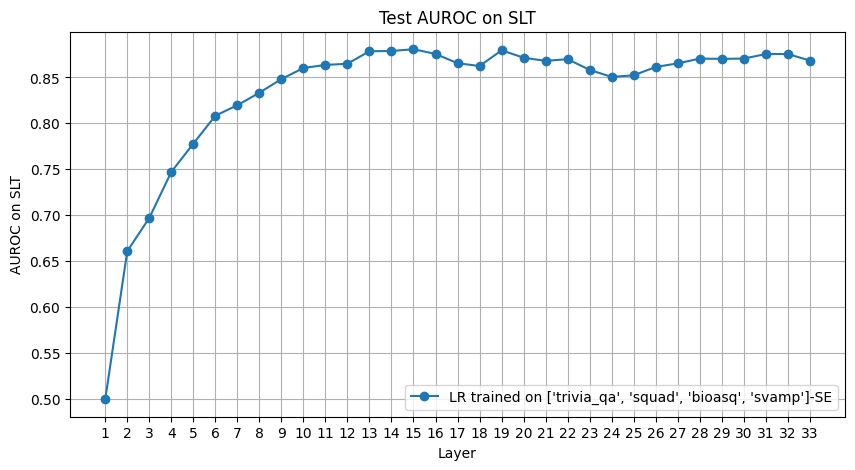

Training on datasets ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SLT-Acc to predict nq's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5657
Training on SLT-Acc 1/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.5556, AUROC: 0.5000
Training Loss: 0.6853, Validation Loss: 0.6871
Test Loss: 0.6845, Test Accuracy: 0.5657, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6310, AUROC: 0.6878
Training Loss: 0.6480, Validation Loss: 0.6495
Test Loss: 0.6493, Test Accuracy: 0.6186, AUROC: 0.6845
Training on SLT-Acc 3/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6468, AUROC: 0.7057
Training Loss: 0.6291, Validation Loss: 0.6302
Test Loss: 0.6331, Test Accuracy: 0.6286, AUROC: 0.6982
Training on SLT-Acc 4/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6881, AUROC: 0.7348
Training Loss: 0.6031, Validation Loss: 0.6079
Test Loss: 0.6139, Test Accuracy: 0.6714, AUROC: 0.722

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7198, AUROC: 0.7527
Training Loss: 0.5836, Validation Loss: 0.5900
Test Loss: 0.5902, Test Accuracy: 0.7057, AUROC: 0.7516
Training on SLT-Acc 6/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7167, AUROC: 0.7673
Training Loss: 0.5519, Validation Loss: 0.5751
Test Loss: 0.5732, Test Accuracy: 0.7129, AUROC: 0.7713
Training on SLT-Acc 7/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


...

Validation Accuracy: 0.6865, AUROC: 0.7406
Training Loss: 0.0424, Validation Loss: 2.8890
Test Loss: 2.5784, Test Accuracy: 0.7314, AUROC: 0.7861
Training on SLT-Acc 32/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6857, AUROC: 0.7400
Training Loss: 0.0477, Validation Loss: 2.8020
Test Loss: 2.3290, Test Accuracy: 0.7357, AUROC: 0.7990
Training on SLT-Acc 33/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6905, AUROC: 0.7419
Training Loss: 0.0836, Validation Loss: 2.0967
Test Loss: 1.9458, Test Accuracy: 0.7286, AUROC: 0.7803


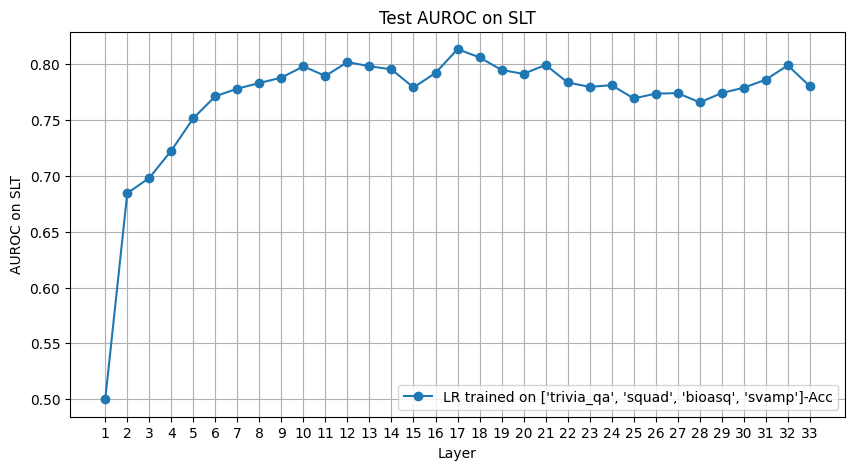

Training on datasets ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SLT-SE to predict squad's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5357
Training on SLT-SE 1/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.5444, AUROC: 0.5000
Training Loss: 0.6900, Validation Loss: 0.6892
Test Loss: 0.6906, Test Accuracy: 0.5357, AUROC: 0.5000
Training on SLT-SE 2/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6373, AUROC: 0.6737
Training Loss: 0.6642, Validation Loss: 0.6568
Test Loss: 0.6683, Test Accuracy: 0.6186, AUROC: 0.6321
Training on SLT-SE 3/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6659, AUROC: 0.6930
Training Loss: 0.6476, Validation Loss: 0.6406
Test Loss: 0.6535, Test Accuracy: 0.6414, AUROC: 0.6626
Training on SLT-SE 4/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6921, AUROC: 0.7365
Training Loss: 0.6174, Validation Loss: 0.6110
Test Loss: 0.6255, Test Accuracy: 0.6786, AUROC: 0.7131
Training on SLT

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7381, AUROC: 0.8061
Training Loss: 0.5342, Validation Loss: 0.5441
Test Loss: 0.5574, Test Accuracy: 0.7157, AUROC: 0.7872
Training on SLT-SE 7/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7413, AUROC: 0.8220
Training Loss: 0.4871, Validation Loss: 0.5132
Test Loss: 0.5262, Test Accuracy: 0.7214, AUROC: 0.8061
Training on SLT-SE 8/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


...

Validation Accuracy: 0.8048, AUROC: 0.8590
Training Loss: 0.0101, Validation Loss: 1.9922
Test Loss: 1.8835, Test Accuracy: 0.7871, AUROC: 0.8563
Training on SLT-SE 32/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7968, AUROC: 0.8632
Training Loss: 0.0108, Validation Loss: 2.2004
Test Loss: 2.1926, Test Accuracy: 0.7943, AUROC: 0.8591
Training on SLT-SE 33/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7921, AUROC: 0.8414
Training Loss: 0.0261, Validation Loss: 2.0174
Test Loss: 1.8643, Test Accuracy: 0.7957, AUROC: 0.8486


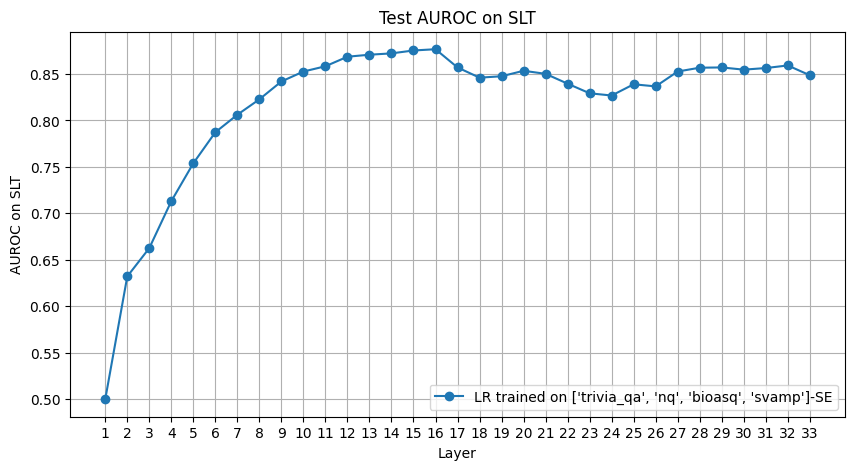

Training on datasets ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SLT-Acc to predict squad's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5214
Training on SLT-Acc 1/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.5056, AUROC: 0.5000
Training Loss: 0.6923, Validation Loss: 0.6936
Test Loss: 0.6922, Test Accuracy: 0.5214, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6079, AUROC: 0.6294
Training Loss: 0.6695, Validation Loss: 0.6703
Test Loss: 0.6727, Test Accuracy: 0.5943, AUROC: 0.6173
Training on SLT-Acc 3/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6063, AUROC: 0.6462
Training Loss: 0.6581, Validation Loss: 0.6611
Test Loss: 0.6660, Test Accuracy: 0.6000, AUROC: 0.6297
Training on SLT-Acc 4/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6349, AUROC: 0.6778
Training Loss: 0.6404, Validation Loss: 0.6471
Test Loss: 0.6541, Test Accuracy: 0.6357, AUROC: 0.6638
Training o

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6762, AUROC: 0.7254
Training Loss: 0.5901, Validation Loss: 0.6156
Test Loss: 0.6196, Test Accuracy: 0.6857, AUROC: 0.7173
Training on SLT-Acc 7/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6643, AUROC: 0.7328
Training Loss: 0.5680, Validation Loss: 0.6073
Test Loss: 0.6084, Test Accuracy: 0.6729, AUROC: 0.7277
Training on SLT-Acc 8/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


...

Validation Accuracy: 0.6865, AUROC: 0.7363
Training Loss: 0.0405, Validation Loss: 3.1975
Test Loss: 3.3639, Test Accuracy: 0.6829, AUROC: 0.7330
Training on SLT-Acc 32/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6786, AUROC: 0.7335
Training Loss: 0.0346, Validation Loss: 3.5446
Test Loss: 3.7741, Test Accuracy: 0.6886, AUROC: 0.7305
Training on SLT-Acc 33/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6889, AUROC: 0.7385
Training Loss: 0.1113, Validation Loss: 2.0936
Test Loss: 2.2321, Test Accuracy: 0.7043, AUROC: 0.7260


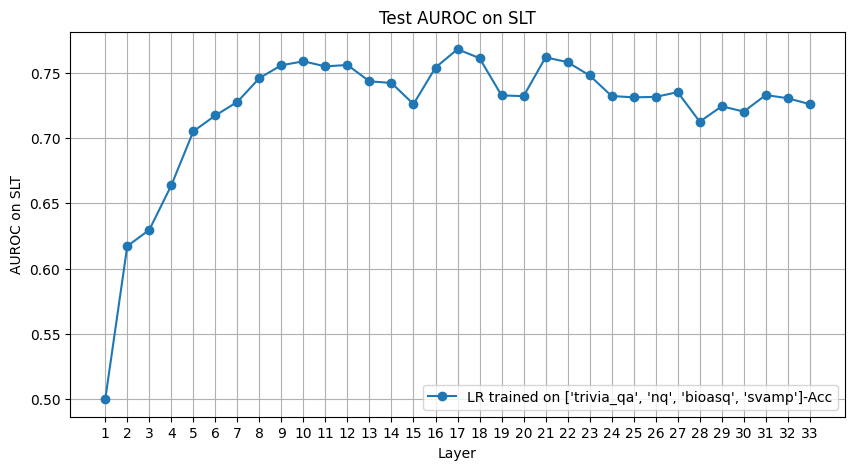

Training on datasets ['trivia_qa', 'nq', 'squad', 'svamp']'s SLT-SE to predict bioasq's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5914
Training on SLT-SE 1/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6079, AUROC: 0.5000
Training Loss: 0.6709, Validation Loss: 0.6697
Test Loss: 0.6767, Test Accuracy: 0.5914, AUROC: 0.5000
Training on SLT-SE 2/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6500, AUROC: 0.6981
Training Loss: 0.6372, Validation Loss: 0.6320
Test Loss: 0.6459, Test Accuracy: 0.6314, AUROC: 0.6681
Training on SLT-SE 3/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6754, AUROC: 0.6948
Training Loss: 0.6241, Validation Loss: 0.6198
Test Loss: 0.6372, Test Accuracy: 0.6400, AUROC: 0.6694
Training on SLT-SE 4/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6857, AUROC: 0.7122
Training Loss: 0.6086, Validation Loss: 0.6046
Test Loss: 0.6243, Test Accuracy: 0.6543, AUROC: 0.6908
Training on SLT-SE 

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7032, AUROC: 0.7603
Training Loss: 0.5293, Validation Loss: 0.5670
Test Loss: 0.5820, Test Accuracy: 0.6957, AUROC: 0.7457
Training on SLT-SE 8/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7159, AUROC: 0.7745
Training Loss: 0.4849, Validation Loss: 0.5518
Test Loss: 0.5775, Test Accuracy: 0.6886, AUROC: 0.7515
Training on SLT-SE 9/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


...

Validation Accuracy: 0.7651, AUROC: 0.8248
Training Loss: 0.0120, Validation Loss: 2.4312
Test Loss: 2.5172, Test Accuracy: 0.7514, AUROC: 0.8093
Training on SLT-SE 32/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7667, AUROC: 0.8283
Training Loss: 0.0119, Validation Loss: 2.3020
Test Loss: 2.4557, Test Accuracy: 0.7571, AUROC: 0.8169
Training on SLT-SE 33/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7500, AUROC: 0.8013
Training Loss: 0.0290, Validation Loss: 2.3358
Test Loss: 2.1474, Test Accuracy: 0.7629, AUROC: 0.8111


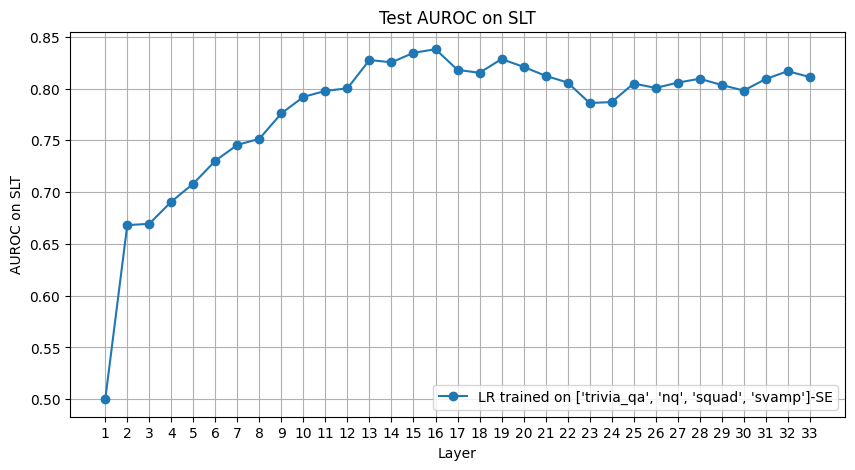

Training on datasets ['trivia_qa', 'nq', 'squad', 'svamp']'s SLT-Acc to predict bioasq's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5929
Training on SLT-Acc 1/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.5706, AUROC: 0.5000
Training Loss: 0.6822, Validation Loss: 0.6832
Test Loss: 0.6765, Test Accuracy: 0.5929, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6429, AUROC: 0.6854
Training Loss: 0.6439, Validation Loss: 0.6445
Test Loss: 0.6402, Test Accuracy: 0.6543, AUROC: 0.6831
Training on SLT-Acc 3/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6690, AUROC: 0.6976
Training Loss: 0.6295, Validation Loss: 0.6273
Test Loss: 0.6278, Test Accuracy: 0.6557, AUROC: 0.6936
Training on SLT-Acc 4/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6730, AUROC: 0.7120
Training Loss: 0.6134, Validation Loss: 0.6140
Test Loss: 0.6162, Test Accuracy: 0.6700, AUROC: 0.7037
Training on SL

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6897, AUROC: 0.7372
Training Loss: 0.5756, Validation Loss: 0.5963
Test Loss: 0.5919, Test Accuracy: 0.7057, AUROC: 0.7339
Training on SLT-Acc 7/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6770, AUROC: 0.7361
Training Loss: 0.5531, Validation Loss: 0.5959
Test Loss: 0.5862, Test Accuracy: 0.6871, AUROC: 0.7417
Training on SLT-Acc 8/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.7462
Training Loss: 0.5214, Validation Loss: 0.5878
Test Loss: 0.5858, Test Accuracy: 0.6943, AUROC: 0.7399
Training on SLT-Acc 9/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7016, AUROC: 0.7545
Training Loss: 0.4905, Validation Loss: 0.5826
Test Loss: 0.5804, Test Accuracy: 0.7057, AUROC: 0.7497
Training on SLT-Acc 10/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


In [ ]:
# Train
from sklearn.base import clone

for i, D in enumerate(Ds):
    other_ids = D.other_ids
    other_names = D.other_names
    
    print(f"Training on datasets {other_names}'s SLT-SE to predict {D.name}'s SLT-Acc")

    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = merge_Xs_and_ys(Ds, other_ids, 'b_entropy')
    osb_accs = []
    osb_aucs = []
    osb_models = []
    
    for k, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on SLT-SE {k+1}/{len(X_trains)} - {other_names}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {other_names}-SLT-SE {k+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        osb_accs.append(test_acc)
        osb_aucs.append(test_auc)
        osb_models.append(model)

    plot_metrics([osb_aucs], [f'LR trained on {other_names}-SE'], f'AUROC on SLT')

    D.osb_accs = osb_accs
    D.osb_aucs = osb_aucs
    D.osb_models = osb_models

    print(f"Training on datasets {other_names}'s SLT-Acc to predict {D.name}'s SLT-Acc")

    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = merge_Xs_and_ys(Ds, other_ids, 'accuracies')
    osa_accs = []
    osa_aucs = []
    osa_models = []
    
    for k, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on SLT-Acc {k+1}/{len(X_trains)} - {other_names}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {other_names}-SLT-Acc {k+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        osa_accs.append(test_acc)
        osa_aucs.append(test_auc)
        osa_models.append(model)

    D.osa_accs = osa_accs
    D.osa_aucs = osa_aucs
    D.osa_models = osa_models

    plot_metrics([osa_aucs], [f'LR trained on {other_names}-Acc'], f'AUROC on SLT')

In [ ]:
for D in Ds:
    plot_metrics([D.osb_aucs, D.osa_aucs], [f'LR trained and tested on {D.other_names}-Binarized SE', f'LR trained and tested on {D.other_names}-Accuracy'], f'AUROC on SLT')
    best_metric([D.osb_aucs], token="SLT", train="SE", test="SE", ds=[[D.other_names]*2])
    best_metric([D.osa_aucs], token="SLT", train="Acc", test="Acc", ds=[[D.other_names]*2])

We see the best layers are mostly from layer `12` to `15`.

In [245]:
# Test
def test_n_on_one(D):
    other_ids = D.other_ids
    other_names = D.other_names
    osb_models = D.osb_models
    osa_models = D.osa_models
    
    print(f"Testing on {D.name}'s SE")
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.slt_dataset, D.b_entropy, D.total_size) 
    isb_accs = []
    isb_aucs = []
    
    for k, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        # print(f"Testing on {D.name}-SLT-SE {k+1}/{len(X_tests)}")
        model = osb_models[k]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True, silent=True)
        isb_accs.append(test_acc)
        isb_aucs.append(test_auc)

    D.isb_accs = isb_accs
    D.isb_aucs = isb_aucs
    plot_metrics([D.sb_aucs, D.isb_aucs], [f'LR trained and tested on {D.name}-SE', 
                                                       # f'LR trained and tested on \n{other_names}-SE',
                                                       f'LR trained on {other_names}-SE \n and tested on {D.name}-SE'], 
                 f'AUROC on SLT')
    best_metric([D.sb_aucs], token="SLT", train="SE", test="SE", ds=[[D.name]*2])
    best_metric([D.isb_aucs], token="SLT", train="SE", test="SE", ds=[[other_names, D.name]])

    print(f"\nTesting on {D.name}'s Acc")
    r_acc = 1 - D.accuracies
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.slt_dataset, r_acc, D.total_size) 
    isab_accs = []
    isab_aucs = []
    isaa_accs = []
    isaa_aucs = []

    for k, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        # print(f"Testing on {D.name}-SLT-Acc {k+1}/{len(X_tests)}")
        b_model = osb_models[k]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(b_model, X_test, y_test, binary_cls=True, silent=True)
        isab_accs.append(test_acc)
        isab_aucs.append(test_auc)
        
        a_model = osa_models[k]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(a_model, X_test, y_test, binary_cls=True, silent=True)
        isaa_accs.append(test_acc)
        isaa_aucs.append(test_auc)
    
    D.isab_accs = isab_accs
    D.isab_aucs = isab_aucs
    D.isaa_accs = isaa_accs
    D.isaa_aucs = isaa_aucs

    plot_metrics([D.sa_aucs, D.sab_aucs, D.isab_aucs, D.isaa_aucs], 
                 [f'LR trained and tested on {D.name}-Acc', 
                  f'LR trained on {D.name}-SE\n and tested on {D.name}-Acc', 
                  f'LR trained on {other_names}-SE\n and tested on {D.name}-Acc', 
                  f'LR trained on {other_names}-Acc\n and tested on {D.name}-Acc ',
                 ], 
                 f'AUROC on SLT')
    best_metric([D.sa_aucs], token="SLT", train="Acc", test="Acc", ds=[[D.name]*2])
    best_metric([D.sab_aucs], token="SLT", train="SE", test="Acc", ds=[[D.name]*2])
    best_metric([D.isab_aucs], token="SLT", train="SE", test="Acc", ds=[[other_names, D.name]])
    best_metric([D.isaa_aucs], token="SLT", train="Acc", test="Acc", ds=[[other_names, D.name]])

Testing on trivia_qa's SE


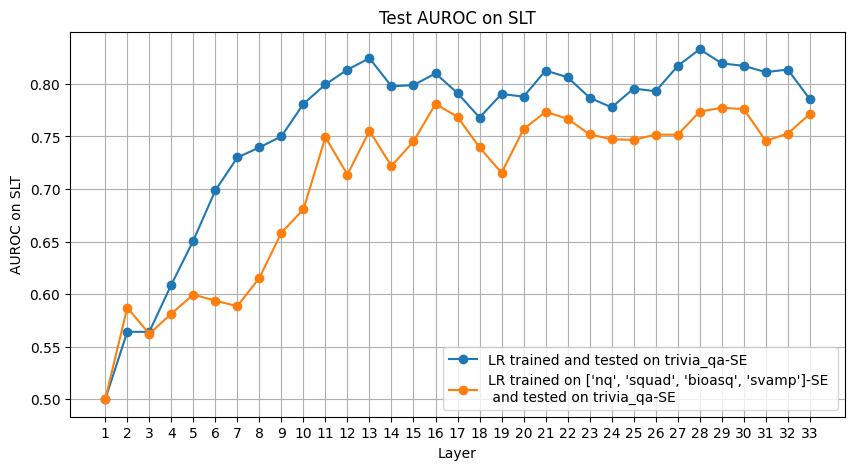

SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's SE:
	- 0.8330 at layer 28
	- 0.8245 at layer 13
	- 0.8196 at layer 29
	- 0.8172 at layer 30
	- 0.8171 at layer 27
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's SE:
	- 0.7809 at layer 16
	- 0.7773 at layer 29
	- 0.7760 at layer 30
	- 0.7736 at layer 28
	- 0.7734 at layer 21

Testing on trivia_qa's Acc


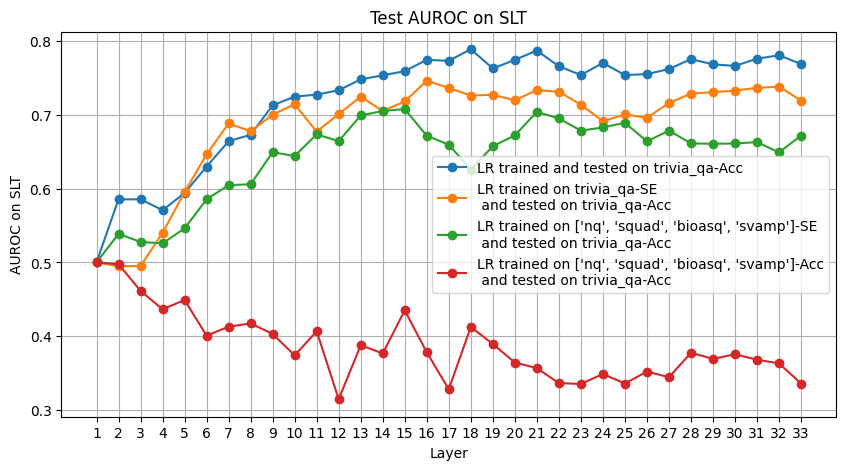

SLT: max AUROC for LR trained on trivia_qa's Acc and tested on trivia_qa's Acc:
	- 0.7886 at layer 18
	- 0.7868 at layer 21
	- 0.7804 at layer 32
	- 0.7758 at layer 31
	- 0.7751 at layer 28
SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's Acc:
	- 0.7459 at layer 16
	- 0.7379 at layer 32
	- 0.7363 at layer 31
	- 0.7361 at layer 17
	- 0.7332 at layer 21
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's Acc:
	- 0.7075 at layer 15
	- 0.7051 at layer 14
	- 0.7037 at layer 21
	- 0.6989 at layer 13
	- 0.6949 at layer 22
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on trivia_qa's Acc:
	- 0.5000 at layer 1
	- 0.4975 at layer 2
	- 0.4615 at layer 3
	- 0.4491 at layer 5
	- 0.4365 at layer 4


In [246]:
# Inspect dataset by dataset
test_n_on_one(D1)

Testing on nq's SE


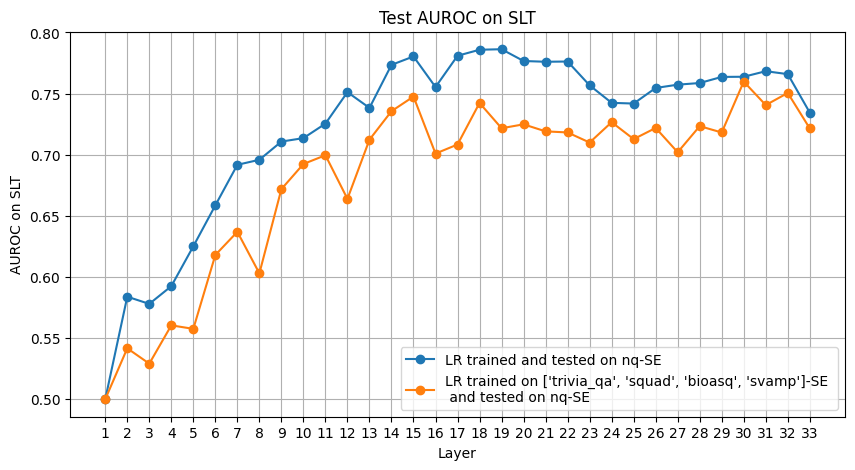

SLT: max AUROC for LR trained on nq's SE and tested on nq's SE:
	- 0.7863 at layer 19
	- 0.7859 at layer 18
	- 0.7810 at layer 17
	- 0.7804 at layer 15
	- 0.7767 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's SE:
	- 0.7598 at layer 30
	- 0.7505 at layer 32
	- 0.7476 at layer 15
	- 0.7424 at layer 18
	- 0.7406 at layer 31

Testing on nq's Acc


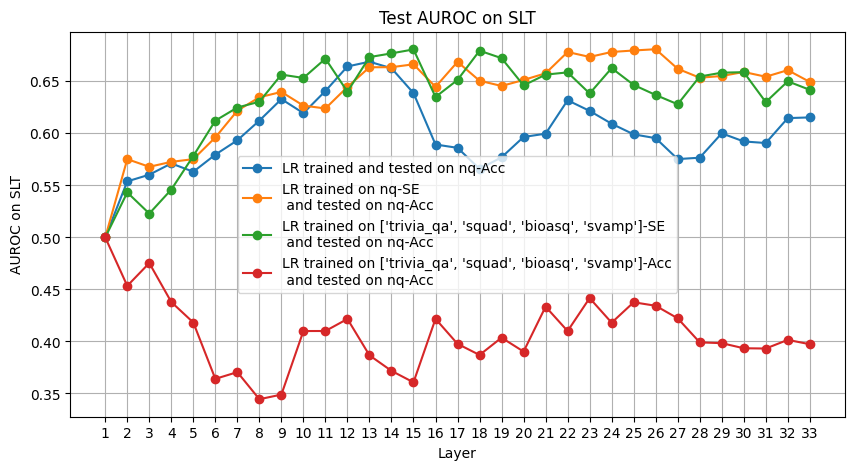

SLT: max AUROC for LR trained on nq's Acc and tested on nq's Acc:
	- 0.6689 at layer 13
	- 0.6643 at layer 12
	- 0.6626 at layer 14
	- 0.6408 at layer 11
	- 0.6387 at layer 15
SLT: max AUROC for LR trained on nq's SE and tested on nq's Acc:
	- 0.6809 at layer 26
	- 0.6797 at layer 25
	- 0.6783 at layer 24
	- 0.6782 at layer 22
	- 0.6735 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's Acc:
	- 0.6807 at layer 15
	- 0.6795 at layer 18
	- 0.6769 at layer 14
	- 0.6733 at layer 13
	- 0.6723 at layer 19
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on nq's Acc:
	- 0.5000 at layer 1
	- 0.4754 at layer 3
	- 0.4534 at layer 2
	- 0.4417 at layer 23
	- 0.4379 at layer 4


In [247]:
# Inspect dataset by dataset
test_n_on_one(D2)

Testing on bioasq's SE


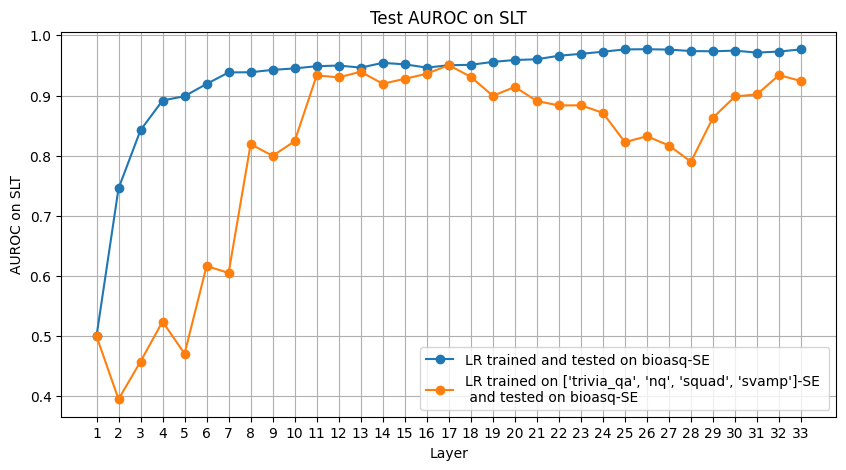

SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's SE:
	- 0.9769 at layer 26
	- 0.9766 at layer 25
	- 0.9766 at layer 33
	- 0.9763 at layer 27
	- 0.9746 at layer 30
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's SE:
	- 0.9505 at layer 17
	- 0.9395 at layer 13
	- 0.9361 at layer 16
	- 0.9340 at layer 32
	- 0.9334 at layer 11

Testing on bioasq's Acc


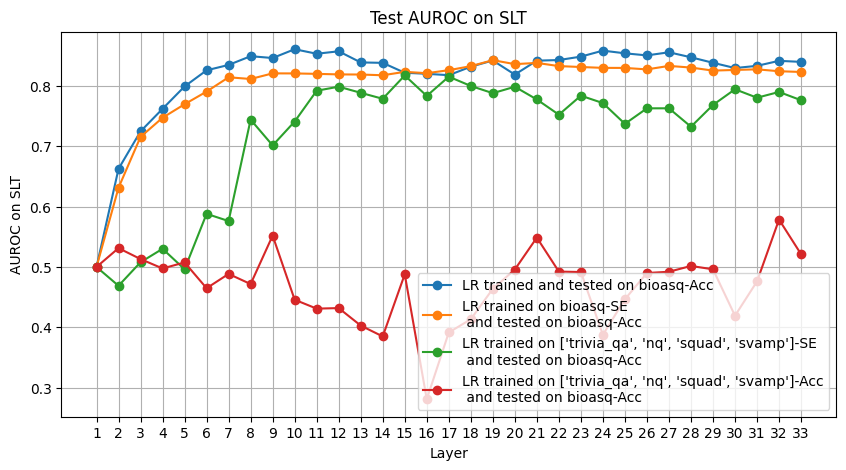

SLT: max AUROC for LR trained on bioasq's Acc and tested on bioasq's Acc:
	- 0.8606 at layer 10
	- 0.8583 at layer 24
	- 0.8572 at layer 12
	- 0.8556 at layer 27
	- 0.8538 at layer 25
SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's Acc:
	- 0.8425 at layer 19
	- 0.8379 at layer 21
	- 0.8359 at layer 20
	- 0.8330 at layer 27
	- 0.8327 at layer 22
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's Acc:
	- 0.8172 at layer 15
	- 0.8152 at layer 17
	- 0.7998 at layer 18
	- 0.7986 at layer 12
	- 0.7985 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on bioasq's Acc:
	- 0.5785 at layer 32
	- 0.5520 at layer 9
	- 0.5486 at layer 21
	- 0.5312 at layer 2
	- 0.5212 at layer 33


In [249]:
# Inspect dataset by dataset
test_n_on_one(D4)

Testing on squad's SE


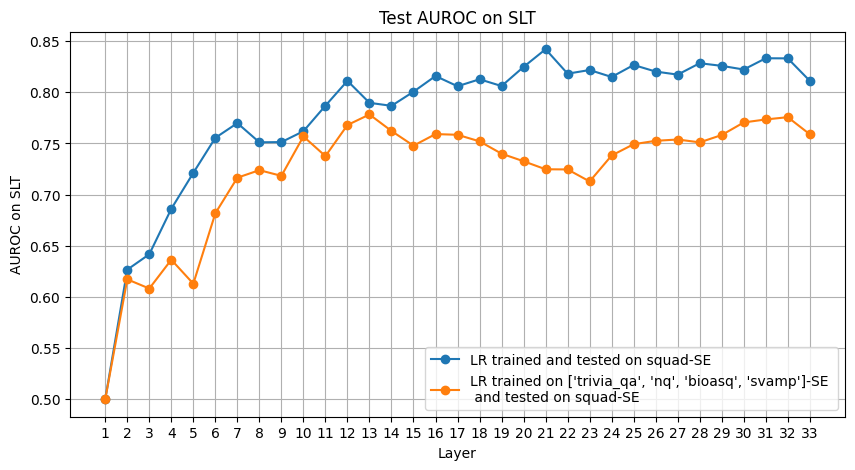

SLT: max AUROC for LR trained on squad's SE and tested on squad's SE:
	- 0.8421 at layer 21
	- 0.8332 at layer 31
	- 0.8331 at layer 32
	- 0.8284 at layer 28
	- 0.8266 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's SE:
	- 0.7783 at layer 13
	- 0.7756 at layer 32
	- 0.7734 at layer 31
	- 0.7705 at layer 30
	- 0.7680 at layer 12

Testing on squad's Acc


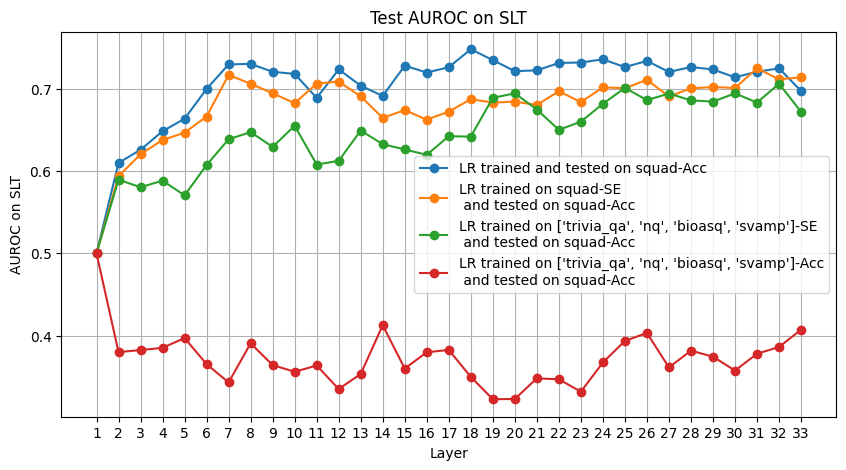

SLT: max AUROC for LR trained on squad's Acc and tested on squad's Acc:
	- 0.7479 at layer 18
	- 0.7356 at layer 24
	- 0.7347 at layer 19
	- 0.7337 at layer 26
	- 0.7318 at layer 23
SLT: max AUROC for LR trained on squad's SE and tested on squad's Acc:
	- 0.7248 at layer 31
	- 0.7167 at layer 7
	- 0.7138 at layer 33
	- 0.7113 at layer 32
	- 0.7108 at layer 26
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's Acc:
	- 0.7060 at layer 32
	- 0.7009 at layer 25
	- 0.6943 at layer 20
	- 0.6943 at layer 30
	- 0.6941 at layer 27
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on squad's Acc:
	- 0.5000 at layer 1
	- 0.4127 at layer 14
	- 0.4072 at layer 33
	- 0.4033 at layer 26
	- 0.3971 at layer 5


In [248]:
# Inspect dataset by dataset
test_n_on_one(D3)

Testing on svamp's SE


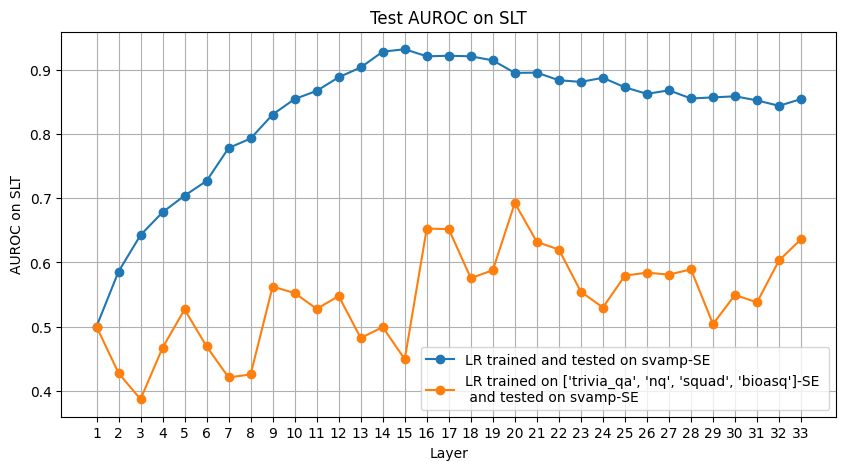

SLT: max AUROC for LR trained on svamp's SE and tested on svamp's SE:
	- 0.9325 at layer 15
	- 0.9287 at layer 14
	- 0.9223 at layer 17
	- 0.9215 at layer 16
	- 0.9215 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's SE:
	- 0.6927 at layer 20
	- 0.6528 at layer 16
	- 0.6520 at layer 17
	- 0.6362 at layer 33
	- 0.6320 at layer 21

Testing on svamp's Acc


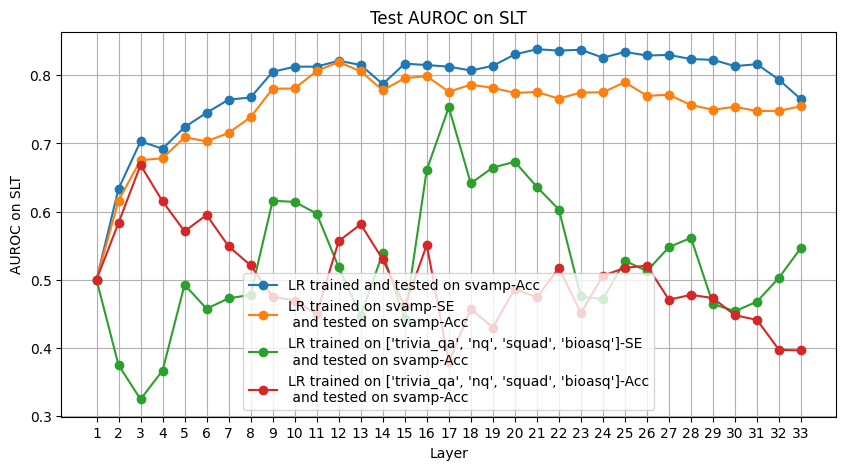

SLT: max AUROC for LR trained on svamp's Acc and tested on svamp's Acc:
	- 0.8383 at layer 21
	- 0.8375 at layer 23
	- 0.8363 at layer 22
	- 0.8343 at layer 25
	- 0.8307 at layer 20
SLT: max AUROC for LR trained on svamp's SE and tested on svamp's Acc:
	- 0.8195 at layer 12
	- 0.8063 at layer 11
	- 0.8059 at layer 13
	- 0.7987 at layer 16
	- 0.7959 at layer 15
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's Acc:
	- 0.7531 at layer 17
	- 0.6731 at layer 20
	- 0.6647 at layer 19
	- 0.6611 at layer 16
	- 0.6415 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on svamp's Acc:
	- 0.6683 at layer 3
	- 0.6150 at layer 4
	- 0.5950 at layer 6
	- 0.5834 at layer 2
	- 0.5814 at layer 13


In [250]:
# Inspect dataset by dataset
test_n_on_one(D5)

## Generalize probes trained with one dataset's SE to predicting another's SE/Acc
Train probes on one dataset's SE and test it to other dataset's Acc prediction.

In [268]:
# Train on one's SE and test on others' SE/Acc
def test_one_on_n(D):
    other_ids = D.other_ids
    other_names = D.other_names
    sb_models = D.sb_models
    
    print(f"Using probes trained on datasets {D.name.upper()}'s SLT-SE to predict {other_names}'s SLT-SE")
    
    sbo_accs = {}
    sbo_aucs = {}
    
    for id_ in D.other_ids:
        D_id = Ds[id_]
        print(f"Testing on {D_id.name.upper()}'s SLT-SE")
        _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D_id.slt_dataset, D_id.b_entropy, D_id.total_size)
        id_accs = []
        id_aucs = []
        for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
            model = sb_models[i]
            test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True, silent=True)
            id_accs.append(test_acc)
            id_aucs.append(test_auc)

        sbo_accs[D_id.name] = id_accs
        sbo_aucs[D_id.name] = id_aucs

        plot_metrics([D_id.sb_aucs, D_id.isb_aucs, id_aucs], [f'LR trained and tested on {D_id.name}-SE',
                                                              f'LR trained on {D_id.other_names}-SE,\n tested on {D_id.name}-SE',
                                                              f'LR trained on {D.name}-SE, tested on {D_id.name}-SE'], 
                     f'AUROC on SLT')
        best_metric([D_id.sb_aucs], token="SLT", train="SE", test="SE", ds=[[D_id.name]*2])
        best_metric([D_id.isb_aucs], token="SLT", train="SE", test="SE", ds=[[D_id.other_names, D_id.name]])
        best_metric([id_aucs], token="SLT", train="SE", test="SE", ds=[[D.name, D_id.name]])
        

    D.sbo_accs = sbo_accs
    D.sbo_aucs = sbo_aucs

    print(f"\n\nUsing probes trained on datasets {D.name.upper()}'s SLT-SE to predict {other_names}'s SLT-Acc")
    
    sao_accs = {}
    sao_aucs = {}
    
    for id_ in D.other_ids:
        D_id = Ds[id_]
        print(f"Testing on {D_id.name.upper()}'s SLT-Acc")
        _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D_id.slt_dataset, 1-D_id.accuracies, D_id.total_size)
        id_accs = []
        id_aucs = []
        for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
            model = sb_models[i]
            test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True, silent=True)
            id_accs.append(test_acc)
            id_aucs.append(test_auc)

        sao_accs[D_id.name] = id_accs
        sao_aucs[D_id.name] = id_aucs

        plot_metrics([D_id.sa_aucs, D_id.isab_aucs, id_aucs, D_id.isaa_aucs], [f'LR trained and tested on {D_id.name}-Acc',
                                                                               f'LR trained on {D_id.other_names}-SE,\n tested on {D_id.name}-Acc',
                                                                               f'LR trained on {D.name}-SE,\n tested on {D_id.name}-Acc',
                                                                                f'LR trained on {D_id.other_names}-Acc,\n tested on {D_id.name}-Acc'], 
                     f'AUROC on SLT')

        best_metric([D_id.sa_aucs], token="SLT", train="Acc", test="Acc", ds=[[D_id.name]*2])
        best_metric([D_id.isab_aucs], token="SLT", train="SE", test="Acc", ds=[[D_id.other_names, D_id.name]])
        best_metric([id_aucs], token="SLT", train="SE", test="Acc", ds=[[D.name, D_id.name]])
        best_metric([D_id.isaa_aucs], token="SLT", train="Acc", test="Acc", ds=[[D_id.other_names, D_id.name]])
    
    D.sao_accs = sao_accs
    D.sao_aucs = sao_aucs


Using probes trained on datasets TRIVIA_QA's SLT-SE to predict ['nq', 'squad', 'bioasq', 'svamp']'s SLT-SE
Testing on NQ's SLT-SE


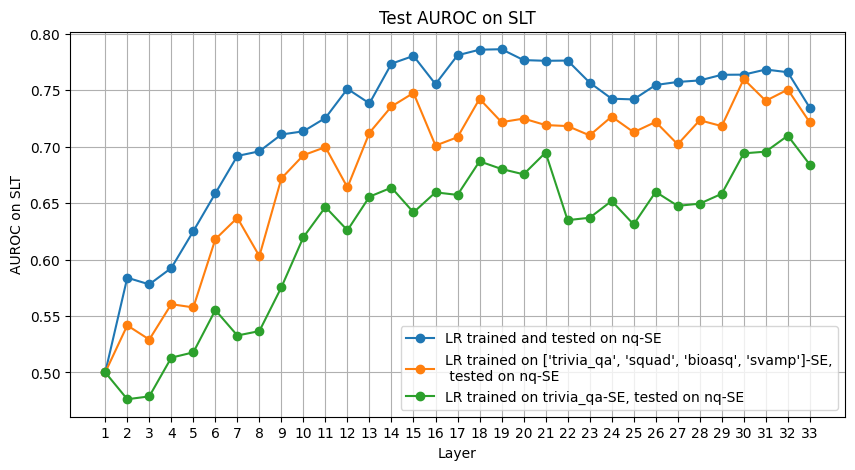

SLT: max AUROC for LR trained on nq's SE and tested on nq's SE:
	- 0.7863 at layer 19
	- 0.7859 at layer 18
	- 0.7810 at layer 17
	- 0.7804 at layer 15
	- 0.7767 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's SE:
	- 0.7598 at layer 30
	- 0.7505 at layer 32
	- 0.7476 at layer 15
	- 0.7424 at layer 18
	- 0.7406 at layer 31
SLT: max AUROC for LR trained on trivia_qa's SE and tested on nq's SE:
	- 0.7097 at layer 32
	- 0.6956 at layer 31
	- 0.6948 at layer 21
	- 0.6941 at layer 30
	- 0.6870 at layer 18
Testing on SQUAD's SLT-SE


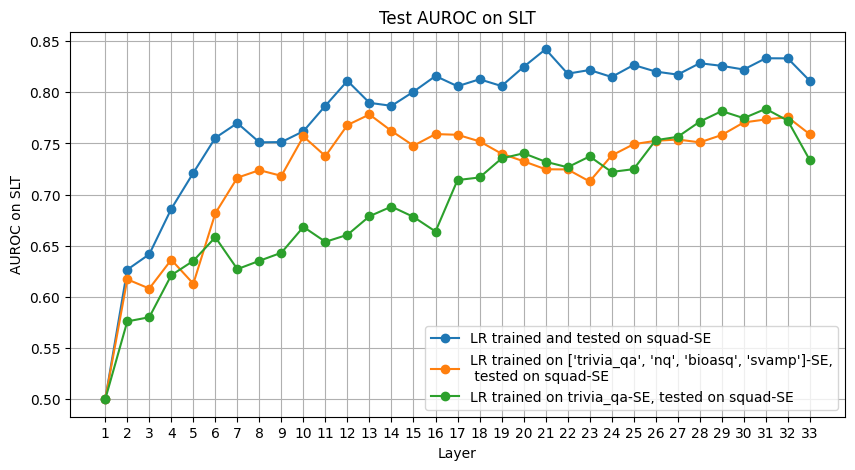

SLT: max AUROC for LR trained on squad's SE and tested on squad's SE:
	- 0.8421 at layer 21
	- 0.8332 at layer 31
	- 0.8331 at layer 32
	- 0.8284 at layer 28
	- 0.8266 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's SE:
	- 0.7783 at layer 13
	- 0.7756 at layer 32
	- 0.7734 at layer 31
	- 0.7705 at layer 30
	- 0.7680 at layer 12
SLT: max AUROC for LR trained on trivia_qa's SE and tested on squad's SE:
	- 0.7838 at layer 31
	- 0.7816 at layer 29
	- 0.7747 at layer 30
	- 0.7722 at layer 32
	- 0.7712 at layer 28
Testing on BIOASQ's SLT-SE


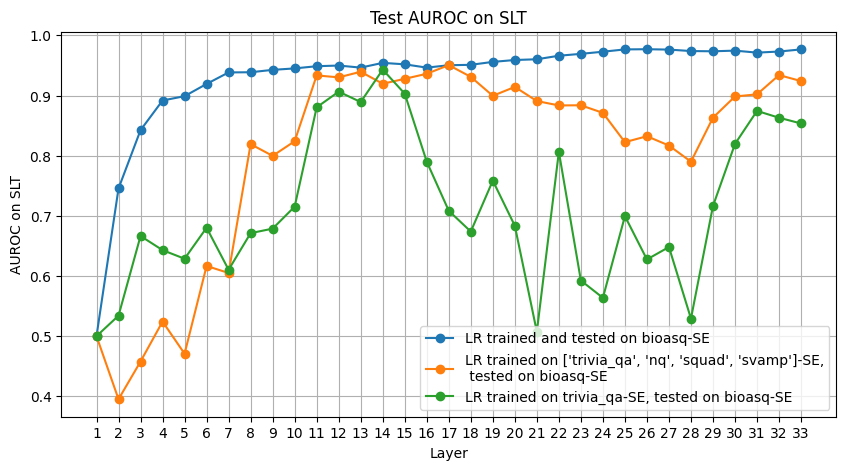

SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's SE:
	- 0.9769 at layer 26
	- 0.9766 at layer 25
	- 0.9766 at layer 33
	- 0.9763 at layer 27
	- 0.9746 at layer 30
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's SE:
	- 0.9505 at layer 17
	- 0.9395 at layer 13
	- 0.9361 at layer 16
	- 0.9340 at layer 32
	- 0.9334 at layer 11
SLT: max AUROC for LR trained on trivia_qa's SE and tested on bioasq's SE:
	- 0.9430 at layer 14
	- 0.9064 at layer 12
	- 0.9030 at layer 15
	- 0.8892 at layer 13
	- 0.8804 at layer 11
Testing on SVAMP's SLT-SE


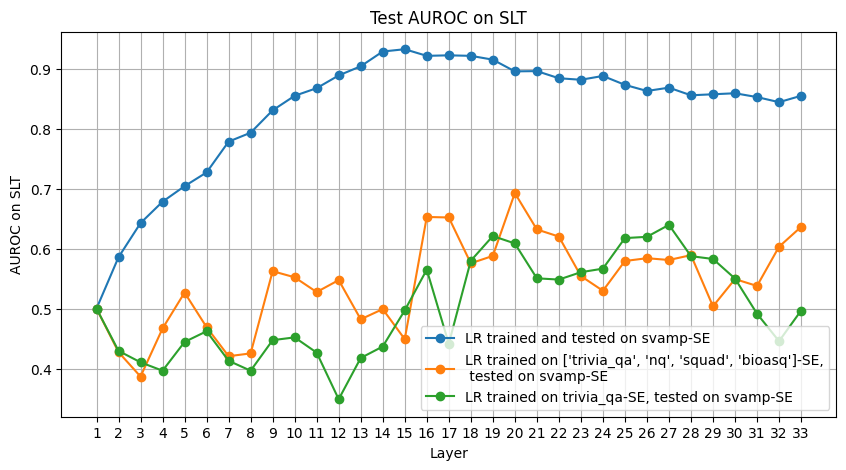

SLT: max AUROC for LR trained on svamp's SE and tested on svamp's SE:
	- 0.9325 at layer 15
	- 0.9287 at layer 14
	- 0.9223 at layer 17
	- 0.9215 at layer 16
	- 0.9215 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's SE:
	- 0.6927 at layer 20
	- 0.6528 at layer 16
	- 0.6520 at layer 17
	- 0.6362 at layer 33
	- 0.6320 at layer 21
SLT: max AUROC for LR trained on trivia_qa's SE and tested on svamp's SE:
	- 0.6396 at layer 27
	- 0.6210 at layer 19
	- 0.6197 at layer 26
	- 0.6176 at layer 25
	- 0.6087 at layer 20


Using probes trained on datasets TRIVIA_QA's SLT-SE to predict ['nq', 'squad', 'bioasq', 'svamp']'s SLT-Acc
Testing on NQ's SLT-Acc


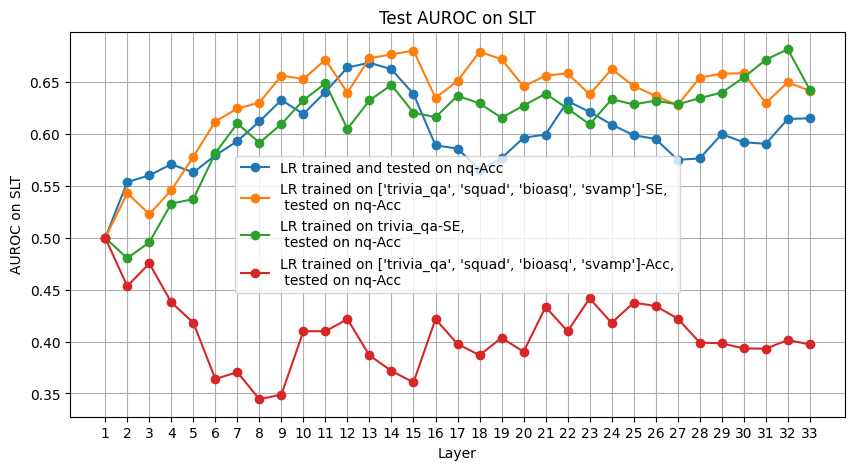

SLT: max AUROC for LR trained on nq's Acc and tested on nq's Acc:
	- 0.6689 at layer 13
	- 0.6643 at layer 12
	- 0.6626 at layer 14
	- 0.6408 at layer 11
	- 0.6387 at layer 15
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's Acc:
	- 0.6807 at layer 15
	- 0.6795 at layer 18
	- 0.6769 at layer 14
	- 0.6733 at layer 13
	- 0.6723 at layer 19
SLT: max AUROC for LR trained on trivia_qa's SE and tested on nq's Acc:
	- 0.6820 at layer 32
	- 0.6718 at layer 31
	- 0.6547 at layer 30
	- 0.6491 at layer 11
	- 0.6474 at layer 14
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on nq's Acc:
	- 0.5000 at layer 1
	- 0.4754 at layer 3
	- 0.4534 at layer 2
	- 0.4417 at layer 23
	- 0.4379 at layer 4
Testing on SQUAD's SLT-Acc


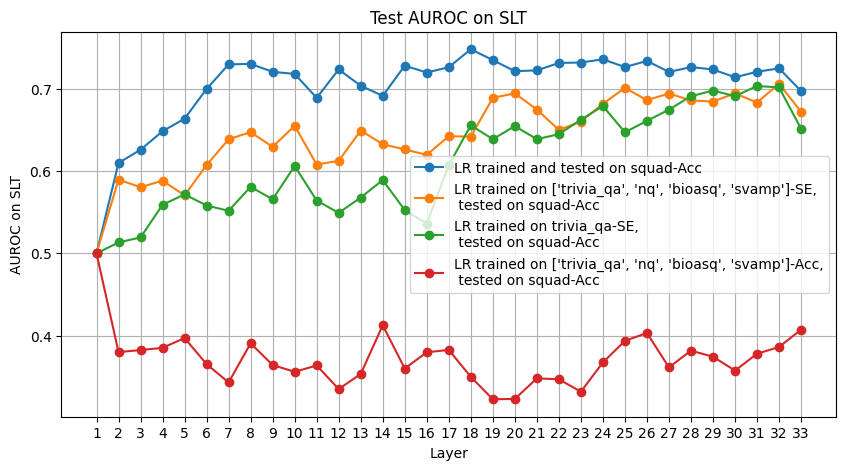

SLT: max AUROC for LR trained on squad's Acc and tested on squad's Acc:
	- 0.7479 at layer 18
	- 0.7356 at layer 24
	- 0.7347 at layer 19
	- 0.7337 at layer 26
	- 0.7318 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's Acc:
	- 0.7060 at layer 32
	- 0.7009 at layer 25
	- 0.6943 at layer 20
	- 0.6943 at layer 30
	- 0.6941 at layer 27
SLT: max AUROC for LR trained on trivia_qa's SE and tested on squad's Acc:
	- 0.7032 at layer 31
	- 0.7015 at layer 32
	- 0.6977 at layer 29
	- 0.6909 at layer 30
	- 0.6908 at layer 28
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on squad's Acc:
	- 0.5000 at layer 1
	- 0.4127 at layer 14
	- 0.4072 at layer 33
	- 0.4033 at layer 26
	- 0.3971 at layer 5
Testing on BIOASQ's SLT-Acc


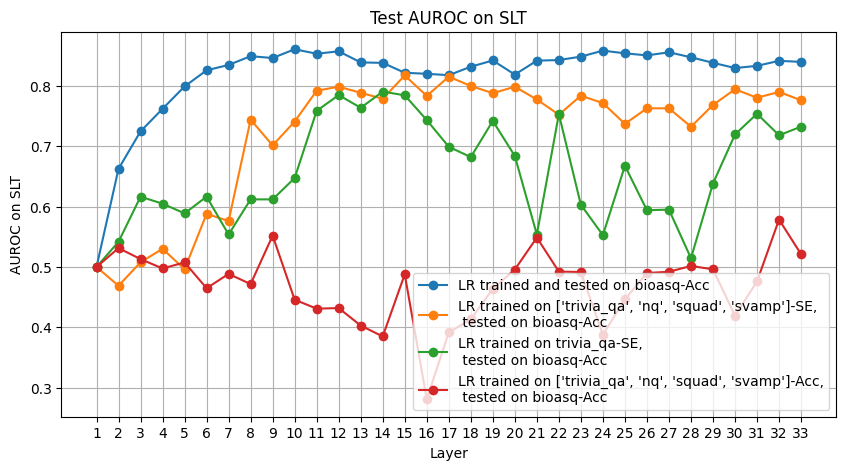

SLT: max AUROC for LR trained on bioasq's Acc and tested on bioasq's Acc:
	- 0.8606 at layer 10
	- 0.8583 at layer 24
	- 0.8572 at layer 12
	- 0.8556 at layer 27
	- 0.8538 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's Acc:
	- 0.8172 at layer 15
	- 0.8152 at layer 17
	- 0.7998 at layer 18
	- 0.7986 at layer 12
	- 0.7985 at layer 20
SLT: max AUROC for LR trained on trivia_qa's SE and tested on bioasq's Acc:
	- 0.7904 at layer 14
	- 0.7847 at layer 12
	- 0.7843 at layer 15
	- 0.7636 at layer 13
	- 0.7586 at layer 11
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on bioasq's Acc:
	- 0.5785 at layer 32
	- 0.5520 at layer 9
	- 0.5486 at layer 21
	- 0.5312 at layer 2
	- 0.5212 at layer 33
Testing on SVAMP's SLT-Acc


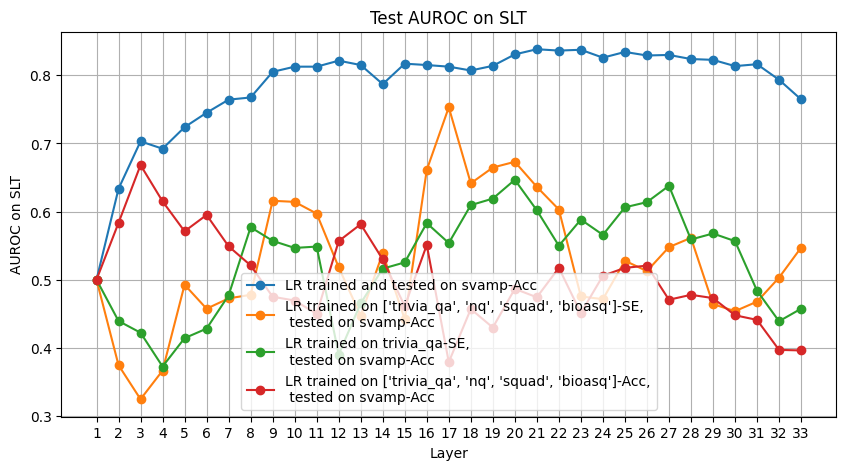

SLT: max AUROC for LR trained on svamp's Acc and tested on svamp's Acc:
	- 0.8383 at layer 21
	- 0.8375 at layer 23
	- 0.8363 at layer 22
	- 0.8343 at layer 25
	- 0.8307 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's Acc:
	- 0.7531 at layer 17
	- 0.6731 at layer 20
	- 0.6647 at layer 19
	- 0.6611 at layer 16
	- 0.6415 at layer 18
SLT: max AUROC for LR trained on trivia_qa's SE and tested on svamp's Acc:
	- 0.6467 at layer 20
	- 0.6379 at layer 27
	- 0.6190 at layer 19
	- 0.6138 at layer 26
	- 0.6094 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on svamp's Acc:
	- 0.6683 at layer 3
	- 0.6150 at layer 4
	- 0.5950 at layer 6
	- 0.5834 at layer 2
	- 0.5814 at layer 13


In [266]:
test_one_on_n(D1)

Using probes trained on datasets NQ's SLT-SE to predict ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SLT-SE
Testing on TRIVIA_QA's SLT-SE


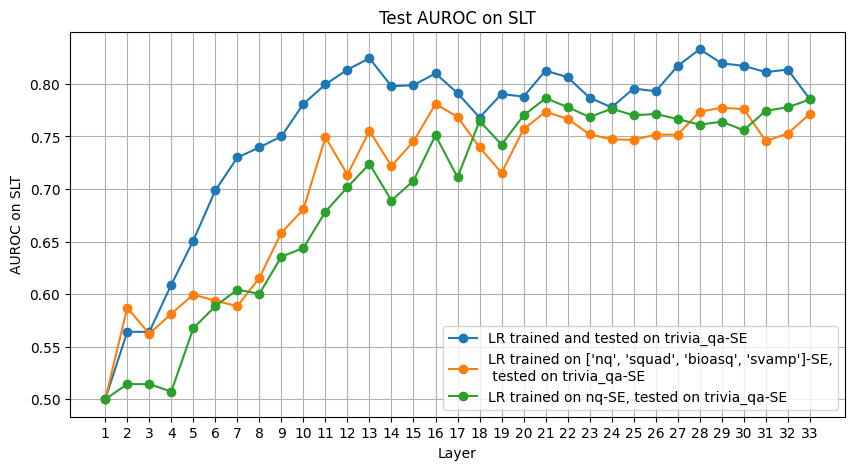

SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's SE:
	- 0.8330 at layer 28
	- 0.8245 at layer 13
	- 0.8196 at layer 29
	- 0.8172 at layer 30
	- 0.8171 at layer 27
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's SE:
	- 0.7809 at layer 16
	- 0.7773 at layer 29
	- 0.7760 at layer 30
	- 0.7736 at layer 28
	- 0.7734 at layer 21
SLT: max AUROC for LR trained on nq's SE and tested on trivia_qa's SE:
	- 0.7864 at layer 21
	- 0.7852 at layer 33
	- 0.7780 at layer 22
	- 0.7778 at layer 32
	- 0.7765 at layer 24
Testing on SQUAD's SLT-SE


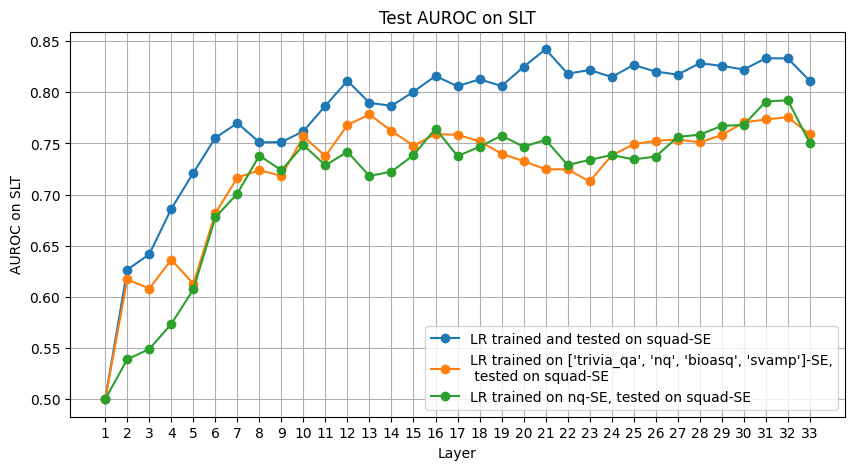

SLT: max AUROC for LR trained on squad's SE and tested on squad's SE:
	- 0.8421 at layer 21
	- 0.8332 at layer 31
	- 0.8331 at layer 32
	- 0.8284 at layer 28
	- 0.8266 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's SE:
	- 0.7783 at layer 13
	- 0.7756 at layer 32
	- 0.7734 at layer 31
	- 0.7705 at layer 30
	- 0.7680 at layer 12
SLT: max AUROC for LR trained on nq's SE and tested on squad's SE:
	- 0.7922 at layer 32
	- 0.7909 at layer 31
	- 0.7681 at layer 30
	- 0.7671 at layer 29
	- 0.7645 at layer 16
Testing on BIOASQ's SLT-SE


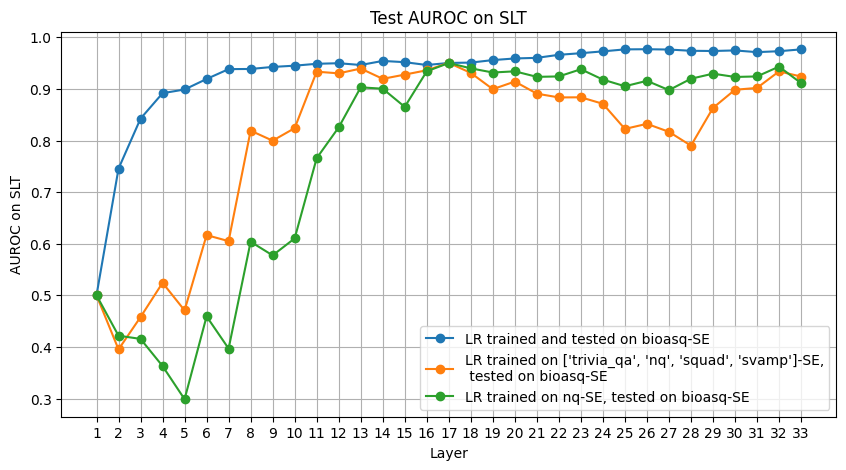

SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's SE:
	- 0.9769 at layer 26
	- 0.9766 at layer 25
	- 0.9766 at layer 33
	- 0.9763 at layer 27
	- 0.9746 at layer 30
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's SE:
	- 0.9505 at layer 17
	- 0.9395 at layer 13
	- 0.9361 at layer 16
	- 0.9340 at layer 32
	- 0.9334 at layer 11
SLT: max AUROC for LR trained on nq's SE and tested on bioasq's SE:
	- 0.9502 at layer 17
	- 0.9432 at layer 32
	- 0.9399 at layer 18
	- 0.9382 at layer 23
	- 0.9341 at layer 16
Testing on SVAMP's SLT-SE


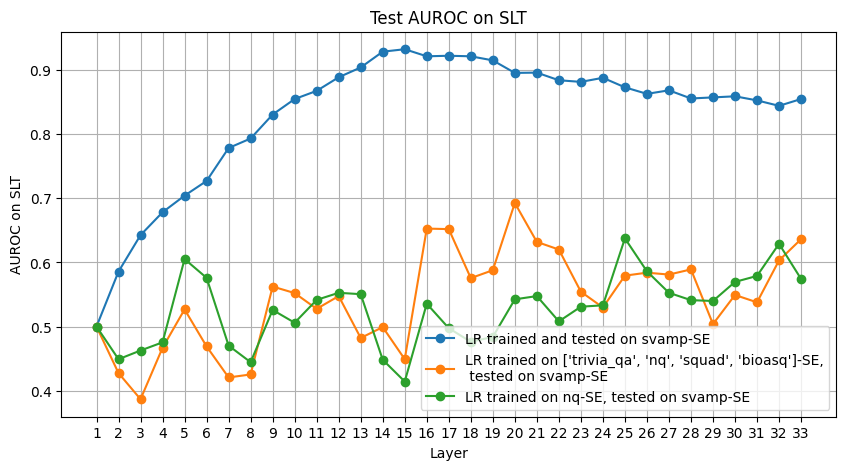

SLT: max AUROC for LR trained on svamp's SE and tested on svamp's SE:
	- 0.9325 at layer 15
	- 0.9287 at layer 14
	- 0.9223 at layer 17
	- 0.9215 at layer 16
	- 0.9215 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's SE:
	- 0.6927 at layer 20
	- 0.6528 at layer 16
	- 0.6520 at layer 17
	- 0.6362 at layer 33
	- 0.6320 at layer 21
SLT: max AUROC for LR trained on nq's SE and tested on svamp's SE:
	- 0.6375 at layer 25
	- 0.6290 at layer 32
	- 0.6053 at layer 5
	- 0.5862 at layer 26
	- 0.5789 at layer 31


Using probes trained on datasets NQ's SLT-SE to predict ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SLT-Acc
Testing on TRIVIA_QA's SLT-Acc


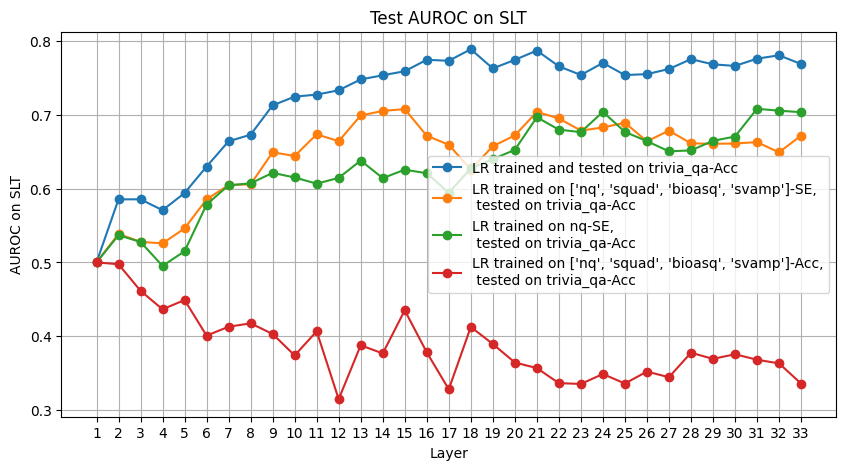

SLT: max AUROC for LR trained on trivia_qa's Acc and tested on trivia_qa's Acc:
	- 0.7886 at layer 18
	- 0.7868 at layer 21
	- 0.7804 at layer 32
	- 0.7758 at layer 31
	- 0.7751 at layer 28
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's Acc:
	- 0.7075 at layer 15
	- 0.7051 at layer 14
	- 0.7037 at layer 21
	- 0.6989 at layer 13
	- 0.6949 at layer 22
SLT: max AUROC for LR trained on nq's SE and tested on trivia_qa's Acc:
	- 0.7079 at layer 31
	- 0.7054 at layer 32
	- 0.7038 at layer 24
	- 0.7034 at layer 33
	- 0.6965 at layer 21
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on trivia_qa's Acc:
	- 0.5000 at layer 1
	- 0.4975 at layer 2
	- 0.4615 at layer 3
	- 0.4491 at layer 5
	- 0.4365 at layer 4
Testing on SQUAD's SLT-Acc


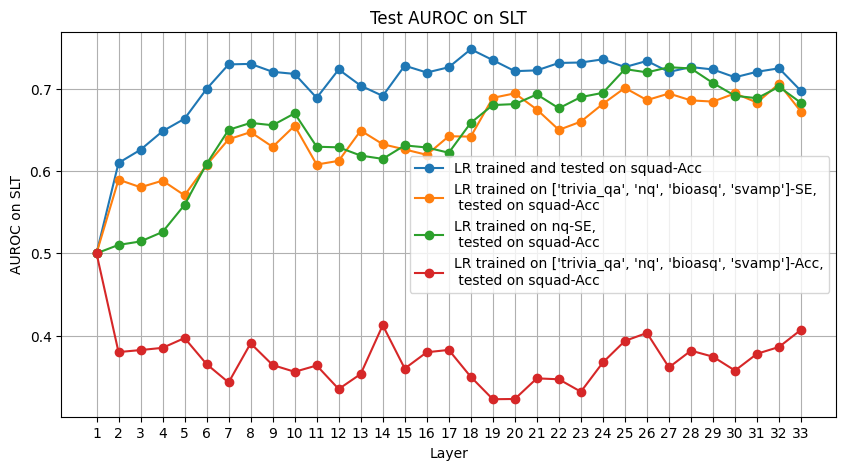

SLT: max AUROC for LR trained on squad's Acc and tested on squad's Acc:
	- 0.7479 at layer 18
	- 0.7356 at layer 24
	- 0.7347 at layer 19
	- 0.7337 at layer 26
	- 0.7318 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's Acc:
	- 0.7060 at layer 32
	- 0.7009 at layer 25
	- 0.6943 at layer 20
	- 0.6943 at layer 30
	- 0.6941 at layer 27
SLT: max AUROC for LR trained on nq's SE and tested on squad's Acc:
	- 0.7261 at layer 27
	- 0.7245 at layer 28
	- 0.7238 at layer 25
	- 0.7198 at layer 26
	- 0.7068 at layer 29
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on squad's Acc:
	- 0.5000 at layer 1
	- 0.4127 at layer 14
	- 0.4072 at layer 33
	- 0.4033 at layer 26
	- 0.3971 at layer 5
Testing on BIOASQ's SLT-Acc


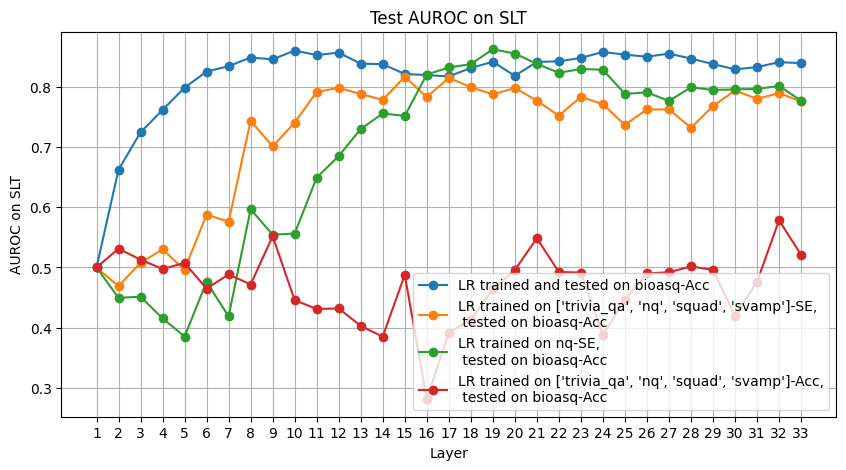

SLT: max AUROC for LR trained on bioasq's Acc and tested on bioasq's Acc:
	- 0.8606 at layer 10
	- 0.8583 at layer 24
	- 0.8572 at layer 12
	- 0.8556 at layer 27
	- 0.8538 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's Acc:
	- 0.8172 at layer 15
	- 0.8152 at layer 17
	- 0.7998 at layer 18
	- 0.7986 at layer 12
	- 0.7985 at layer 20
SLT: max AUROC for LR trained on nq's SE and tested on bioasq's Acc:
	- 0.8628 at layer 19
	- 0.8557 at layer 20
	- 0.8385 at layer 21
	- 0.8379 at layer 18
	- 0.8326 at layer 17
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on bioasq's Acc:
	- 0.5785 at layer 32
	- 0.5520 at layer 9
	- 0.5486 at layer 21
	- 0.5312 at layer 2
	- 0.5212 at layer 33
Testing on SVAMP's SLT-Acc


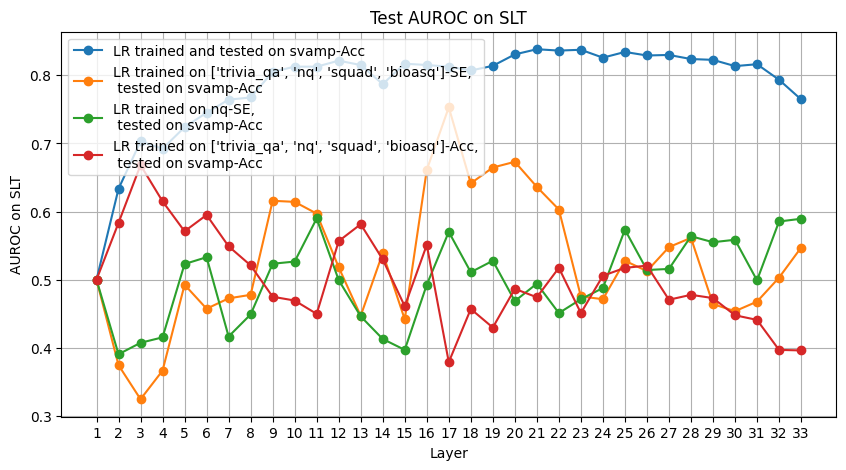

SLT: max AUROC for LR trained on svamp's Acc and tested on svamp's Acc:
	- 0.8383 at layer 21
	- 0.8375 at layer 23
	- 0.8363 at layer 22
	- 0.8343 at layer 25
	- 0.8307 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's Acc:
	- 0.7531 at layer 17
	- 0.6731 at layer 20
	- 0.6647 at layer 19
	- 0.6611 at layer 16
	- 0.6415 at layer 18
SLT: max AUROC for LR trained on nq's SE and tested on svamp's Acc:
	- 0.5898 at layer 11
	- 0.5894 at layer 33
	- 0.5854 at layer 32
	- 0.5734 at layer 25
	- 0.5702 at layer 17
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on svamp's Acc:
	- 0.6683 at layer 3
	- 0.6150 at layer 4
	- 0.5950 at layer 6
	- 0.5834 at layer 2
	- 0.5814 at layer 13


In [269]:
test_one_on_n(D2)

Using probes trained on datasets SQUAD's SLT-SE to predict ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SLT-SE
Testing on TRIVIA_QA's SLT-SE


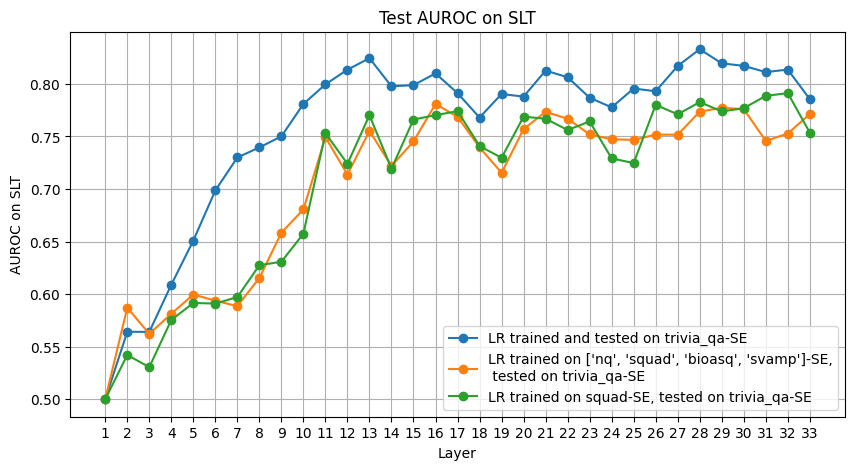

SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's SE:
	- 0.8330 at layer 28
	- 0.8245 at layer 13
	- 0.8196 at layer 29
	- 0.8172 at layer 30
	- 0.8171 at layer 27
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's SE:
	- 0.7809 at layer 16
	- 0.7773 at layer 29
	- 0.7760 at layer 30
	- 0.7736 at layer 28
	- 0.7734 at layer 21
SLT: max AUROC for LR trained on squad's SE and tested on trivia_qa's SE:
	- 0.7912 at layer 32
	- 0.7886 at layer 31
	- 0.7827 at layer 28
	- 0.7801 at layer 26
	- 0.7769 at layer 30
Testing on NQ's SLT-SE


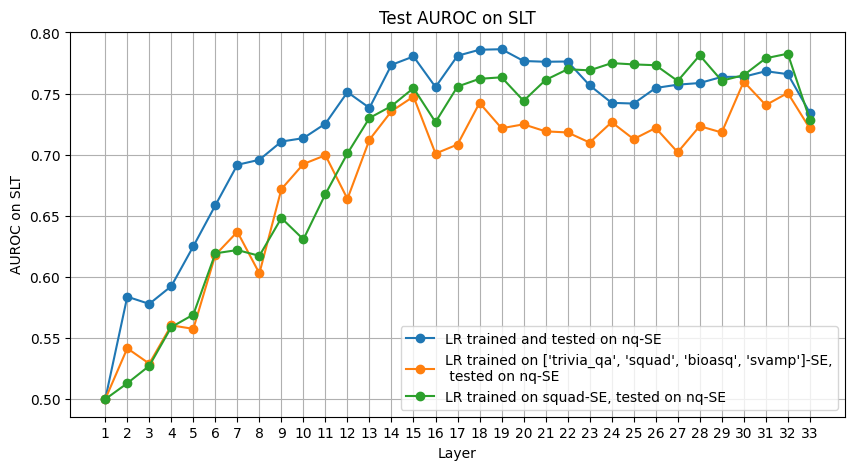

SLT: max AUROC for LR trained on nq's SE and tested on nq's SE:
	- 0.7863 at layer 19
	- 0.7859 at layer 18
	- 0.7810 at layer 17
	- 0.7804 at layer 15
	- 0.7767 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's SE:
	- 0.7598 at layer 30
	- 0.7505 at layer 32
	- 0.7476 at layer 15
	- 0.7424 at layer 18
	- 0.7406 at layer 31
SLT: max AUROC for LR trained on squad's SE and tested on nq's SE:
	- 0.7827 at layer 32
	- 0.7813 at layer 28
	- 0.7789 at layer 31
	- 0.7749 at layer 24
	- 0.7739 at layer 25
Testing on BIOASQ's SLT-SE


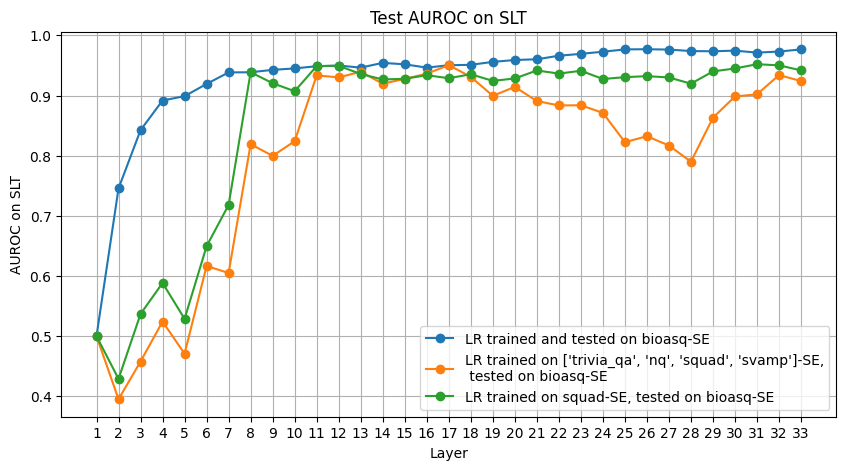

SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's SE:
	- 0.9769 at layer 26
	- 0.9766 at layer 25
	- 0.9766 at layer 33
	- 0.9763 at layer 27
	- 0.9746 at layer 30
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's SE:
	- 0.9505 at layer 17
	- 0.9395 at layer 13
	- 0.9361 at layer 16
	- 0.9340 at layer 32
	- 0.9334 at layer 11
SLT: max AUROC for LR trained on squad's SE and tested on bioasq's SE:
	- 0.9520 at layer 31
	- 0.9501 at layer 32
	- 0.9493 at layer 12
	- 0.9489 at layer 11
	- 0.9449 at layer 30
Testing on SVAMP's SLT-SE


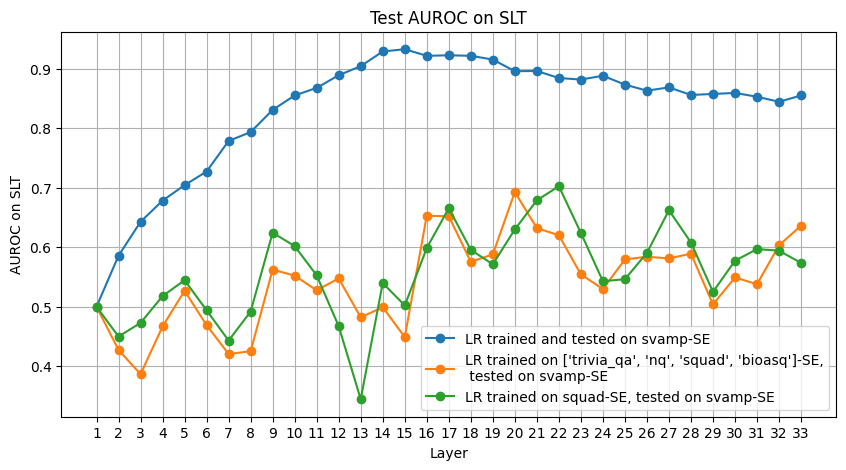

SLT: max AUROC for LR trained on svamp's SE and tested on svamp's SE:
	- 0.9325 at layer 15
	- 0.9287 at layer 14
	- 0.9223 at layer 17
	- 0.9215 at layer 16
	- 0.9215 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's SE:
	- 0.6927 at layer 20
	- 0.6528 at layer 16
	- 0.6520 at layer 17
	- 0.6362 at layer 33
	- 0.6320 at layer 21
SLT: max AUROC for LR trained on squad's SE and tested on svamp's SE:
	- 0.7025 at layer 22
	- 0.6787 at layer 21
	- 0.6655 at layer 17
	- 0.6621 at layer 27
	- 0.6299 at layer 20


Using probes trained on datasets SQUAD's SLT-SE to predict ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SLT-Acc
Testing on TRIVIA_QA's SLT-Acc


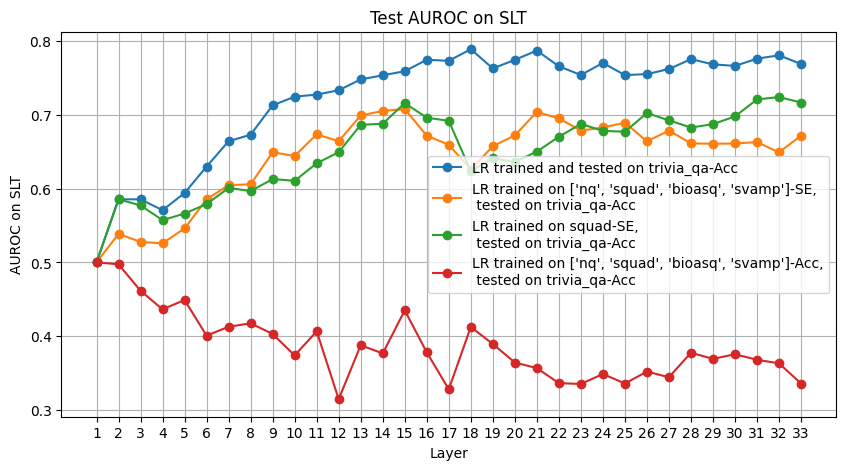

SLT: max AUROC for LR trained on trivia_qa's Acc and tested on trivia_qa's Acc:
	- 0.7886 at layer 18
	- 0.7868 at layer 21
	- 0.7804 at layer 32
	- 0.7758 at layer 31
	- 0.7751 at layer 28
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's Acc:
	- 0.7075 at layer 15
	- 0.7051 at layer 14
	- 0.7037 at layer 21
	- 0.6989 at layer 13
	- 0.6949 at layer 22
SLT: max AUROC for LR trained on squad's SE and tested on trivia_qa's Acc:
	- 0.7238 at layer 32
	- 0.7206 at layer 31
	- 0.7164 at layer 33
	- 0.7156 at layer 15
	- 0.7022 at layer 26
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on trivia_qa's Acc:
	- 0.5000 at layer 1
	- 0.4975 at layer 2
	- 0.4615 at layer 3
	- 0.4491 at layer 5
	- 0.4365 at layer 4
Testing on NQ's SLT-Acc


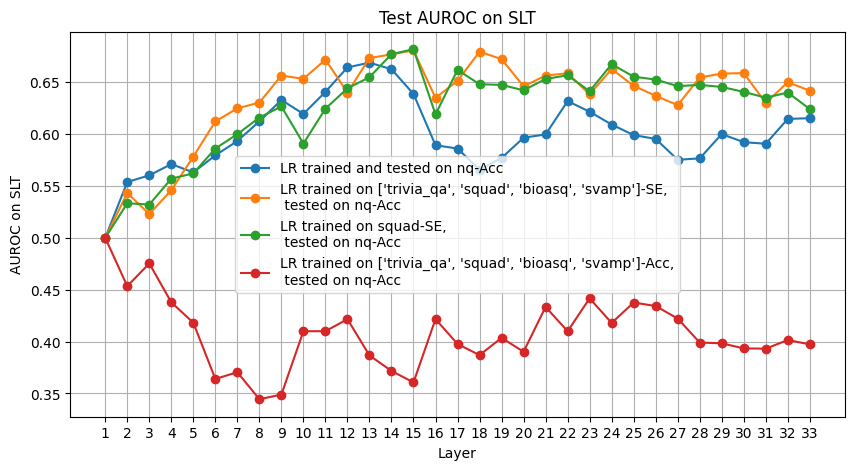

SLT: max AUROC for LR trained on nq's Acc and tested on nq's Acc:
	- 0.6689 at layer 13
	- 0.6643 at layer 12
	- 0.6626 at layer 14
	- 0.6408 at layer 11
	- 0.6387 at layer 15
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's Acc:
	- 0.6807 at layer 15
	- 0.6795 at layer 18
	- 0.6769 at layer 14
	- 0.6733 at layer 13
	- 0.6723 at layer 19
SLT: max AUROC for LR trained on squad's SE and tested on nq's Acc:
	- 0.6819 at layer 15
	- 0.6771 at layer 14
	- 0.6674 at layer 24
	- 0.6619 at layer 17
	- 0.6567 at layer 22
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on nq's Acc:
	- 0.5000 at layer 1
	- 0.4754 at layer 3
	- 0.4534 at layer 2
	- 0.4417 at layer 23
	- 0.4379 at layer 4
Testing on BIOASQ's SLT-Acc


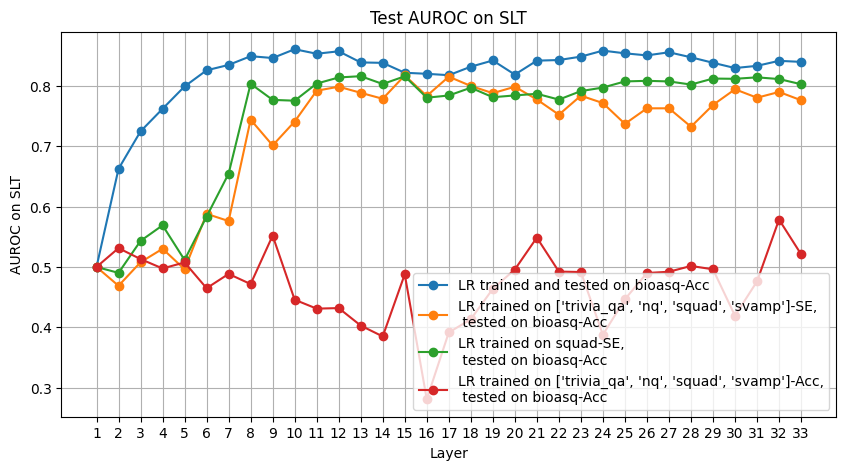

SLT: max AUROC for LR trained on bioasq's Acc and tested on bioasq's Acc:
	- 0.8606 at layer 10
	- 0.8583 at layer 24
	- 0.8572 at layer 12
	- 0.8556 at layer 27
	- 0.8538 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's Acc:
	- 0.8172 at layer 15
	- 0.8152 at layer 17
	- 0.7998 at layer 18
	- 0.7986 at layer 12
	- 0.7985 at layer 20
SLT: max AUROC for LR trained on squad's SE and tested on bioasq's Acc:
	- 0.8160 at layer 13
	- 0.8158 at layer 15
	- 0.8141 at layer 31
	- 0.8138 at layer 12
	- 0.8120 at layer 29
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on bioasq's Acc:
	- 0.5785 at layer 32
	- 0.5520 at layer 9
	- 0.5486 at layer 21
	- 0.5312 at layer 2
	- 0.5212 at layer 33
Testing on SVAMP's SLT-Acc


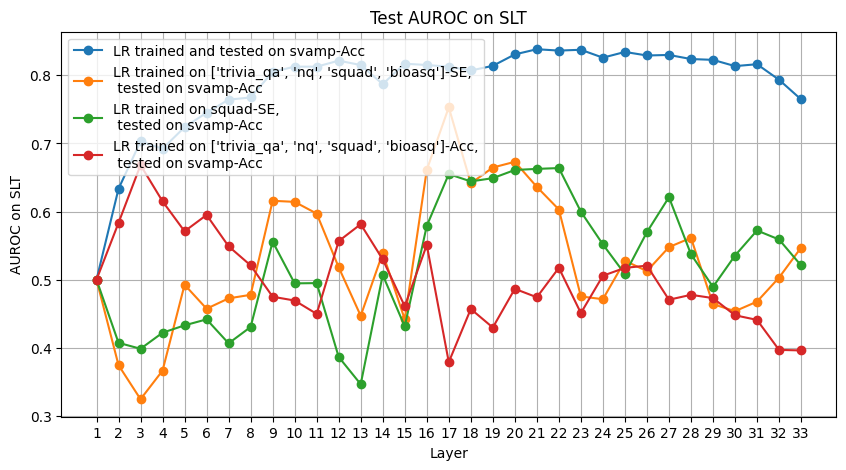

SLT: max AUROC for LR trained on svamp's Acc and tested on svamp's Acc:
	- 0.8383 at layer 21
	- 0.8375 at layer 23
	- 0.8363 at layer 22
	- 0.8343 at layer 25
	- 0.8307 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's Acc:
	- 0.7531 at layer 17
	- 0.6731 at layer 20
	- 0.6647 at layer 19
	- 0.6611 at layer 16
	- 0.6415 at layer 18
SLT: max AUROC for LR trained on squad's SE and tested on svamp's Acc:
	- 0.6639 at layer 22
	- 0.6627 at layer 21
	- 0.6611 at layer 20
	- 0.6551 at layer 17
	- 0.6491 at layer 19
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on svamp's Acc:
	- 0.6683 at layer 3
	- 0.6150 at layer 4
	- 0.5950 at layer 6
	- 0.5834 at layer 2
	- 0.5814 at layer 13


In [270]:
test_one_on_n(D3)

Using probes trained on datasets BIOASQ's SLT-SE to predict ['trivia_qa', 'nq', 'squad', 'svamp']'s SLT-SE
Testing on TRIVIA_QA's SLT-SE


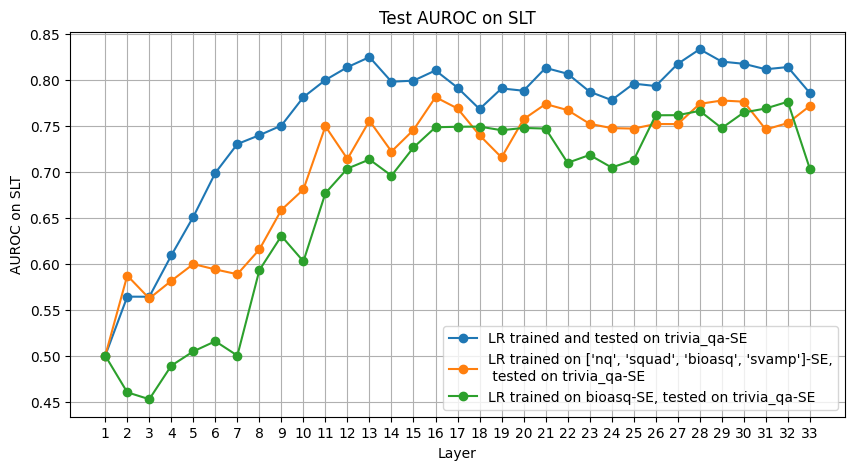

SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's SE:
	- 0.8330 at layer 28
	- 0.8245 at layer 13
	- 0.8196 at layer 29
	- 0.8172 at layer 30
	- 0.8171 at layer 27
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's SE:
	- 0.7809 at layer 16
	- 0.7773 at layer 29
	- 0.7760 at layer 30
	- 0.7736 at layer 28
	- 0.7734 at layer 21
SLT: max AUROC for LR trained on bioasq's SE and tested on trivia_qa's SE:
	- 0.7759 at layer 32
	- 0.7686 at layer 31
	- 0.7660 at layer 28
	- 0.7643 at layer 30
	- 0.7614 at layer 27
Testing on NQ's SLT-SE


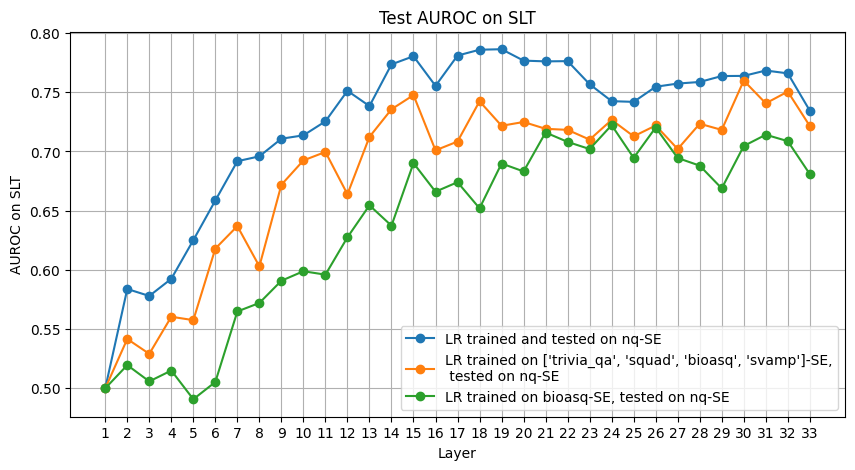

SLT: max AUROC for LR trained on nq's SE and tested on nq's SE:
	- 0.7863 at layer 19
	- 0.7859 at layer 18
	- 0.7810 at layer 17
	- 0.7804 at layer 15
	- 0.7767 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's SE:
	- 0.7598 at layer 30
	- 0.7505 at layer 32
	- 0.7476 at layer 15
	- 0.7424 at layer 18
	- 0.7406 at layer 31
SLT: max AUROC for LR trained on bioasq's SE and tested on nq's SE:
	- 0.7222 at layer 24
	- 0.7202 at layer 26
	- 0.7160 at layer 21
	- 0.7141 at layer 31
	- 0.7087 at layer 32
Testing on SQUAD's SLT-SE


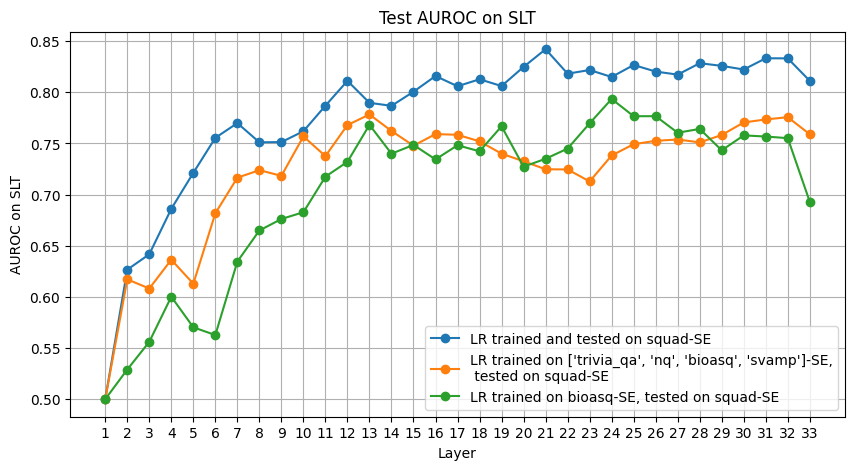

SLT: max AUROC for LR trained on squad's SE and tested on squad's SE:
	- 0.8421 at layer 21
	- 0.8332 at layer 31
	- 0.8331 at layer 32
	- 0.8284 at layer 28
	- 0.8266 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's SE:
	- 0.7783 at layer 13
	- 0.7756 at layer 32
	- 0.7734 at layer 31
	- 0.7705 at layer 30
	- 0.7680 at layer 12
SLT: max AUROC for LR trained on bioasq's SE and tested on squad's SE:
	- 0.7934 at layer 24
	- 0.7766 at layer 26
	- 0.7766 at layer 25
	- 0.7696 at layer 23
	- 0.7681 at layer 13
Testing on SVAMP's SLT-SE


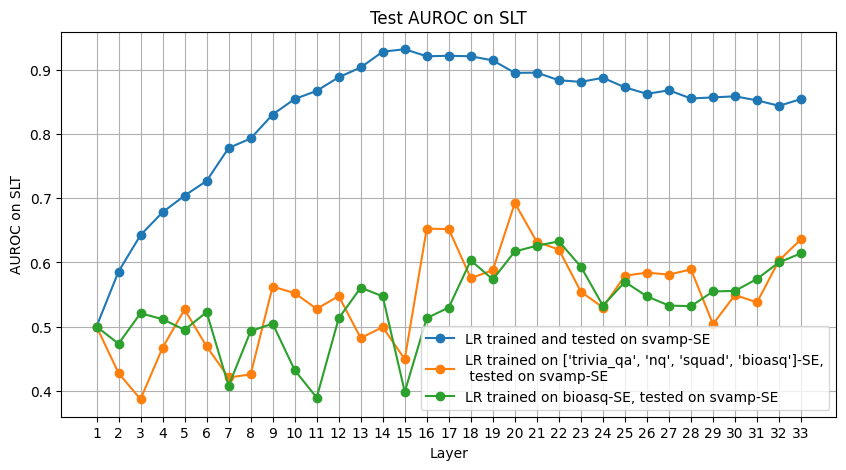

SLT: max AUROC for LR trained on svamp's SE and tested on svamp's SE:
	- 0.9325 at layer 15
	- 0.9287 at layer 14
	- 0.9223 at layer 17
	- 0.9215 at layer 16
	- 0.9215 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's SE:
	- 0.6927 at layer 20
	- 0.6528 at layer 16
	- 0.6520 at layer 17
	- 0.6362 at layer 33
	- 0.6320 at layer 21
SLT: max AUROC for LR trained on bioasq's SE and tested on svamp's SE:
	- 0.6329 at layer 22
	- 0.6261 at layer 21
	- 0.6171 at layer 20
	- 0.6142 at layer 33
	- 0.6031 at layer 18


Using probes trained on datasets BIOASQ's SLT-SE to predict ['trivia_qa', 'nq', 'squad', 'svamp']'s SLT-Acc
Testing on TRIVIA_QA's SLT-Acc


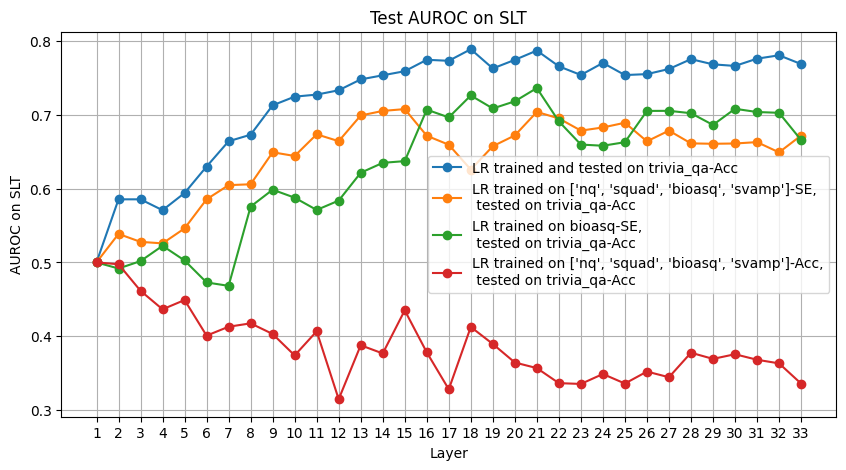

SLT: max AUROC for LR trained on trivia_qa's Acc and tested on trivia_qa's Acc:
	- 0.7886 at layer 18
	- 0.7868 at layer 21
	- 0.7804 at layer 32
	- 0.7758 at layer 31
	- 0.7751 at layer 28
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's Acc:
	- 0.7075 at layer 15
	- 0.7051 at layer 14
	- 0.7037 at layer 21
	- 0.6989 at layer 13
	- 0.6949 at layer 22
SLT: max AUROC for LR trained on bioasq's SE and tested on trivia_qa's Acc:
	- 0.7360 at layer 21
	- 0.7260 at layer 18
	- 0.7181 at layer 20
	- 0.7084 at layer 19
	- 0.7079 at layer 30
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on trivia_qa's Acc:
	- 0.5000 at layer 1
	- 0.4975 at layer 2
	- 0.4615 at layer 3
	- 0.4491 at layer 5
	- 0.4365 at layer 4
Testing on NQ's SLT-Acc


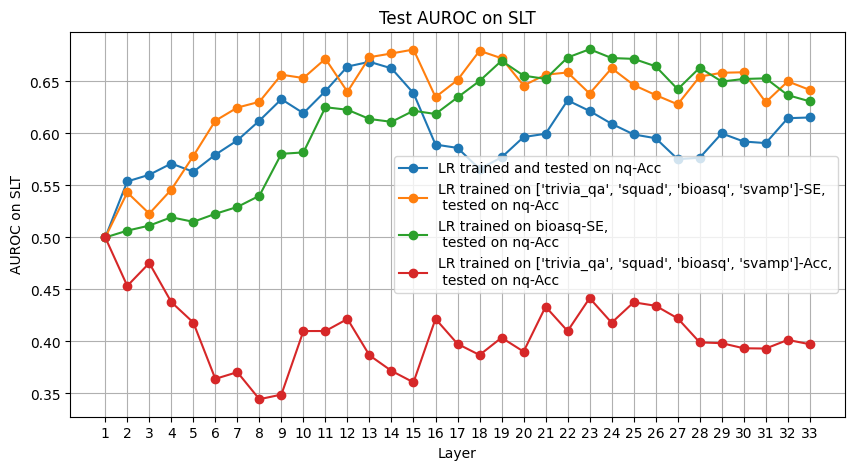

SLT: max AUROC for LR trained on nq's Acc and tested on nq's Acc:
	- 0.6689 at layer 13
	- 0.6643 at layer 12
	- 0.6626 at layer 14
	- 0.6408 at layer 11
	- 0.6387 at layer 15
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's Acc:
	- 0.6807 at layer 15
	- 0.6795 at layer 18
	- 0.6769 at layer 14
	- 0.6733 at layer 13
	- 0.6723 at layer 19
SLT: max AUROC for LR trained on bioasq's SE and tested on nq's Acc:
	- 0.6810 at layer 23
	- 0.6730 at layer 22
	- 0.6725 at layer 24
	- 0.6717 at layer 25
	- 0.6699 at layer 19
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on nq's Acc:
	- 0.5000 at layer 1
	- 0.4754 at layer 3
	- 0.4534 at layer 2
	- 0.4417 at layer 23
	- 0.4379 at layer 4
Testing on SQUAD's SLT-Acc


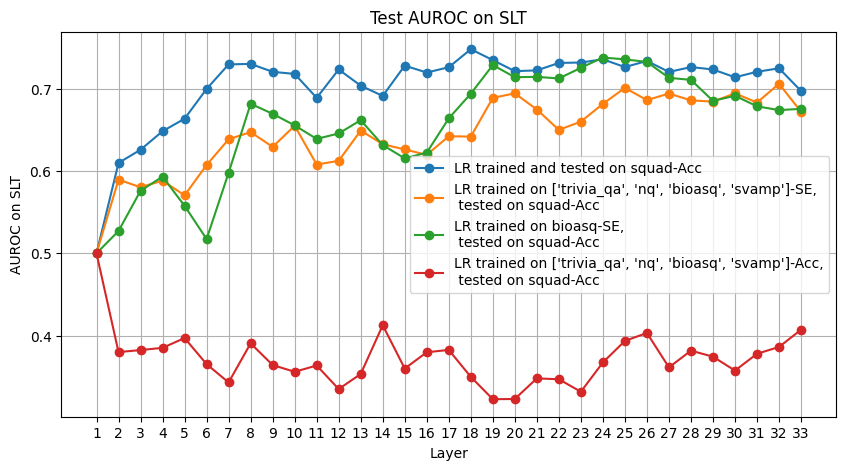

SLT: max AUROC for LR trained on squad's Acc and tested on squad's Acc:
	- 0.7479 at layer 18
	- 0.7356 at layer 24
	- 0.7347 at layer 19
	- 0.7337 at layer 26
	- 0.7318 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's Acc:
	- 0.7060 at layer 32
	- 0.7009 at layer 25
	- 0.6943 at layer 20
	- 0.6943 at layer 30
	- 0.6941 at layer 27
SLT: max AUROC for LR trained on bioasq's SE and tested on squad's Acc:
	- 0.7378 at layer 24
	- 0.7356 at layer 25
	- 0.7325 at layer 26
	- 0.7286 at layer 19
	- 0.7253 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on squad's Acc:
	- 0.5000 at layer 1
	- 0.4127 at layer 14
	- 0.4072 at layer 33
	- 0.4033 at layer 26
	- 0.3971 at layer 5
Testing on SVAMP's SLT-Acc


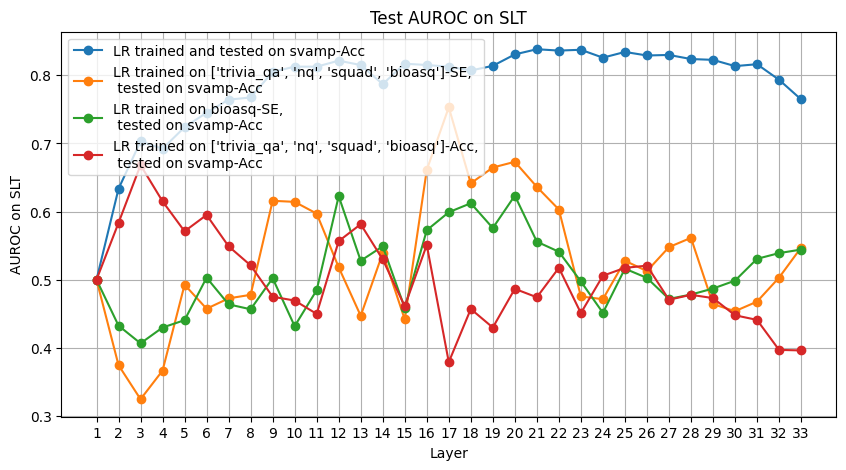

SLT: max AUROC for LR trained on svamp's Acc and tested on svamp's Acc:
	- 0.8383 at layer 21
	- 0.8375 at layer 23
	- 0.8363 at layer 22
	- 0.8343 at layer 25
	- 0.8307 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's Acc:
	- 0.7531 at layer 17
	- 0.6731 at layer 20
	- 0.6647 at layer 19
	- 0.6611 at layer 16
	- 0.6415 at layer 18
SLT: max AUROC for LR trained on bioasq's SE and tested on svamp's Acc:
	- 0.6234 at layer 20
	- 0.6226 at layer 12
	- 0.6122 at layer 18
	- 0.5990 at layer 17
	- 0.5758 at layer 19
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on svamp's Acc:
	- 0.6683 at layer 3
	- 0.6150 at layer 4
	- 0.5950 at layer 6
	- 0.5834 at layer 2
	- 0.5814 at layer 13


In [271]:
test_one_on_n(D4)

Using probes trained on datasets SVAMP's SLT-SE to predict ['trivia_qa', 'nq', 'squad', 'bioasq']'s SLT-SE
Testing on TRIVIA_QA's SLT-SE


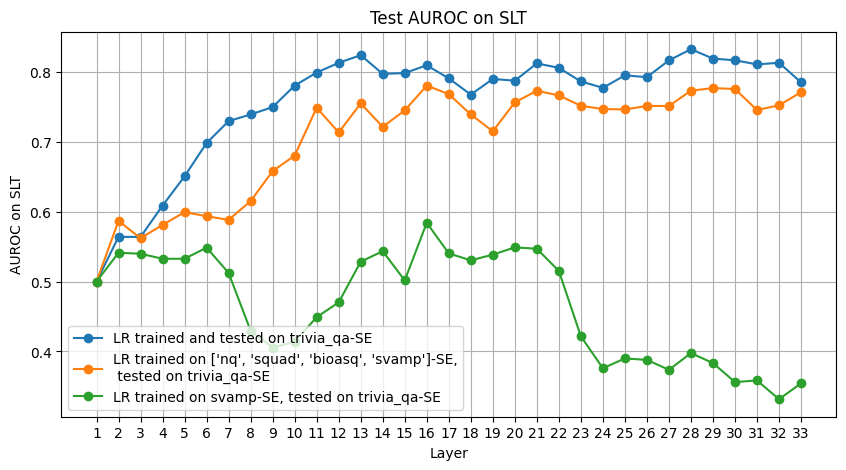

SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's SE:
	- 0.8330 at layer 28
	- 0.8245 at layer 13
	- 0.8196 at layer 29
	- 0.8172 at layer 30
	- 0.8171 at layer 27
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's SE:
	- 0.7809 at layer 16
	- 0.7773 at layer 29
	- 0.7760 at layer 30
	- 0.7736 at layer 28
	- 0.7734 at layer 21
SLT: max AUROC for LR trained on svamp's SE and tested on trivia_qa's SE:
	- 0.5844 at layer 16
	- 0.5491 at layer 20
	- 0.5488 at layer 6
	- 0.5472 at layer 21
	- 0.5436 at layer 14
Testing on NQ's SLT-SE


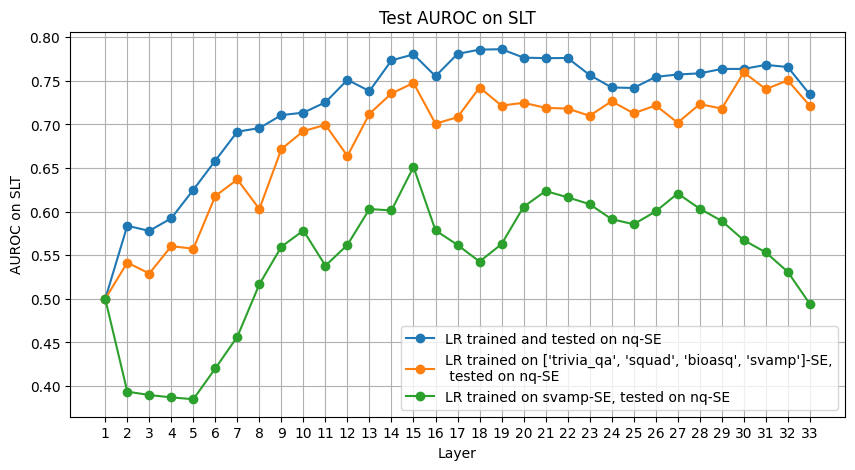

SLT: max AUROC for LR trained on nq's SE and tested on nq's SE:
	- 0.7863 at layer 19
	- 0.7859 at layer 18
	- 0.7810 at layer 17
	- 0.7804 at layer 15
	- 0.7767 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's SE:
	- 0.7598 at layer 30
	- 0.7505 at layer 32
	- 0.7476 at layer 15
	- 0.7424 at layer 18
	- 0.7406 at layer 31
SLT: max AUROC for LR trained on svamp's SE and tested on nq's SE:
	- 0.6513 at layer 15
	- 0.6237 at layer 21
	- 0.6208 at layer 27
	- 0.6165 at layer 22
	- 0.6086 at layer 23
Testing on SQUAD's SLT-SE


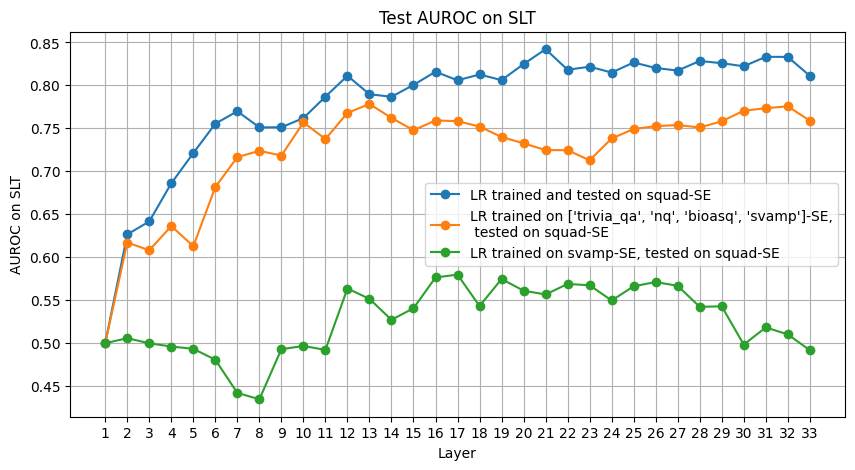

SLT: max AUROC for LR trained on squad's SE and tested on squad's SE:
	- 0.8421 at layer 21
	- 0.8332 at layer 31
	- 0.8331 at layer 32
	- 0.8284 at layer 28
	- 0.8266 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's SE:
	- 0.7783 at layer 13
	- 0.7756 at layer 32
	- 0.7734 at layer 31
	- 0.7705 at layer 30
	- 0.7680 at layer 12
SLT: max AUROC for LR trained on svamp's SE and tested on squad's SE:
	- 0.5798 at layer 17
	- 0.5765 at layer 16
	- 0.5747 at layer 19
	- 0.5712 at layer 26
	- 0.5690 at layer 22
Testing on BIOASQ's SLT-SE


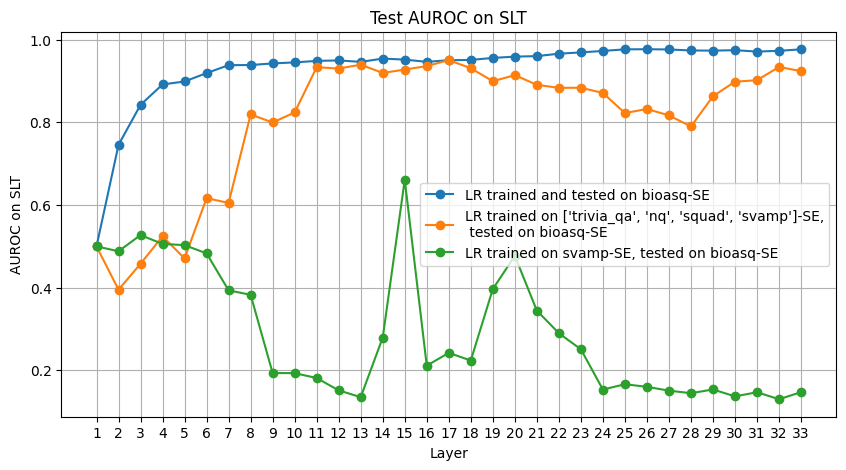

SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's SE:
	- 0.9769 at layer 26
	- 0.9766 at layer 25
	- 0.9766 at layer 33
	- 0.9763 at layer 27
	- 0.9746 at layer 30
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's SE:
	- 0.9505 at layer 17
	- 0.9395 at layer 13
	- 0.9361 at layer 16
	- 0.9340 at layer 32
	- 0.9334 at layer 11
SLT: max AUROC for LR trained on svamp's SE and tested on bioasq's SE:
	- 0.6611 at layer 15
	- 0.5273 at layer 3
	- 0.5059 at layer 4
	- 0.5030 at layer 5
	- 0.5000 at layer 1


Using probes trained on datasets SVAMP's SLT-SE to predict ['trivia_qa', 'nq', 'squad', 'bioasq']'s SLT-Acc
Testing on TRIVIA_QA's SLT-Acc


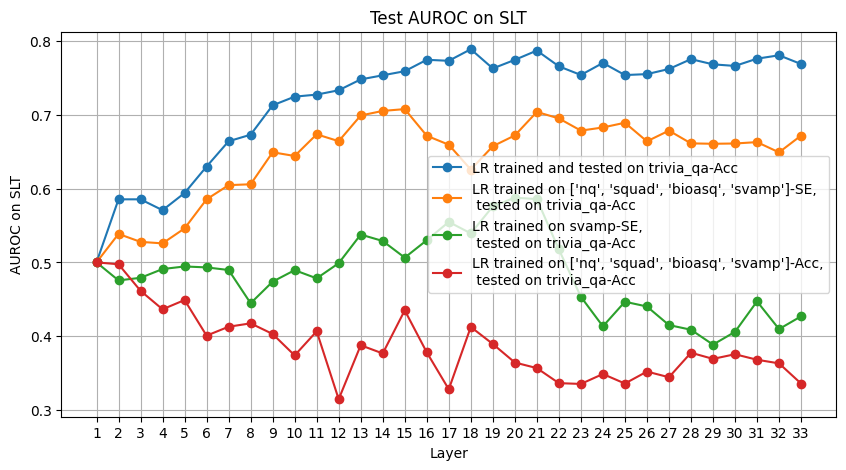

SLT: max AUROC for LR trained on trivia_qa's Acc and tested on trivia_qa's Acc:
	- 0.7886 at layer 18
	- 0.7868 at layer 21
	- 0.7804 at layer 32
	- 0.7758 at layer 31
	- 0.7751 at layer 28
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's Acc:
	- 0.7075 at layer 15
	- 0.7051 at layer 14
	- 0.7037 at layer 21
	- 0.6989 at layer 13
	- 0.6949 at layer 22
SLT: max AUROC for LR trained on svamp's SE and tested on trivia_qa's Acc:
	- 0.5876 at layer 20
	- 0.5857 at layer 21
	- 0.5758 at layer 19
	- 0.5548 at layer 17
	- 0.5393 at layer 18
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on trivia_qa's Acc:
	- 0.5000 at layer 1
	- 0.4975 at layer 2
	- 0.4615 at layer 3
	- 0.4491 at layer 5
	- 0.4365 at layer 4
Testing on NQ's SLT-Acc


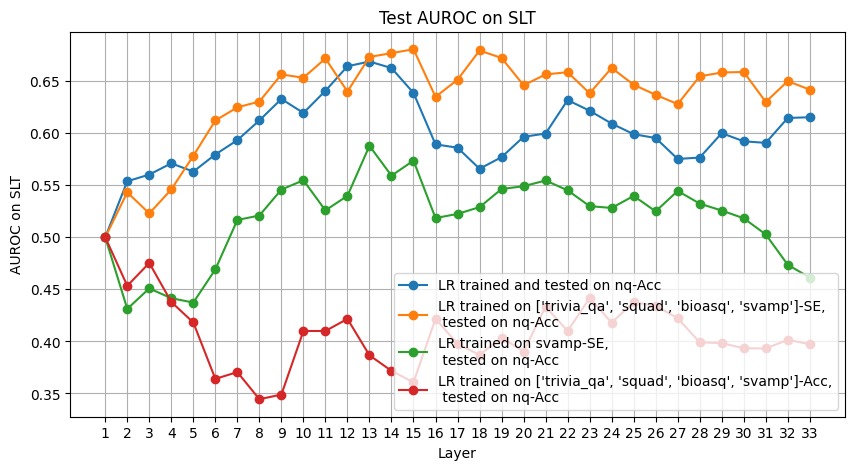

SLT: max AUROC for LR trained on nq's Acc and tested on nq's Acc:
	- 0.6689 at layer 13
	- 0.6643 at layer 12
	- 0.6626 at layer 14
	- 0.6408 at layer 11
	- 0.6387 at layer 15
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's Acc:
	- 0.6807 at layer 15
	- 0.6795 at layer 18
	- 0.6769 at layer 14
	- 0.6733 at layer 13
	- 0.6723 at layer 19
SLT: max AUROC for LR trained on svamp's SE and tested on nq's Acc:
	- 0.5879 at layer 13
	- 0.5737 at layer 15
	- 0.5592 at layer 14
	- 0.5548 at layer 10
	- 0.5546 at layer 21
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on nq's Acc:
	- 0.5000 at layer 1
	- 0.4754 at layer 3
	- 0.4534 at layer 2
	- 0.4417 at layer 23
	- 0.4379 at layer 4
Testing on SQUAD's SLT-Acc


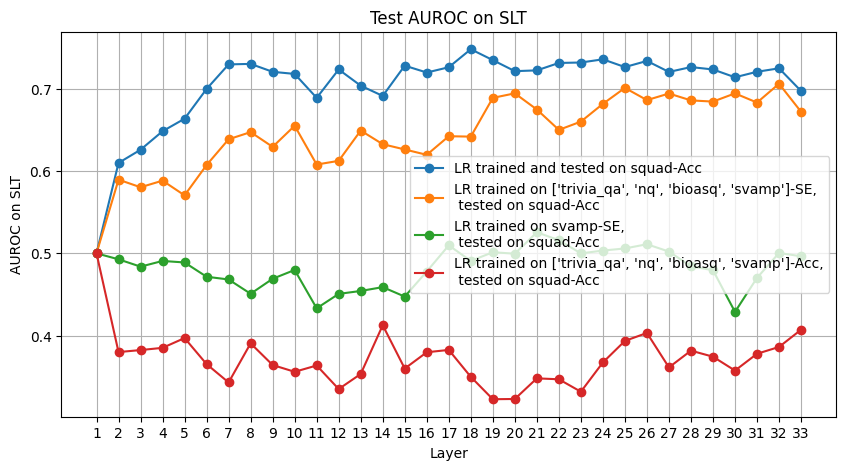

SLT: max AUROC for LR trained on squad's Acc and tested on squad's Acc:
	- 0.7479 at layer 18
	- 0.7356 at layer 24
	- 0.7347 at layer 19
	- 0.7337 at layer 26
	- 0.7318 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's Acc:
	- 0.7060 at layer 32
	- 0.7009 at layer 25
	- 0.6943 at layer 20
	- 0.6943 at layer 30
	- 0.6941 at layer 27
SLT: max AUROC for LR trained on svamp's SE and tested on squad's Acc:
	- 0.5256 at layer 21
	- 0.5160 at layer 22
	- 0.5110 at layer 26
	- 0.5097 at layer 17
	- 0.5059 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on squad's Acc:
	- 0.5000 at layer 1
	- 0.4127 at layer 14
	- 0.4072 at layer 33
	- 0.4033 at layer 26
	- 0.3971 at layer 5
Testing on BIOASQ's SLT-Acc


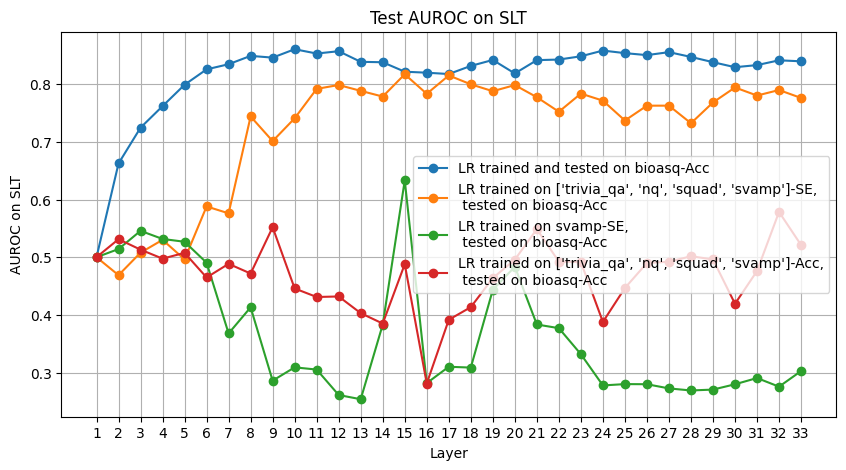

SLT: max AUROC for LR trained on bioasq's Acc and tested on bioasq's Acc:
	- 0.8606 at layer 10
	- 0.8583 at layer 24
	- 0.8572 at layer 12
	- 0.8556 at layer 27
	- 0.8538 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's Acc:
	- 0.8172 at layer 15
	- 0.8152 at layer 17
	- 0.7998 at layer 18
	- 0.7986 at layer 12
	- 0.7985 at layer 20
SLT: max AUROC for LR trained on svamp's SE and tested on bioasq's Acc:
	- 0.6332 at layer 15
	- 0.5457 at layer 3
	- 0.5316 at layer 4
	- 0.5268 at layer 5
	- 0.5141 at layer 2
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on bioasq's Acc:
	- 0.5785 at layer 32
	- 0.5520 at layer 9
	- 0.5486 at layer 21
	- 0.5312 at layer 2
	- 0.5212 at layer 33


In [272]:
test_one_on_n(D5)

SVAMP dataset is really weak in generalization.

## Save dataset metrics

In [279]:
# save dataset fields to pickle
import pickle
from datetime import datetime

Ds_save = ()
excl_attrs = ['tbg_dataset', 'slt_dataset', 'entropy', 'ca_entropy', 'accuracies', 'b_entropy'] 

for D in Ds:
    D_save = {key: value for key, value in vars(D).items() if key not in excl_attrs}
    Ds_save += (D_save,)

path = "~/Downloads/oatml/semantic_uncertainty/latent_probe_notebooks/metrics"
full_path = os.path.expanduser(path)
os.makedirs(full_path, exist_ok=True)
time_now = datetime.now().strftime("%Y%m%d-%H%M%S")

f = open(f'{full_path}/{time_now}_{"_".join([D.name + "-" + str(D.total_size) for D in Ds])}.pkl', 'wb')
pickle.dump(Ds_save, f)
f.close()